# RIM Valuation v12 — Validity Patch (통화 가드 · TV 보수화 · Sanity Guard · 전량 재계산)

**v12 변경점** (Cell 4.6 참조)
1. **TV 보수화**: `g = max(Re−0.75%, GDP)` (RI 영구멀티플 147배) 폐지 → 기본 'ohlson' 모드 TV = RI·ω/(1+Re−ω) (Phase 2 ω 감쇠의 영구 연장, moat 차등), 선택 'gordon' g ≤ min(GDP, Rf, Re−2%), TV ≤ 35×RI
2. **통화 가드**: 재무제표 `reportedCurrency ≠ USD` ADR(MBT·TLK·EC·PKX·KT 등) 평가 제외
3. **Sanity Guard**: 산출 내재가치가 실제 시총 ±30배 초과 시 제외
4. **매 실행 전체 재계산**: 체크포인트를 측정일별 파일로 분리(새 날짜=전체 재계산, 같은 날=크래시 복구 SKIP), `RUN_DATE_OVERRIDE` 로 측정일 고정 가능, 동일 측정일 upsert 전 컬럼 갱신

---

# RIM (Residual Income Model) Valuation
## Sales-driven DuPont ROE → Ohlson (1995) Residual Income Valuation

### Model Flow
```
①  DB (us_revenue_forecast_data)  →  Actual + 8Q Forecast Sales
②  FMP API  →  IS / BS quarterly data
③  DuPont decomposition (Sales-driven)
      NPM   = Net Income / Sales     [OLS or median]
      AT    = Sales / Total Assets   [OLS or median]
      FL    = Total Assets / Equity  [OLS or median]
      ROE   = NPM × AT × FL          [Phase 1: 2yr forecast]
④  Re  from DB (us_rim_spread_data.Re_smooth)
⑤  RI spread decay  →  AR(1) Ohlson omega  (EVA/moat-based)
      Phase 2 (5~15yr): RI(t) = omega × RI(t-1)
      Phase 3: TV = RI_last / (Re - g)
⑥  Intrinsic Value = Book Value + PV(RI Phase1) + PV(RI Phase2) + PV(TV)
```

### Academic References
- **Ohlson (1995)** *JAR* — Residual Income / Linear Information Model
- **Feltham & Ohlson (1995)** *JAR* — ω (persistence) coefficient
- **Fama & French (1995)** *JF* — Mean reversion of profitability (AR(1))
- **Mauboussin & Johnson (1997)** *FAJ* — Competitive Advantage Period
- **Damodaran (2002)** — 3-Stage structure & phase period guidance


## Cell 1 · Path Setup

## v8 calibration patch

This notebook relaxes the most conservative assumptions in the original v7 RIM model to make valuation outputs more realistic for durable U.S. compounders.

Main changes:
- dividend-only retention for BV compounding
- mild quality-based Re haircut (max 150bp)
- less conservative Phase 1 ROE anchoring
- higher persistence for weaker moat buckets
- terminal RI uses next-period Gordon form
- BV retention cap raised from 50% to 75%


In [2]:
import sys, os, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

_CANDIDATE_ROOTS = [
    r"C:\Users\Hoyoung_Park\PyCharmMiscProject\stock_forecast",
    r"C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy",
]

def _setup_path() -> str:
    try:
        start = Path(__file__).resolve().parent
    except NameError:
        start = Path.cwd()
    for p in [start] + list(start.parents):
        if (p / "DATA").is_dir():
            root = str(p)
            if root not in sys.path:
                sys.path.insert(0, root)
            print(f"[PATH] root auto-detected : {root}")
            return root
    for candidate in _CANDIDATE_ROOTS:
        if os.path.isdir(candidate) and os.path.isdir(os.path.join(candidate, "DATA")):
            if candidate not in sys.path:
                sys.path.insert(0, candidate)
            print(f"[PATH] root fallback : {candidate}")
            return candidate
    raise EnvironmentError("DATA folder not found. Update _CANDIDATE_ROOTS.")

_ROOT = _setup_path()
print(f"[OK] Project root : {_ROOT}")


[PATH] root auto-detected : C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy
[OK] Project root : C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy


## Cell 2 · Imports & Constants

> **Edit here only**: `TICKER_START / TICKER_END / SKIP_DONE`


In [3]:
import gc, math, time, traceback, warnings
import requests
from datetime import datetime
from typing import Optional, Dict, Any, List, Tuple

import numpy as np
import pandas as pd
import pymysql
from scipy import stats
from IPython.display import display
import matplotlib
matplotlib.rcParams["axes.unicode_minus"] = False
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sqlalchemy import text

from DATA.config import get_db_info, get_engine
from DATA.us_target_ticker_list_2000 import ticker_list as US_TICKER_LIST

def log(tag: str, msg: str):
    ts = datetime.now().strftime("%H:%M:%S")
    print(f"[{ts}][{tag}] {msg}", flush=True)

# ── FMP ───────────────────────────────────────────────────────────────────────
FMP_API_KEY = "hT0gAk87j9xZx4PlBApvBqfVL5IahvgV"
FMP_BASE    = "https://financialmodelingprep.com/api/v3"
FMP_LIMIT   = 40
FMP_SLEEP   = 0.35

# ── DB Tables ─────────────────────────────────────────────────────────────────
TABLE_SALES   = "us_revenue_forecast_data"   # sales forecast
TABLE_RE      = "us_rim_spread_data"          # Re_smooth (already computed)
TABLE_RESULT  = "us_rim_valuation"            # RIM output
DEFAULT_PORT  = 3307

# ── Model Parameters ──────────────────────────────────────────────────────────
FORECAST_HORIZON = 8       # quarters for Sales forecast (사용은 load_sales에서)

# ── Phase 1 기간: moat 등급별 plateau 효과 ────────────────────────────────
# Mauboussin & Johnson (1997) CAP 이론: 경쟁우위 기업은 초과수익을 오래 유지
# Phase 1 = ROE 유지 기간 (DuPont 기반), Phase 2 = AR(1) 감쇠 시작
# Phase 1 = Sales forecast 2yr (항상 고정) + 등급별 GDP 연장
# 실제 Sales 예측치 2년을 베이스로 쓰고, 그 위에 추가 연장만 붙임
PHASE1_BASE_YR  = 2   # Sales forecast 고정 기간 (8Q)
PHASE1_EXTRA_YR = {
    "Exceptional moat":  5,   # 2+5 = 7yr
    "Wide moat":         4,   # 2+4 = 6yr
    "Wide-Narrow moat":  3,   # 2+3 = 5yr
    "Narrow moat":       2,   # 2+2 = 4yr
    "Some moat":         1,   # 2+1 = 3yr
    "No moat":           0,   # 2+0 = 2yr (기존과 동일)
    "Unknown (fallback)":1,
}
# 최종 Phase 1 기간 = PHASE1_BASE_YR + PHASE1_EXTRA_YR[moat]
PHASE1_YR_BY_MOAT = {g: PHASE1_BASE_YR + e for g, e in PHASE1_EXTRA_YR.items()}
MIN_HISTORY      = 12      # minimum quarters for DuPont OLS
OLS_MIN_R2       = 0.20    # relaxed vs FCFF (ratio regression is noisier)
OLS_MIN_SAMPLES  = 12
WINSORIZE_LIMITS = (0.05, 0.95)
GDP_GROWTH       = 0.04    # terminal growth cap
TV_RE_GAP        = 0.0075  # [v12 폐기] Cell 4.6 Validity Patch 가 TV 를 ohlson/gordon 방식으로 대체 (참조용으로만 유지)
RETENTION_FLOOR  = -0.50   # 음수 허용 (buyback > NI)
BV_RETENTION_CAP = 0.75    # BV growth cap relaxed for quality compounders

# ── Batch Range ───────────────────────────────────────────────────────────────
TICKER_START = 0
TICKER_END   = len(US_TICKER_LIST)          # <- adjust

# ★v12: 측정일 고정 옵션 — 배치가 2일 이상 걸릴 때 같은 측정일로 이어가려면
#       예: RUN_DATE_OVERRIDE = "2026-06-08"  (None → 실행 시작일 자동)
RUN_DATE_OVERRIDE = None
RUN_DATE = RUN_DATE_OVERRIDE or datetime.now().strftime("%Y-%m-%d")

# ★v12: SKIP_DONE 은 '같은 측정일(RUN_DATE) 안에서의 크래시 복구' 전용.
#       체크포인트가 측정일별 파일로 분리되어, 새 날짜에 실행하면
#       전 종목이 자동으로 다시 계산·저장됩니다.
SKIP_DONE    = True

CHECKPOINT_DIR = "_rim_checkpoint"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
DONE_PATH = os.path.join(CHECKPOINT_DIR, f"done_tickers_{RUN_DATE}.txt")
FAIL_PATH = os.path.join(CHECKPOINT_DIR, f"failed_tickers_{RUN_DATE}.txt")
print(f"[v12] RUN_DATE={RUN_DATE}  checkpoint={DONE_PATH}")
print( "[v12] 새 측정일 실행 → 전 종목 재계산 / 같은 날 재실행 → 완료분 SKIP(크래시 복구)")

db_info = get_db_info()
engine  = get_engine(db_info)

print(f"[OK] Imports complete  |  tickers: {len(US_TICKER_LIST):,}")
print(f"[Config] FORECAST_HORIZON={FORECAST_HORIZON}Q  GDP_GROWTH={GDP_GROWTH}")

QUALITY_RE_HAIRCUT_MAX = 0.000  # v9: disabled; no artificial quality haircut to Re
PHASE1_ROE_FLOOR_RATIO = 0.80   # floor vs historical ROE
PHASE1_ROE_CEILING_RATIO = 2.50 # ceiling vs historical ROE


[v12] RUN_DATE=2026-06-13  checkpoint=_rim_checkpoint\done_tickers_2026-06-13.txt
[v12] 새 측정일 실행 → 전 종목 재계산 / 같은 날 재실행 → 완료분 SKIP(크래시 복구)
[OK] Imports complete  |  tickers: 2,000
[Config] FORECAST_HORIZON=8Q  GDP_GROWTH=0.04


## Cell 3 · DB Connection & Table Init

In [4]:
def get_conn():
    return pymysql.connect(
        host       = db_info["host"],
        port       = int(db_info.get("port", DEFAULT_PORT)),
        user       = db_info["user"],
        password   = db_info["password"],
        db         = db_info.get("database", "investar"),
        charset    = "utf8mb4",
        autocommit = False,
        cursorclass= pymysql.cursors.DictCursor,
    )

CREATE_SQL = """
CREATE TABLE IF NOT EXISTS `us_rim_valuation` (
  `id`              BIGINT      NOT NULL AUTO_INCREMENT,
  `date`            DATE        NOT NULL COMMENT 'run date',
  `ticker`          VARCHAR(20) NOT NULL,
  `year_label`      VARCHAR(10)          COMMENT 'e.g. 2026 or Ph2-Y3',
  `phase`           VARCHAR(10)          COMMENT 'ph1 / ph2 / tv',
  `sales_forecast`  DOUBLE               COMMENT 'annual sales forecast',
  `npm_forecast`    DOUBLE               COMMENT 'net profit margin',
  `asset_turnover`  DOUBLE,
  `fin_leverage`    DOUBLE,
  `roe_forecast`    DOUBLE,
  `re`              DOUBLE               COMMENT 'cost of equity',
  `ri_spread`       DOUBLE               COMMENT 'ROE - Re',
  `bv_start`        DOUBLE               COMMENT 'book value (start of year)',
  `ri`              DOUBLE               COMMENT 'residual income',
  `pv_ri`           DOUBLE               COMMENT 'PV of RI',
  `moat_label`      VARCHAR(30),
  `rho`             DOUBLE               COMMENT 'AR(1) persistence coef',
  `n_phase2`        INT,
  `g_terminal`      DOUBLE,
  `pv_all_ri`       DOUBLE,
  `terminal_value`  DOUBLE,
  `intrinsic_value` DOUBLE,
  `current_price`   DOUBLE,
  `upside_pct`      DOUBLE,
  `target_price`    DOUBLE,
  `created_at`      DATETIME    DEFAULT CURRENT_TIMESTAMP,
  PRIMARY KEY (`id`),
  UNIQUE KEY uq_main (`ticker`, `date`, `year_label`),
  INDEX idx_ticker (`ticker`),
  INDEX idx_date   (`date`)
) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4;
"""

conn = get_conn()
try:
    with conn.cursor() as cur:
        cur.execute(CREATE_SQL)
    conn.commit()
    log("DB", f"Table ready: {TABLE_RESULT}")
finally:
    conn.close()

try:
    with engine.connect() as c:
        c.execute(text("SELECT 1"))
    log("DB", f"Connected  host={db_info.get('host')}  port={db_info.get('port')}")
except Exception as e:
    log("DB", f"Connection failed: {e}")


[20:16:25][DB] Table ready: us_rim_valuation
[20:16:25][DB] Connected  host=192.168.0.230  port=3307


## Cell 4 · RIMModel Class

### Structure
| Method | Role |
|--------|------|
| `load_sales()` | DB → actual + forecast Sales |
| `load_financials()` | FMP → IS / BS quarterly |
| `load_re()` | DB → Re_smooth (cost of equity) |
| `estimate_retention()` | earnings retention ratio |
| `estimate_dupont_coefs()` | NPM / AT / FL via OLS or median |
| `forecast_roe_phase1()` | DuPont ROE for Phase 1 (2yr) |
| `compute_eva_spread()` | ROIC - WACC for moat classification |
| `moat_to_omega_and_years()` | EVA → (ω, Phase2 years, label) |
| `compute_ri_path()` | full RI time-series (Ph1 + Ph2) |
| `compute_valuation()` | BV + PV(RI) + PV(TV) |
| `save_to_db()` | upsert to us_rim_valuation |
| `plot()` | historical + forecast RI / ROE visualisation |


[OK] RIMModel class defined

[Test] TMUS ...
[20:16:31][TMUS] Sales loaded  actual=45Q  forecast=8Q
[20:16:34][TMUS] IS=39Q / BS=39Q / CF=39Q
[20:16:36][TMUS] Re_final=0.0904  [0.8*fmp(0.0890) + 0.2*db(0.0958)]
[20:16:36][TMUS] Re_detail  Rf=0.045  ERP=0.055  beta_raw=0.301  beta_adj=0.800  size=0.000  country=0.000  ey=0.060
[20:16:36][TMUS] DuPont coefs  NPM=0.1086(ols)  AT=0.390(TTM/Assets median)  FL=3.15(median)
[20:16:37][TMUS] EVA: ROIC=8.56%  WACC=5.96%  spread=+2.60%  n_pos=11/20  ROE-Re=+8.78%
[20:16:37][TMUS] Retention=-0.231  payout=1.231  [CF(div+buyback)]
[20:16:37][TMUS] Retention=-0.231  payout=1.231  [CF(div+buyback)]
[20:16:37][TMUS] RI path: Ph1=3yr Ph2=15yr  RI_last=1208.4M  [Some moat ω=0.94 PVfactor=5.58]
[20:16:38][TMUS] RIM  BV=55.88B  PV(RI)=21.18B  PV(TV)=36.77B  IV=113.82B  TP=$103.28  Upside=-45.4%
  status=ok  TP=103.28  Moat=Some moat  omega=0.94
[20:16:38][TMUS] Sales loaded  actual=45Q  forecast=8Q
[20:16:41][TMUS] IS=39Q / BS=39Q / CF=39Q
[20:16:43][TMU

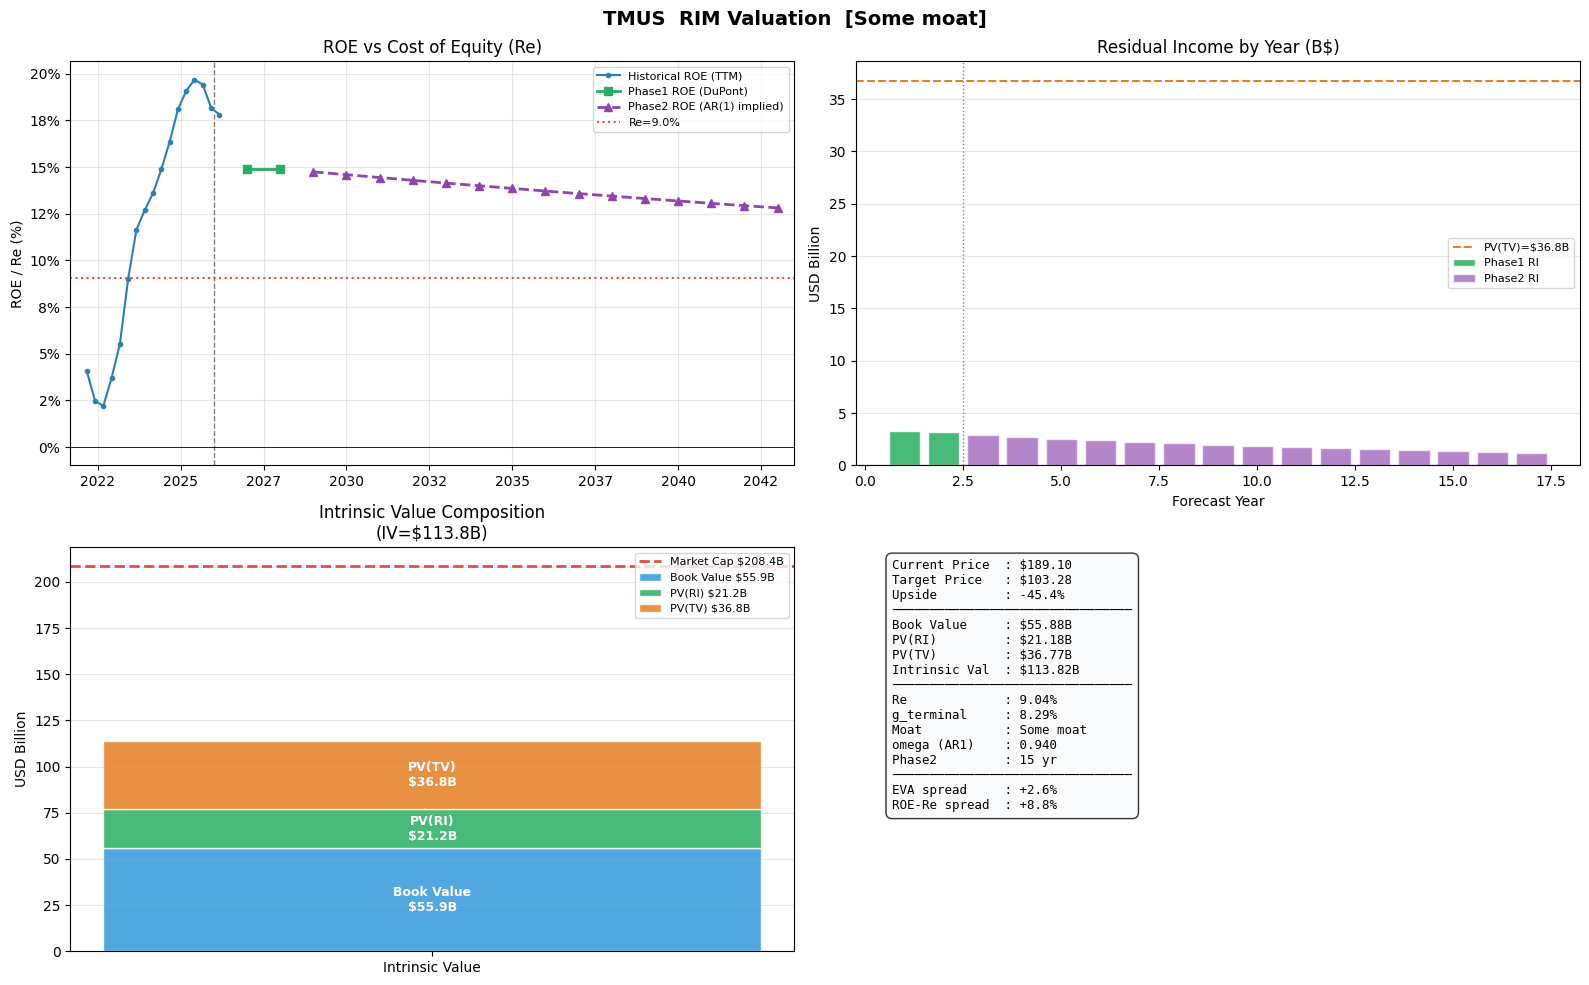

In [5]:
# ═══════════════════════════════════════════════════════════════
#  RIMModel — Ohlson (1995) Residual Income Valuation
#  Sales-driven DuPont ROE  +  AR(1) RI spread decay
# ═══════════════════════════════════════════════════════════════

class RIMModel:
    """
    Residual Income Model (Ohlson 1995) with Sales-driven DuPont forecasting.

    Valuation:
        P = BV_0 + sum( RI_t / (1+Re)^t ) + PV(TV)
        RI_t = (ROE_t - Re) * BV_{t-1}
        BV_t = BV_{t-1} * (1 + ROE_t * retention_t)

    Phase 1 (2yr): Sales forecast → DuPont → ROE
    Phase 2 (5~15yr): AR(1) RI decay  RI(t) = omega * RI(t-1)
                      omega determined by EVA moat (Ohlson 1995, Fama-French 1995)
    Phase 3: TV = RI_last / (Re - g)  [if RI_last > 0]

    References:
        Ohlson (1995) JAR, Feltham & Ohlson (1995) JAR,
        Fama & French (1995) JF, Mauboussin & Johnson (1997) FAJ,
        Damodaran (2002) Investment Valuation
    """

    def __init__(
        self,
        ticker: str,
        engine,
        fmp_api_key: str = FMP_API_KEY,
        forecast_horizon: int = FORECAST_HORIZON,
        min_history: int = MIN_HISTORY,
        gdp_growth: float = GDP_GROWTH,
        verbose: bool = False,
    ):
        self.ticker          = ticker.upper()
        self.engine          = engine
        self.api_key         = fmp_api_key
        self.horizon         = forecast_horizon
        self.min_history     = min_history
        self.gdp_growth      = gdp_growth
        self.verbose         = verbose

        self._sales_actual:   Optional[pd.Series] = None
        self._sales_forecast: Optional[pd.Series] = None
        self._inc:            Optional[pd.DataFrame] = None
        self._bs:             Optional[pd.DataFrame] = None
        self._re:             Optional[float] = None
        self._eva_cache:      Optional[dict] = None
        self._cf:             Optional[pd.DataFrame] = None  # [FIX] cashflow
        self._using_ic:       bool = False                   # 음수 BV → IC 대체 여부
        self._n_phase1:       int  = 2                       # 실제 사용된 Phase1 기간
        self.result_df:       Optional[pd.DataFrame] = None
        self.valuation:       Optional[Dict] = None

    # ─────────────────────────────────────────────────────────
    # 1. Data Loading
    # ─────────────────────────────────────────────────────────

    def load_sales(self) -> "RIMModel":
        """
        Load Sales from DB (us_revenue_forecast_data).
        Identical pattern to DCFModel.load_sales() — cursor.execute/fetchall only.
        """
        conn_local = get_conn()
        try:
            with conn_local.cursor() as cur:
                cur.execute(
                    f"SELECT date, data_type, model, value "
                    f"FROM `{TABLE_SALES}` "
                    f"WHERE ticker=%s AND item='sale' AND data_type='actual' "
                    f"ORDER BY date",
                    (self.ticker,)
                )
                actual_rows = cur.fetchall()

            with conn_local.cursor() as cur:
                cur.execute(
                    f"SELECT MAX(forecast_date) AS max_fd "
                    f"FROM `{TABLE_SALES}` "
                    f"WHERE ticker=%s AND item='sale' AND data_type='forecast'",
                    (self.ticker,)
                )
                row = cur.fetchone()
                max_fd = row["max_fd"] if row else None

            fc_rows = []
            if max_fd:
                with conn_local.cursor() as cur:
                    cur.execute(
                        f"SELECT date, data_type, model, value "
                        f"FROM `{TABLE_SALES}` "
                        f"WHERE ticker=%s AND item='sale' "
                        f"  AND data_type='forecast' AND forecast_date=%s "
                        f"ORDER BY model, date",
                        (self.ticker, max_fd)
                    )
                    fc_rows = cur.fetchall()
        finally:
            conn_local.close()

        if not actual_rows:
            raise ValueError(f"[{self.ticker}] No actual Sales — run revenue forecast notebook first")

        act_df = pd.DataFrame(actual_rows)
        act_df["date"]  = pd.to_datetime(act_df["date"])
        act_df["value"] = pd.to_numeric(act_df["value"], errors="coerce")
        actual = (act_df.sort_values("date")
                        .drop_duplicates("date", keep="last")
                        .set_index("date")["value"])

        if not fc_rows:
            raise ValueError(f"[{self.ticker}] No forecast Sales (forecast_date={max_fd})")

        fc_df = pd.DataFrame(fc_rows)
        fc_df["date"]  = pd.to_datetime(fc_df["date"])
        fc_df["value"] = pd.to_numeric(fc_df["value"], errors="coerce")

        priority  = ["Ensemble", "SARIMA", "ETS", "Theta"]
        available = fc_df["model"].unique().tolist()
        ordered   = [m for m in priority if m in available] +                     [m for m in available if m not in priority]

        forecast = pd.Series(dtype=float)
        for model_name in ordered:
            fc = (fc_df[fc_df["model"] == model_name]
                  .sort_values("date")
                  .drop_duplicates("date", keep="last")
                  .set_index("date")["value"].dropna())
            if len(fc) >= self.horizon:
                forecast = fc.iloc[:self.horizon]
                break
            elif len(fc) > 0 and forecast.empty:
                forecast = fc

        if forecast.empty:
            raise ValueError(f"[{self.ticker}] Forecast Sales empty")

        if len(forecast) < self.horizon:
            extra_idx = pd.date_range(
                start=forecast.index[-1] + pd.offsets.QuarterEnd(1),
                periods=self.horizon - len(forecast), freq="QE"
            )
            forecast = pd.concat([
                forecast,
                pd.Series([float(forecast.iloc[-1])] * len(extra_idx), index=extra_idx)
            ])

        self._sales_actual   = actual
        self._sales_forecast = forecast.iloc[:self.horizon]
        if self.verbose:
            log(self.ticker, f"Sales loaded  actual={len(actual)}Q  forecast={len(self._sales_forecast)}Q")
        return self

    def _fmp_get(self, endpoint: str, period: str = "quarter", limit: int = FMP_LIMIT) -> pd.DataFrame:
        url = f"{FMP_BASE}/{endpoint}/{self.ticker}"
        for attempt in range(3):
            try:
                r = requests.get(url, params={"period": period, "limit": limit,
                                              "apikey": self.api_key}, timeout=20)
                if r.status_code == 429:
                    time.sleep(1.5 + attempt); continue
                r.raise_for_status()
                data = r.json()
                if isinstance(data, dict) and "Error Message" in data:
                    return pd.DataFrame()
                return pd.DataFrame(data) if isinstance(data, list) else pd.DataFrame()
            except Exception as e:
                if attempt == 2:
                    if self.verbose: log(self.ticker, f"FMP {endpoint} failed: {e}")
                    return pd.DataFrame()
                time.sleep(FMP_SLEEP + attempt * 0.5)
        return pd.DataFrame()

    def _parse_date_col(self, df: pd.DataFrame) -> pd.DataFrame:
        """acceptedDate → look-ahead-bias-free quarter-end date (same as DCFModel)"""
        df = df.copy()
        df["report_date"] = pd.to_datetime(
            df.get("acceptedDate", df.get("fillingDate", pd.NaT)), errors="coerce"
        )
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
        def _qend(row):
            if pd.notna(row.get("report_date")):
                return (row["report_date"] - pd.Timedelta(days=45)).to_period("Q").to_timestamp("Q")
            return row["date"].to_period("Q").to_timestamp("Q")
        df["date"] = df.apply(_qend, axis=1)
        return df.sort_values("date").drop_duplicates("date", keep="last").reset_index(drop=True)

    def load_financials(self) -> "RIMModel":
        """FMP API → IS + BS + CF (quarterly)"""
        time.sleep(FMP_SLEEP)
        inc = self._fmp_get("income-statement")
        time.sleep(FMP_SLEEP)
        bs  = self._fmp_get("balance-sheet-statement")
        time.sleep(FMP_SLEEP)
        cf  = self._fmp_get("cash-flow-statement")  # [FIX] 배당 데이터용
        if inc.empty or bs.empty:
            raise ValueError(f"[{self.ticker}] FMP IS/BS load failed")
        self._inc = self._parse_date_col(inc)
        self._bs  = self._parse_date_col(bs)
        self._cf  = self._parse_date_col(cf) if not cf.empty else None  # [FIX]
        if self.verbose:
            cf_q = len(self._cf) if self._cf is not None else 0
            log(self.ticker, f"IS={len(self._inc)}Q / BS={len(self._bs)}Q / CF={cf_q}Q")
        return self


    def load_re(self) -> "RIMModel":
        """
        FMP 기반 Re 추정(v9).

        핵심 원칙
        1) FMP profile/beta 데이터로 bottom-up CAPM 계산
        2) market cap 기반 size premium 추가
        3) non-US 기업에 country premium 추가
        4) earnings yield는 '하향'이 아니라 '상향 cross-check'로만 사용
        5) DB Re_smooth는 보조 참고치로만 사용하며, 최종 Re를 인위적으로 낮추지 않음

        최종적으로:
            Re_final = structural FMP Re
                       (+ 소폭의 DB blend, 단 DB가 합리적이고 큰 괴리가 없을 때만)
        """
        re_fmp = self.estimate_re_rim()

        re_db = None
        try:
            sql = text(f"""
                SELECT value FROM `{TABLE_RE}`
                WHERE ticker=:t AND indicator='Re_smooth'
                ORDER BY date DESC LIMIT 1
            """)
            with self.engine.connect() as conn:
                row = conn.execute(sql, {"t": self.ticker}).fetchone()
            if row:
                re_db = float(row[0])
        except Exception:
            re_db = None

        # DB 값은 참고용 보조치로만 사용
        # - 범위가 합리적이고
        # - FMP 구조적 Re와 지나치게 다르지 않을 때만 20% 반영
        if re_db is not None and 0.075 <= re_db <= 0.18 and abs(re_db - re_fmp) <= 0.04:
            re_final = 0.80 * re_fmp + 0.20 * re_db
            re_source = f"0.8*fmp({re_fmp:.4f}) + 0.2*db({re_db:.4f})"
        else:
            re_final = re_fmp
            db_note = f"db={re_db:.4f} ignored" if re_db is not None else "db unavailable"
            re_source = f"fmp-only({re_fmp:.4f}; {db_note})"

        self._re = float(np.clip(re_final, 0.075, 0.18))

        if self.verbose:
            detail = getattr(self, "_re_detail", {})
            log(self.ticker, f"Re_final={self._re:.4f}  [{re_source}]")
            if detail:
                log(
                    self.ticker,
                    "Re_detail  "
                    f"Rf={detail.get('rf', np.nan):.3f}  ERP={detail.get('erp', np.nan):.3f}  "
                    f"beta_raw={detail.get('beta_raw', np.nan):.3f}  beta_adj={detail.get('beta_adj', np.nan):.3f}  "
                    f"size={detail.get('size_premium', np.nan):.3f}  country={detail.get('country_premium', np.nan):.3f}  "
                    f"ey={detail.get('earnings_yield', np.nan):.3f}"
                )
        return self

    def _fmp_get_profile(self) -> dict:
        """FMP profile endpoint에서 beta, market cap, country, price 등을 수집."""
        try:
            r = requests.get(
                f"{FMP_BASE}/profile/{self.ticker}",
                params={"apikey": self.api_key},
                timeout=10,
            )
            data = r.json()
            if isinstance(data, list) and data:
                d = data[0]
                return {
                    "beta": d.get("beta"),
                    "mkt_cap": d.get("mktCap"),
                    "country": d.get("country"),
                    "price": d.get("price"),
                    "company_name": d.get("companyName"),
                    "currency": d.get("currency"),
                    "exchange": d.get("exchangeShortName"),
                }
        except Exception:
            pass
        return {}

    def _fmp_get_beta(self) -> float:
        """
        베타 수집 우선순위:
        1) profile beta
        2) /beta endpoint
        3) key-metrics beta
        fallback = 1.0
        """
        prof = self._fmp_get_profile()
        beta = prof.get("beta", None)
        try:
            beta = float(beta)
            if pd.notna(beta) and abs(beta) < 5:
                return float(beta)
        except Exception:
            pass

        try:
            r = requests.get(
                f"{FMP_BASE}/beta/{self.ticker}",
                params={"period": "monthly", "apikey": self.api_key},
                timeout=10,
            )
            d = r.json()
            if isinstance(d, list) and d:
                beta = float(d[0].get("beta", np.nan))
            elif isinstance(d, dict):
                beta = float(d.get("beta", np.nan))
            if pd.notna(beta) and abs(beta) < 5:
                return float(beta)
        except Exception:
            pass

        try:
            r2 = requests.get(
                f"{FMP_BASE}/key-metrics/{self.ticker}",
                params={"period": "annual", "limit": 1, "apikey": self.api_key},
                timeout=10,
            )
            d2 = r2.json()
            if isinstance(d2, list) and d2:
                beta = float(d2[0].get("beta", np.nan))
                if pd.notna(beta) and abs(beta) < 5:
                    return float(beta)
        except Exception:
            pass

        return 1.0

    def _estimate_size_premium(self, mkt_cap: float) -> float:
        """
        간단한 실무형 size premium.
        대형주는 0bp, 중형주는 50~100bp, 소형주는 150~250bp.
        """
        try:
            if mkt_cap is None or pd.isna(mkt_cap) or mkt_cap <= 0:
                return 0.010
            m = float(mkt_cap)
            if m >= 200e9:
                return 0.000
            elif m >= 50e9:
                return 0.003
            elif m >= 10e9:
                return 0.0075
            elif m >= 2e9:
                return 0.015
            else:
                return 0.025
        except Exception:
            return 0.010

    def _estimate_country_premium(self, country: str) -> float:
        """
        매우 단순한 country risk premium.
        미국은 0, 선진 비미국은 50~100bp, 기타는 150bp 기본값.
        """
        c = (country or "").strip().lower()
        if c in ["united states", "usa", "us"]:
            return 0.000
        if c in ["taiwan", "japan", "south korea", "korea", "singapore", "switzerland", "netherlands"]:
            return 0.010
        if c in ["united kingdom", "uk", "canada", "france", "germany", "australia", "denmark", "sweden"]:
            return 0.005
        if c:
            return 0.015
        return 0.005

    def _estimate_earnings_yield(self, price_hint: float = None) -> float:
        """
        Earnings yield는 상향 보정용 보조 지표로만 사용.
        적자/일회성 손익 왜곡 가능성이 있으므로 Re를 낮추는 데는 쓰지 않음.
        """
        price = None
        try:
            if price_hint is not None and pd.notna(price_hint) and float(price_hint) > 0:
                price = float(price_hint)
        except Exception:
            price = None

        if price is None:
            try:
                rq = requests.get(f"{FMP_BASE}/quote/{self.ticker}",
                                  params={"apikey": self.api_key}, timeout=8)
                qd = rq.json()
                if isinstance(qd, list) and qd:
                    price = float(qd[0].get("price", 0) or 0)
            except Exception:
                price = None

        try:
            if price and price > 0 and self._inc is not None:
                inc = self._inc.copy()
                if "netIncome" in inc.columns:
                    ni = pd.to_numeric(inc["netIncome"], errors="coerce")
                    share_cols = [c for c in ["weightedAverageShsOutDil", "weightedAverageShsOut"] if c in inc.columns]
                    if share_cols:
                        sh = pd.to_numeric(inc[share_cols[0]], errors="coerce")
                        ni_ttm = ni.iloc[-4:].sum() if len(ni) >= 4 else ni.sum()
                        sh_avg = sh.iloc[-4:].mean() if len(sh) >= 4 else sh.mean()
                        if pd.notna(sh_avg) and sh_avg > 0:
                            eps_ttm = ni_ttm / sh_avg
                            ey = eps_ttm / price
                            if pd.notna(ey) and ey > 0:
                                return float(np.clip(ey, 0.0, 0.20))
        except Exception:
            pass
        return np.nan

    def estimate_re_rim(self) -> float:
        """
        FMP 기반 구조적 Cost of Equity 추정(v9).

        기본식:
            Re = Rf + beta_adj * ERP + size premium + country premium

        beta_adj:
            Blume adjustment = 0.67 * beta_raw + 0.33 * 1.0

        earnings yield:
            구조적 Re보다 높을 때만 25% 비중으로 상향 cross-check.
            즉, EY가 낮다고 해서 Re를 낮추지 않는다.

        클리핑:
            [7.5%, 18.0%]
        """
        Rf       = 0.045   # long-run nominal US 10Y proxy
        ERP      = 0.055   # slightly less lenient than v8
        RE_FLOOR = 0.075
        RE_CAP   = 0.18

        prof = self._fmp_get_profile()
        beta_raw = self._fmp_get_beta()
        if pd.isna(beta_raw) or abs(beta_raw) >= 5:
            beta_raw = 1.0

        beta_adj = 0.67 * float(beta_raw) + 0.33 * 1.0
        beta_adj = float(np.clip(beta_adj, 0.80, 1.80))

        mkt_cap  = prof.get("mkt_cap", np.nan)
        country  = prof.get("country", "")
        price    = prof.get("price", np.nan)

        try:
            mkt_cap = float(mkt_cap) if mkt_cap is not None else np.nan
        except Exception:
            mkt_cap = np.nan

        size_premium    = self._estimate_size_premium(mkt_cap)
        country_premium = self._estimate_country_premium(country)

        re_structural = Rf + beta_adj * ERP + size_premium + country_premium

        ey = self._estimate_earnings_yield(price_hint=price)
        if pd.notna(ey):
            ey_adj = float(np.clip(ey, Rf + 0.015, RE_CAP))
            re_final = max(re_structural, 0.75 * re_structural + 0.25 * ey_adj)
        else:
            ey_adj = np.nan
            re_final = re_structural

        re_final = float(np.clip(re_final, RE_FLOOR, RE_CAP))

        self._re_detail = {
            "rf": Rf,
            "erp": ERP,
            "beta_raw": float(beta_raw),
            "beta_adj": float(beta_adj),
            "mkt_cap": mkt_cap,
            "country": country,
            "size_premium": float(size_premium),
            "country_premium": float(country_premium),
            "earnings_yield": ey_adj,
            "re_structural": float(re_structural),
            "re_final_preclip": float(re_final),
        }

        return re_final

    def _quality_adjust_re(self, re_base: float) -> float:
        """
        v9에서는 Re를 인위적으로 낮추는 quality haircut을 사용하지 않음.
        valuation이 과대화되는 문제를 피하기 위해 identity 반환.
        """
        return float(re_base)

    # ─────────────────────────────────────────────────────────
    # 2. DuPont Component Estimation
    # ─────────────────────────────────────────────────────────

    @staticmethod
    def _winsorize(s: pd.Series, limits=WINSORIZE_LIMITS) -> pd.Series:
        lo, hi = s.quantile(limits[0]), s.quantile(limits[1])
        return s.clip(lo, hi)

    @staticmethod
    def _ols_ratio(x: pd.Series, y: pd.Series) -> Tuple[float, float]:
        """Simple OLS y = slope*x. Returns (slope, R²)"""
        mask = x.notna() & y.notna() & (x != 0)
        if mask.sum() < OLS_MIN_SAMPLES:
            return np.nan, -1.0
        slope, _, r, _, _ = stats.linregress(x[mask], y[mask])
        return slope, r ** 2

    def _estimate_ic(self) -> float:
        """
        Invested Capital(투하자본) 추정 — 음수 BV 기업 처리용.

        IC = totalStockholdersEquity + totalDebt + minorityInterest
           = 자기자본 + 이자부담부채 (자본 조달 관점)
           단, 이 값이 0 이하이면 totalAssets 기반으로 fallback

        IC > 0 항상 보장 → PM, MCD, SBUX 등 음수 BV 기업 처리 가능.
        """
        bs  = self._bs.copy()
        inc = self._inc.copy()

        for col in ["totalStockholdersEquity", "totalDebt",
                    "shortTermDebt", "longTermDebt"]:
            if col in bs.columns:
                bs[col] = pd.to_numeric(bs[col], errors="coerce").fillna(0)

        # IC = equity + total interest-bearing debt
        eq   = bs.get("totalStockholdersEquity", pd.Series([0])).iloc[-1]
        debt = bs.get("totalDebt", pd.Series([0])).iloc[-1]
        if debt == 0:
            lt = bs.get("longTermDebt",  pd.Series([0])).iloc[-1]
            st = bs.get("shortTermDebt", pd.Series([0])).iloc[-1]
            debt = lt + st

        ic = float(eq + debt)

        # IC가 0 이하면 totalAssets × 0.4 fallback
        if ic <= 0:
            ta = pd.to_numeric(bs.get("totalAssets",
                               pd.Series([0])), errors="coerce").iloc[-1]
            ic = float(ta) * 0.40 if float(ta) > 0 else 1e9  # 최후 fallback $1B

        return max(ic, 1e8)   # 최소 $100M 보장

    def _get_historical_roe_ttm(self) -> float:
        """최근 TTM ROE를 계산 (DuPont ROE 캡 계산용)"""
        try:
            inc = self._inc.copy()
            bs  = self._bs.copy()
            inc["ni"] = pd.to_numeric(inc["netIncome"], errors="coerce")
            bs["eq"]  = pd.to_numeric(bs["totalStockholdersEquity"], errors="coerce")
            m = inc[["date","ni"]].merge(bs[["date","eq"]], on="date", how="inner").dropna()
            m = m[m["eq"] > 0]
            if len(m) < 4:
                return np.nan
            ni_ttm  = m["ni"].iloc[-4:].sum()
            eq_avg  = m["eq"].iloc[-4:].mean()
            return float(ni_ttm / eq_avg)
        except Exception:
            return np.nan


    def estimate_retention(self) -> float:
        """
        실질 이익유보율 = 1 - 총주주환원 / NI
        총주주환원 = 배당(dividendsPaid) + 자사주매입(commonStockRepurchased)

        buyback 반드시 포함:
          RIM은 aggregate 모델 → BV(t) = BV(t-1) + NI(t) - 총주주환원(t)
          배당만 사용 시 BV 과대 → Phase1 BV 폭발 → TP 폭발 (AAPL 예시)
        범위: [RETENTION_FLOOR, 0.98]  (음수 허용 — buyback > NI)
        """
        inc = self._inc.copy()
        bs  = self._bs.copy()

        if "netIncome" not in inc.columns:
            return 0.50
        ni = pd.to_numeric(inc["netIncome"], errors="coerce")
        if (ni > 0).sum() == 0:
            return 0.50

        div = None

        # ── 방법 1: CF — 배당 + 자사주매입 합산 ────────────────
        if hasattr(self, "_cf") and self._cf is not None and not self._cf.empty:
            cf = self._cf.copy()
            cashout = pd.Series(0.0, index=range(len(cf)))
            if "dividendsPaid" in cf.columns:
                cashout += pd.to_numeric(cf["dividendsPaid"],
                                         errors="coerce").abs().fillna(0).values
            for bk_col in ["commonStockRepurchased", "repurchaseOfCommonStock"]:
                if bk_col in cf.columns:
                    cashout += pd.to_numeric(cf[bk_col],
                                             errors="coerce").abs().fillna(0).values
                    break
            merged = inc[["date"]].merge(
                cf[["date"]].assign(cashout=cashout.values), on="date", how="left"
            )
            d = merged["cashout"].fillna(0)
            if (d > 0).sum() >= 4:
                div = d

        # ── 방법 2: Clean Surplus 역산 ──────────────────────────
        if div is None and "totalStockholdersEquity" in bs.columns:
            eq = pd.to_numeric(bs["totalStockholdersEquity"], errors="coerce")
            merged2 = inc[["date"]].merge(
                bs[["date"]].assign(eq=eq.values), on="date", how="left"
            )
            delta_eq = np.diff(merged2["eq"].values, prepend=merged2["eq"].values[0])
            implied  = pd.Series(ni.values - delta_eq, index=inc.index).clip(lower=0)
            if (implied > 0).sum() >= 4:
                div = implied

        if div is None:
            return 0.50

        payout = (div / ni.abs()).replace([np.inf, -np.inf], np.nan)
        payout_recent = payout.iloc[-8:].dropna()
        if payout_recent.empty:
            payout_recent = payout.dropna()
        if payout_recent.empty:
            return 0.50

        payout_med = float(payout_recent.clip(0, 3.0).median())
        retention  = float(np.clip(1.0 - payout_med, RETENTION_FLOOR, 0.98))

        if self.verbose:
            src_lbl = ("CF(div+buyback)" if hasattr(self, "_cf")
                       and self._cf is not None else "CleanSurplus")
            log(self.ticker,
                f"Retention={retention:.3f}  payout={payout_med:.3f}  [{src_lbl}]")
        return retention

    def estimate_dupont_coefs(self) -> Dict[str, Any]:
        """
        Estimate DuPont components vs Sales (quarterly):
          NPM (net profit margin) = NetIncome / Sales
          AT  (asset turnover)    = Sales / TotalAssets  [annual proxy]
          FL  (financial leverage)= TotalAssets / TotalEquity

        Method: OLS slope (R²≥0.20) → median ratio fallback
        Returns dict with 'npm_slope','at_median','fl_median','method'
        """
        inc = self._inc.copy()
        bs  = self._bs.copy()

        for col in ["revenue","netIncome"]:
            if col not in inc.columns:
                inc[col] = np.nan
            inc[col] = pd.to_numeric(inc[col], errors="coerce")

        for col in ["totalAssets","totalStockholdersEquity"]:
            if col not in bs.columns:
                bs[col] = np.nan
            bs[col] = pd.to_numeric(bs[col], errors="coerce")

        # ── NPM: netIncome / revenue ──────────────────────────────
        df_npm = inc[["date","revenue","netIncome"]].dropna()
        df_npm = df_npm[df_npm["revenue"] > 0]
        npm_series = (df_npm["netIncome"] / df_npm["revenue"])
        npm_series = self._winsorize(npm_series.dropna())
        npm_median = float(npm_series.median()) if not npm_series.empty else 0.05

        # OLS slope (netIncome ~ revenue)
        if len(df_npm) >= OLS_MIN_SAMPLES:
            slope_npm, r2_npm = self._ols_ratio(df_npm["revenue"], df_npm["netIncome"])
            use_ols = (not np.isnan(slope_npm) and r2_npm >= OLS_MIN_R2)
        else:
            use_ols = False

        npm_coef   = float(slope_npm) if use_ols else npm_median
        npm_method = "ols" if use_ols else "median"

        # ── AT: TTM Sales / totalAssets (연간 기준 통일) ──────────────────
        # [FIX] 분기 revenue → TTM(4분기 합산)으로 연간화 후 총자산과 비율 계산
        # Phase 1이 연간 Sales로 ROE를 계산하므로 AT 역시 연간 기준이어야 함
        merged_at = inc[["date","revenue"]].merge(bs[["date","totalAssets"]], on="date", how="inner")
        merged_at = merged_at.dropna().sort_values("date").reset_index(drop=True)
        merged_at = merged_at[merged_at["totalAssets"] > 0]
        if len(merged_at) >= 4:
            merged_at["ttm_rev"] = merged_at["revenue"].rolling(4).sum()
            atm = merged_at.dropna(subset=["ttm_rev"])
            at_series = self._winsorize((atm["ttm_rev"] / atm["totalAssets"]).dropna())
            at_median = float(at_series.median())
        elif not merged_at.empty:
            at_series = self._winsorize((merged_at["revenue"] * 4 / merged_at["totalAssets"]).dropna())
            at_median = float(at_series.median())
        else:
            at_median = 0.70

        # ── FL: totalAssets / totalStockholdersEquity ──────────────
        bs_clean = bs[["date","totalAssets","totalStockholdersEquity"]].dropna()
        bs_clean = bs_clean[(bs_clean["totalAssets"] > 0) & (bs_clean["totalStockholdersEquity"] > 0)]
        if not bs_clean.empty:
            fl_series = self._winsorize((bs_clean["totalAssets"] / bs_clean["totalStockholdersEquity"]).dropna())
            fl_median = float(fl_series.median())
            fl_median = float(np.clip(fl_median, 1.0, 20.0))
        else:
            fl_median = 2.5   # fallback

        if self.verbose:
            log(self.ticker,
                f"DuPont coefs  NPM={npm_coef:.4f}({npm_method})  "
                f"AT={at_median:.3f}(TTM/Assets median)  FL={fl_median:.2f}(median)")

        return {
            "npm_coef":   npm_coef,
            "npm_method": npm_method,
            "at_median":  at_median,
            "fl_median":  fl_median,
        }

    def forecast_roe_phase1(self, coefs: dict, n_years: int = 2) -> pd.DataFrame:
        """
        Phase 1 ROE forecast (quarterly → annual aggregation):
        1. Quarterly sales forecast → Annual sales (4Q sum)
        2. NetIncome = npm_coef × Sales
        3. AT_est × FL_est → ROE = NPM × AT × FL
        4. Returns DataFrame with columns:
           [year, sales_annual, net_income, npm, at, fl, roe, bv_start, ri, ri_spread]
        """
        fc_q  = self._sales_forecast  # 8 quarters (2yr)
        re    = self._re

        # ── Sales 연간 집계 ──────────────────────────────────────────
        # [구조] 2yr: 실제 Sales forecast (8Q) → n_years까지: GDP 성장 연장
        # 실제 예측치와 GDP 연장을 명확히 구분하여 tag 부여
        annual_sales_raw = []
        for yr in range(0, len(fc_q), 4):
            chunk = fc_q.iloc[yr: yr + 4]
            annual_sales_raw.append({
                "year":   fc_q.index[yr].year,
                "sales":  float(chunk.sum()),
                "source": "forecast",   # 실제 model 예측
            })

        last_yr  = annual_sales_raw[-1]["year"]  if annual_sales_raw else datetime.now().year
        last_sal = annual_sales_raw[-1]["sales"] if annual_sales_raw else 0.0

        annual_sales = list(annual_sales_raw)  # 먼저 실제 예측치 복사
        for i in range(len(annual_sales_raw), n_years):
            # 실제 forecast 범위 초과 → GDP 복리 연장
            extra = i - len(annual_sales_raw) + 1
            annual_sales.append({
                "year":   last_yr + extra,
                "sales":  last_sal * (1 + GDP_GROWTH) ** extra,
                "source": "gdp_ext",   # GDP 연장
            })

        # Latest book value — 음수 BV 기업(PM, MCD 등) IC로 대체
        bs = self._bs.copy()
        if "totalStockholdersEquity" not in bs.columns:
            raise ValueError(f"[{self.ticker}] totalStockholdersEquity missing")
        bs["eq"] = pd.to_numeric(bs["totalStockholdersEquity"], errors="coerce")
        bv0_raw = float(bs.dropna(subset=["eq"])["eq"].iloc[-1])
        if bv0_raw <= 0:
            # 음수 BV → IC(투하자본)으로 대체
            bv0 = self._estimate_ic()
            self._using_ic = True   # compute_valuation에서 참조
            if self.verbose:
                log(self.ticker,
                    f"BV음수({bv0_raw/1e9:.1f}B) → IC=${bv0/1e9:.2f}B 대체")
        else:
            bv0 = bv0_raw
            self._using_ic = False

        retention = self.estimate_retention()

        rows = []
        bv_start  = bv0
        roe_fixed = None  # forecast 구간 마지막 ROE → Flat 구간에서 고정

        hist_roe = self._get_historical_roe_ttm()  # 루프 밖에서 1회만 계산

        for yr_info in annual_sales:
            is_flat = (yr_info.get("source", "forecast") == "gdp_ext")

            if not is_flat:
                # ── Forecast 구간: DuPont으로 ROE 계산 ─────────────
                sales    = yr_info["sales"]
                ni       = coefs["npm_coef"] * sales
                npm      = ni / sales if sales > 0 else 0.0
                at_est   = coefs["at_median"]
                fl_est   = coefs["fl_median"]
                roe_raw  = npm * at_est * fl_est

                if not np.isnan(hist_roe) and hist_roe > 0:
                    roe_blend = 0.65 * roe_raw + 0.35 * hist_roe
                    floor_roe = hist_roe * PHASE1_ROE_FLOOR_RATIO
                    ceil_roe  = hist_roe * PHASE1_ROE_CEILING_RATIO
                    if roe_raw < floor_roe:
                        roe = max(roe_blend, floor_roe)
                    elif roe_raw > ceil_roe:
                        roe = min(roe_blend, hist_roe * 1.50)
                    else:
                        roe = roe_blend
                    roe = float(np.clip(roe, -0.99, 3.0))
                else:
                    roe = float(np.clip(roe_raw, -0.99, 2.5))

                roe_fixed = roe  # 마지막 forecast ROE 저장

            else:
                # ── Flat 구간: forecast 마지막 ROE 고정 ─────────────
                # Sales/NPM 재계산 없이 roe_fixed를 그대로 사용
                # 이것이 "경쟁력 있는 기업이 초과수익을 유지한다"는 가정의 핵심
                roe    = roe_fixed if roe_fixed is not None else (hist_roe or re + 0.05)
                sales  = yr_info["sales"]   # 기록용으로만 저장
                ni     = coefs["npm_coef"] * sales
                npm    = ni / sales if sales > 0 else 0.0
                at_est = coefs["at_median"]
                fl_est = coefs["fl_median"]

            ri_spread = roe - re
            ri        = ri_spread * bv_start

            rows.append({
                "year":         yr_info["year"],
                "phase":        "ph1" if not is_flat else "ph1e",
                "sales_annual": sales,
                "net_income":   ni,
                "npm":          npm,
                "at":           at_est,
                "fl":           fl_est,
                "roe":          roe,
                "re":           re,
                "ri_spread":    ri_spread,
                "bv_start":     bv_start,
                "ri":           ri,
            })
            b_bv_ph1 = retention if retention < 0 else min(retention, BV_RETENTION_CAP)
            bv_start = bv_start * (1.0 + re * b_bv_ph1) + ri * b_bv_ph1

        return pd.DataFrame(rows), bv_start   # bv_start after Ph1

    # ─────────────────────────────────────────────────────────
    # 3. EVA Spread & Moat Classification
    # ─────────────────────────────────────────────────────────


    def _quality_adjust_re(self, re_base: float) -> float:
        """
        Mild downward adjustment of cost of equity for durable high-quality firms.

        Rationale:
          - CAPM/earnings-yield inputs often overstate Re for mega-cap compounders
            with persistently high ROE and positive EVA spread.
          - We keep the adjustment small (max 150bp) and apply it only when both
            profitability and franchise evidence are strong.

        Rule:
          haircut = min(150bp,
                        50bp if ROE_ttm > Re+5%,
                       100bp if ROE_ttm > Re+10%,
                       150bp if ROE_ttm > Re+15% and EVA spread > 3%)
          final Re floor = 7%
        """
        try:
            roe_ttm = self._get_historical_roe_ttm()
            eva = self.compute_eva_spread() if self._eva_cache is None else self._eva_cache
            eva_spread = eva.get("eva_spread", np.nan) if isinstance(eva, dict) else np.nan
        except Exception:
            roe_ttm, eva_spread = np.nan, np.nan

        haircut = 0.0
        if pd.notna(roe_ttm):
            spread = roe_ttm - re_base
            if spread > 0.15 and (pd.isna(eva_spread) or eva_spread > 0.03):
                haircut = QUALITY_RE_HAIRCUT_MAX
            elif spread > 0.10:
                haircut = 0.010
            elif spread > 0.05:
                haircut = 0.005

        return float(np.clip(re_base - haircut, 0.07, 0.16))

    def compute_wacc_simple(self) -> float:
        """
        Simplified WACC for EVA calculation.
        Re from DB + Rd from IS/BS. Same as DCFModel.compute_wacc().
        """
        re  = self._re or 0.10
        tax = self._estimate_tax_rate()

        bs  = self._bs
        inc = self._inc
        rd  = 0.05

        if "totalDebt" in bs.columns and "interestExpense" in inc.columns:
            latest     = bs.sort_values("date").iloc[-1]
            total_debt = pd.to_numeric(latest.get("totalDebt", 0), errors="coerce") or 0
            ie         = pd.to_numeric(inc["interestExpense"], errors="coerce").abs()
            td_avg     = pd.to_numeric(bs["totalDebt"], errors="coerce")
            td_avg     = (td_avg + td_avg.shift(1)) / 2
            valid      = (td_avg > 0) & ie.notna()
            if valid.sum() >= 2:
                rd = float((ie[valid] / td_avg[valid]).clip(0, 0.15).median())

            mkt_cap = 0.0
            try:
                r = requests.get(f"{FMP_BASE}/market-capitalization/{self.ticker}",
                                 params={"apikey": self.api_key}, timeout=10)
                d = r.json()
                if isinstance(d, list) and d:
                    mkt_cap = float(d[0].get("marketCap", 0) or 0)
            except Exception:
                pass

            V = mkt_cap + total_debt
            if V > 1e6:
                wacc = re * (mkt_cap/V) + rd * (1 - tax) * (total_debt/V)
                return float(np.clip(wacc, 0.04, 0.25))

        return float(re)

    def _estimate_tax_rate(self) -> float:
        inc = self._inc
        if not all(c in inc.columns for c in ["pretaxIncome","incomeTaxExpense"]):
            return 0.21
        df = inc[["pretaxIncome","incomeTaxExpense"]].apply(pd.to_numeric, errors="coerce")
        df = df[df["pretaxIncome"] > 0].dropna()
        if df.empty: return 0.21
        return float((df["incomeTaxExpense"] / df["pretaxIncome"]).clip(0, 0.40).median())

    def compute_eva_spread(self) -> dict:
        """
        EVA spread = ROIC_TTM - WACC
        ROIC = NOPAT_TTM / Invested_Capital  (same formula as DCFModel)
        Also computes ROE_Re_spread for moat classification.
        """
        wacc = self.compute_wacc_simple()
        tax  = self._estimate_tax_rate()
        inc  = self._inc.copy()
        bs   = self._bs.copy()

        if "operatingIncome" not in inc.columns:
            return {"roic": np.nan, "wacc": wacc, "eva_spread": np.nan,
                    "roe_re_spread": np.nan, "n_positive": 0, "eva_series": []}

        inc["nopat_q"] = pd.to_numeric(inc["operatingIncome"], errors="coerce") * (1 - tax)
        inc = inc.set_index("date").sort_index()

        for col in ["totalStockholdersEquity","totalDebt","cashAndCashEquivalents"]:
            bs[col] = pd.to_numeric(bs.get(col, 0), errors="coerce").fillna(0)
        bs["ic"] = bs["totalStockholdersEquity"] + bs["totalDebt"] - bs["cashAndCashEquivalents"]
        bs = bs.set_index("date")[["ic"]].sort_index()

        merged = bs.join(inc[["nopat_q"]], how="inner").dropna()
        if len(merged) < 4:
            return {"roic": np.nan, "wacc": wacc, "eva_spread": np.nan,
                    "roe_re_spread": np.nan, "n_positive": 0, "eva_series": []}

        eva_series = []
        dates = sorted(merged.index)
        for i, dt in enumerate(dates):
            if i < 3: continue
            nopat_ttm = float(merged["nopat_q"].iloc[i-3:i+1].sum())
            ic_snap   = float(merged["ic"].iloc[i])
            if ic_snap <= 0: continue
            roic_q  = nopat_ttm / ic_snap
            eva_q   = roic_q - wacc
            eva_series.append({"date": dt, "roic": roic_q, "eva_spread": eva_q, "ic": ic_snap})

        if not eva_series:
            return {"roic": np.nan, "wacc": wacc, "eva_spread": np.nan,
                    "roe_re_spread": np.nan, "n_positive": 0, "eva_series": []}

        latest    = eva_series[-1]
        recent_20 = eva_series[-20:]
        n_pos     = sum(1 for e in recent_20 if e["eva_spread"] > 0)

        # ROE - Re spread (for RIM moat classification)
        re = self._re or 0.10
        roe_re_spread = np.nan
        if "netIncome" in self._inc.columns and "totalStockholdersEquity" in self._bs.columns:
            inc2 = self._inc.copy()
            bs2  = self._bs.copy()
            inc2["ni"] = pd.to_numeric(inc2["netIncome"], errors="coerce")
            bs2["eq"]  = pd.to_numeric(bs2["totalStockholdersEquity"], errors="coerce")
            m = inc2[["date","ni"]].merge(bs2[["date","eq"]], on="date", how="inner").dropna()
            m = m[m["eq"] > 0]
            if len(m) >= 4:
                ni_ttm  = m["ni"].iloc[-4:].sum()
                eq_avg  = m["eq"].iloc[-4:].mean()
                roe_ttm = ni_ttm / eq_avg
                roe_re_spread = float(roe_ttm - re)

        if self.verbose:
            log(self.ticker,
                f"EVA: ROIC={latest['roic']:.2%}  WACC={wacc:.2%}  "
                f"spread={latest['eva_spread']:+.2%}  n_pos={n_pos}/20  "
                f"ROE-Re={roe_re_spread:+.2%}" if not np.isnan(roe_re_spread) else
                f"EVA: ROIC={latest['roic']:.2%}  WACC={wacc:.2%}  spread={latest['eva_spread']:+.2%}")

        result = {
            "roic":          latest["roic"],
            "wacc":          wacc,
            "eva_spread":    latest["eva_spread"],
            "roe_re_spread": roe_re_spread,
            "n_positive":    n_pos,
            "eva_series":    eva_series,
        }
        self._eva_cache = result
        return result

    def moat_to_omega_and_years(self, eva: dict) -> tuple:
        """
        EVA spread + ROE-Re spread + n_pos → (omega, n_phase2_years, moat_label)

        ──────────────────────────────────────────────────────────────────
        [v4] 6-Tier 분류 체계 — 경쟁 우위 지속성 최대화
        ──────────────────────────────────────────────────────────────────

        이론적 근거:
          · Ohlson (1995) LIM: RI(t) = ω·RI(t-1)  →  ω ∈ (0,1)이 클수록 해자 지속
          · Fama & French (1995): 수익성 평균회귀 속도 = 1-ω
          · Mauboussin & Johnson (1997): Competitive Advantage Period (CAP)
            Wide moat 기업 CAP 실증치: 15~25yr
          · Damodaran (2022): 브랜드/네트워크 기업은 Phase 2를 20yr 이상 허용

        분류 기준 (OR 로직 — 두 spread 중 하나라도 충족 시 해당 등급):
        ┌─────────────────────┬───────┬────┬────────────────────────────┐
        │ Grade               │ omega │  N │ 기준                       │
        ├─────────────────────┼───────┼────┼────────────────────────────┤
        │ Exceptional moat    │ 0.950 │ 25 │ EVA>25% OR ROE-Re>150%     │
        │ Wide moat           │ 0.920 │ 20 │ EVA>15% OR ROE-Re> 80%     │
        │ Wide-Narrow moat    │ 0.880 │ 16 │ EVA>10% OR ROE-Re> 40%     │
        │ Narrow moat         │ 0.840 │ 12 │ EVA> 6% OR ROE-Re> 20%     │
        │ Some moat           │ 0.760 │  8 │ EVA> 3% OR ROE-Re>  5%     │
        │ No moat             │ 0.620 │  5 │ 나머지                      │
        └─────────────────────┴───────┴────┴────────────────────────────┘

        n_pos 페널티: 최근 20분기 중 EVA>0인 분기 수가 기준 미달이면
                      한 단계 다운그레이드 (일시적 이익 급등 방지)
        ┌─────────────────────┬──────────────┐
        │ Grade               │ n_pos 최소치 │
        ├─────────────────────┼──────────────┤
        │ Exceptional moat    │ 18/20        │
        │ Wide moat           │ 16/20        │
        │ Wide-Narrow moat    │ 13/20        │
        │ Narrow moat         │ 10/20        │
        │ Some moat           │  7/20        │
        │ No moat             │  0/20        │
        └─────────────────────┴──────────────┘

        ROE-Re spread NaN 시: EVA spread만으로 분류 (강건성 유지)
        EVA spread도 NaN 시: Some moat fallback (0.760, 8yr)
        """
        eva_spread    = eva.get("eva_spread",    np.nan)
        roe_re_spread = eva.get("roe_re_spread", np.nan)
        n_pos         = eva.get("n_positive",    0)

        # ── 두 spread 모두 NaN → fallback ───────────────────────
        if np.isnan(eva_spread) and np.isnan(roe_re_spread):
            return 0.760, 8, "Unknown (fallback)"

        # NaN 처리: NaN spread는 비교에서 제외 (-inf 처리)
        eva_s = eva_spread    if not np.isnan(eva_spread)    else -np.inf
        roe_s = roe_re_spread if not np.isnan(roe_re_spread) else -np.inf

        # ── 1차 분류 (OR 로직) ───────────────────────────────────
        GRADE_PARAMS = [
            ("Exceptional moat",  0.992, 30, 0.25, 1.50),
            ("Wide moat",         0.985, 28, 0.15, 0.80),
            ("Wide-Narrow moat",  0.975, 25, 0.10, 0.40),
            ("Narrow moat",       0.960, 20, 0.06, 0.20),
            ("Some moat",         0.940, 15, 0.03, 0.05),
        ]
        # (label, omega, n, eva_threshold, roe_re_threshold)
        grade, omega, n = "No moat", 0.620, 5
        for label, w, yr, eva_th, roe_th in GRADE_PARAMS:
            if eva_s > eva_th or roe_s > roe_th:
                grade, omega, n = label, w, yr
                break

        # ── 2차: n_pos 페널티 (일관성 검증) ──────────────────────
        N_POS_MIN = {
            "Exceptional moat":  18,
            "Wide moat":         16,
            "Wide-Narrow moat":  13,
            "Narrow moat":       10,
            "Some moat":          7,
            "No moat":            0,
        }
        ORDER = ["Exceptional moat", "Wide moat", "Wide-Narrow moat",
                 "Narrow moat", "Some moat", "No moat"]
        ALL_PARAMS = {
            "Exceptional moat":  (0.990, 30),
            "Wide moat":         (0.980, 28),
            "Wide-Narrow moat":  (0.970, 25),
            "Narrow moat":       (0.950, 20),
            "Some moat":         (0.940, 15),
            "No moat":           (0.880, 10),
        }
        if n_pos < N_POS_MIN.get(grade, 0):
            idx = ORDER.index(grade)
            if idx < len(ORDER) - 1:
                grade = ORDER[idx + 1]
                omega, n = ALL_PARAMS[grade]

        # Phase 1 기간: moat 등급별 plateau 길이
        n_phase1 = PHASE1_YR_BY_MOAT.get(grade, 2)
        return omega, n, grade, n_phase1


    # ─────────────────────────────────────────────────────────
    # 4. RI Path Computation
    # ─────────────────────────────────────────────────────────

    def compute_ri_path(self) -> "RIMModel":
        """
        Full RI time-series:
          Phase 1: DuPont ROE forecast → RI = (ROE - Re) × BV
          Phase 2: AR(1) decay  RI(t) = omega × RI(t-1)
                   BV continues to grow: BV(t) = BV(t-1) × (1 + Re × retention)
                   (conservative: use Re as floor growth rate for BV in Phase 2)

        Academic basis:
          Phase 1: Sales-driven DuPont (Soliman 2008 TAR — DuPont predictability)
          Phase 2: Ohlson (1995) LIM  ω ∈ [0,1]
                   omega from EVA moat (Fama-French 1995 mean reversion)
        """
        re        = self._re
        coefs     = self.estimate_dupont_coefs()
        eva       = self.compute_eva_spread()
        omega, n_phase2, moat_label, n_phase1 = self.moat_to_omega_and_years(eva)

        # ── Phase 1 ───────────────────────────────────────────
        ph1_df, bv_after_ph1 = self.forecast_roe_phase1(coefs, n_years=n_phase1)
        retention = self.estimate_retention()

        rows = ph1_df.to_dict("records")

        # ── Phase 2: AR(1) RI decay ──────────────────────────
        # Seed RI from last Phase 1 quarter
        ri_prev    = float(ph1_df["ri"].iloc[-1]) if not ph1_df.empty else 0.0
        bv_current = bv_after_ph1
        last_year  = int(ph1_df["year"].iloc[-1]) if not ph1_df.empty else datetime.now().year

        for t in range(1, n_phase2 + 1):
            # AR(1) decay on RI
            ri_t      = omega * ri_prev
            # RI spread = ri / bv (recover for record keeping)
            ri_spread = ri_t / bv_current if bv_current > 0 else 0.0
            roe_impl  = ri_spread + re     # implied ROE

            rows.append({
                "year":         last_year + t,
                "phase":        "ph2",
                "sales_annual": np.nan,
                "net_income":   np.nan,
                "npm":          np.nan,
                "at":           np.nan,
                "fl":           np.nan,
                "roe":          roe_impl,
                "re":           re,
                "ri_spread":    ri_spread,
                "bv_start":     bv_current,
                "ri":           ri_t,
            })
            ri_prev    = ri_t
            # [v6] b_bv: 음수 retention → BV 감소 허용, 양수 → cap 적용
            b_bv = retention if retention < 0 else min(retention, BV_RETENTION_CAP)
            bv_current = bv_current * (1.0 + re * b_bv) + ri_t * b_bv

        self.result_df = pd.DataFrame(rows)
        self._bv_terminal = bv_current
        self._ri_last     = ri_prev
        self._omega       = omega
        self._moat_label  = moat_label
        self._n_phase2    = n_phase2
        self._eva         = eva

        if self.verbose:
            pv_factor = sum(omega**t/(1+re)**t for t in range(1, n_phase2+1))
            log(self.ticker,
                f"RI path: Ph1={len(ph1_df)}yr Ph2={n_phase2}yr  "
                f"RI_last={ri_prev/1e6:.1f}M  [{moat_label} ω={omega} PVfactor={pv_factor:.2f}]")
        self._n_phase1 = len(ph1_df)
        return self

    # ─────────────────────────────────────────────────────────
    # 5. Valuation
    # ─────────────────────────────────────────────────────────

    def compute_valuation(self) -> "RIMModel":
        """
        Ohlson (1995) RIM:
            P = BV_0 + PV(RI_Phase1) + PV(RI_Phase2) + PV(TV)
            TV = RI_last / (Re - g)   [if RI_last > 0 and Re > g]

        Discount rate: Re (cost of equity) — equity-side model.
        """
        re        = self._re
        g         = self.gdp_growth
        df        = self.result_df.copy()

        # ── Book Value at t=0 (음수 BV → IC 대체) ─────────────
        bs = self._bs.copy()
        bs["eq"] = pd.to_numeric(bs.get("totalStockholdersEquity", np.nan), errors="coerce")
        bv0_raw = float(bs.dropna(subset=["eq"])["eq"].iloc[-1])
        bv0 = bv0_raw if bv0_raw > 0 else self._estimate_ic()

        # ── PV of all RI rows ─────────────────────────────────
        pv_ri_total = 0.0
        pv_rows     = []
        for t, (_, row) in enumerate(df.iterrows(), 1):
            pv = row["ri"] / (1 + re) ** t
            pv_ri_total += pv
            pv_rows.append(pv)
        df["pv_ri"] = pv_rows

        T = len(df)

        # ── Terminal Value [v8]: slightly less conservative continuation ─────
        # Use next-period RI in Gordon form: TV = RI_{T+1} / (Re - g)
        # This is more standard than RI_T / (Re-g) and modestly lifts value.
        ri_last  = self._ri_last
        g_tv     = max(re - TV_RE_GAP, self.gdp_growth)
        g_tv     = min(g_tv, re - 0.005)
        tv       = 0.0
        if ri_last > 0 and re > g_tv:
            tv = ri_last * (1.0 + g_tv) / (re - g_tv)
        elif ri_last > 0:
            tv = ri_last * (1.0 + g_tv) / 0.005
        pv_tv = tv / (1 + re) ** T if tv != 0 else 0.0

        # ── Intrinsic Value ───────────────────────────────────
        intrinsic = bv0 + pv_ri_total + pv_tv

        # ── Shares ────────────────────────────────────────────
        inc = self._inc
        shares = np.nan
        for col in ["weightedAverageShsOutDil", "weightedAverageShsOut"]:
            if col in inc.columns:
                s = pd.to_numeric(inc[col].iloc[-1], errors="coerce")
                if pd.notna(s) and s > 0:
                    shares = float(s); break

        target_price = intrinsic / shares if (not np.isnan(shares) and shares > 0) else np.nan

        # ── Current Price ─────────────────────────────────────
        current_price = np.nan
        try:
            r = requests.get(f"{FMP_BASE}/quote/{self.ticker}",
                             params={"apikey": self.api_key}, timeout=10)
            data = r.json()
            if isinstance(data, list) and data:
                current_price = float(data[0].get("price", np.nan) or np.nan)
        except Exception:
            pass

        upside = ((target_price / current_price) - 1) * 100 if (
            not np.isnan(target_price) and not np.isnan(current_price) and current_price > 0
        ) else np.nan

        tv_wt = pv_tv / (bv0 + pv_ri_total + pv_tv) * 100 if (bv0 + pv_ri_total + pv_tv) != 0 else np.nan

        self.result_df = df
        self.valuation = {
            "ticker":          self.ticker,
            "re":              re,
            "g_terminal":      g_tv,
            "bv0":             bv0,
            "pv_ri":           pv_ri_total,
            "terminal_value":  tv,
            "pv_tv":           pv_tv,
            "tv_weight_pct":   tv_wt,
            "intrinsic_value": intrinsic,
            "shares":          shares,
            "target_price":    target_price,
            "current_price":   current_price,
            "upside_pct":      upside,
            "moat_label":      self._moat_label,
            "omega":           self._omega,
            "n_phase2":        self._n_phase2,
            "eva_spread":      self._eva.get("eva_spread", np.nan),
            "roic":            self._eva.get("roic",       np.nan),
            "roe_re_spread":   self._eva.get("roe_re_spread", np.nan),
            "eva_series":      self._eva.get("eva_series", []),
        }

        if self.verbose:
            log(self.ticker,
                f"RIM  BV={bv0/1e9:.2f}B  PV(RI)={pv_ri_total/1e9:.2f}B  "
                f"PV(TV)={pv_tv/1e9:.2f}B  IV={intrinsic/1e9:.2f}B  "
                f"TP=${target_price:.2f}  Upside={upside:.1f}%")
        return self

    # ─────────────────────────────────────────────────────────
    # 6. DB Save
    # ─────────────────────────────────────────────────────────
    def mysql_safe_scalar(x):
        if x is None:
            return None

        # pandas Timestamp
        if isinstance(x, pd.Timestamp):
            return x.to_pydatetime()

        # numpy scalar -> python scalar
        if isinstance(x, np.generic):
            x = x.item()

        # NaN / inf 처리
        if isinstance(x, float):
            if math.isnan(x) or math.isinf(x):
                return None
            return float(x)

        if pd.isna(x):
            return None

        return x

    def save_to_db(self, run_date: str = None) -> int:
        if self.result_df is None or self.valuation is None:
            return 0
        run_date = run_date or datetime.now().strftime("%Y-%m-%d")
        v  = self.valuation
        df = self.result_df.copy()

        def _n(val):
            """NaN / Inf → None (pymysql은 float NaN 거부)"""
            if val is None: return None
            try:
                f = float(val)
                return None if (np.isnan(f) or np.isinf(f)) else (
                    f if isinstance(val, (int, float, np.floating, np.integer)) else val)
            except (TypeError, ValueError):
                return val

        rows = []
        for _, row in df.iterrows():
            rows.append({
                "date":           run_date,
                "ticker":         self.ticker,
                "year_label":     str(row.get("year", "")),
                "phase":          row.get("phase", ""),
                "sales_forecast": _n(row.get("sales_annual")),
                "npm_forecast":   _n(row.get("npm")),
                "asset_turnover": _n(row.get("at")),
                "fin_leverage":   _n(row.get("fl")),
                "roe_forecast":   _n(row.get("roe")),
                "re":             _n(row.get("re")),
                "ri_spread":      _n(row.get("ri_spread")),
                "bv_start":       _n(row.get("bv_start")),
                "ri":             _n(row.get("ri")),
                "pv_ri":          _n(row.get("pv_ri")),
                "moat_label":     v.get("moat_label"),
                "rho":            _n(v.get("omega")),
                "n_phase2":       _n(v.get("n_phase2")),
                "g_terminal":     _n(v.get("g_terminal")),
                "pv_all_ri":      _n(v.get("pv_ri")),
                "terminal_value": _n(v.get("terminal_value")),
                "intrinsic_value":_n(v.get("intrinsic_value")),
                "current_price":  _n(v.get("current_price")),
                "upside_pct":     _n(v.get("upside_pct")),
                "target_price":   _n(v.get("target_price")),
            })

        sql = f"""
            INSERT INTO `{TABLE_RESULT}`
            (date, ticker, year_label, phase,
             sales_forecast, npm_forecast, asset_turnover, fin_leverage,
             roe_forecast, re, ri_spread, bv_start, ri, pv_ri,
             moat_label, rho, n_phase2, g_terminal,
             pv_all_ri, terminal_value, intrinsic_value,
             current_price, upside_pct, target_price)
            VALUES
            (%(date)s, %(ticker)s, %(year_label)s, %(phase)s,
             %(sales_forecast)s, %(npm_forecast)s, %(asset_turnover)s, %(fin_leverage)s,
             %(roe_forecast)s, %(re)s, %(ri_spread)s, %(bv_start)s, %(ri)s, %(pv_ri)s,
             %(moat_label)s, %(rho)s, %(n_phase2)s, %(g_terminal)s,
             %(pv_all_ri)s, %(terminal_value)s, %(intrinsic_value)s,
             %(current_price)s, %(upside_pct)s, %(target_price)s)
            ON DUPLICATE KEY UPDATE
                ri=VALUES(ri), roe_forecast=VALUES(roe_forecast),
                target_price=VALUES(target_price), upside_pct=VALUES(upside_pct),
                intrinsic_value=VALUES(intrinsic_value), moat_label=VALUES(moat_label)
        """
        conn = get_conn()
        try:
            with conn.cursor() as cur:
                cur.executemany(sql, rows)
            conn.commit()
        except Exception:
            conn.rollback(); raise
        finally:
            conn.close()
        return len(rows)

    # ─────────────────────────────────────────────────────────
    # 7. Visualisation
    # ─────────────────────────────────────────────────────────

    def plot(self) -> None:
        """
        2x2 chart:
          (0,0) Historical ROE vs Re + Phase1/2 forecast
          (0,1) RI time-series (historical + forecast)
          (1,0) EV composition: BV / PV(RI) / PV(TV)
          (1,1) Valuation summary text
        """
        if self.result_df is None or self.valuation is None:
            print("[WARN] Run compute_ri_path() and compute_valuation() first")
            return

        df = self.result_df.copy()
        v  = self.valuation
        re = v["re"]

        fig, axes = plt.subplots(2, 2, figsize=(16, 10))
        fig.suptitle(f"{self.ticker}  RIM Valuation  [{v['moat_label']}]",
                     fontsize=14, fontweight="bold")

        # ── (0,0) ROE vs Re ───────────────────────────────────
        # x축 통일: 모든 계열을 연도(int) 기준으로 플롯
        ax = axes[0, 0]

        # 현재 연도 기준점
        from datetime import datetime as _dt
        current_year = _dt.now().year

        # Historical ROE (TTM) — 날짜→연도(소수) 변환
        roe_h_df = None
        if (self._inc is not None and "netIncome" in self._inc.columns
                and self._bs is not None
                and "totalStockholdersEquity" in self._bs.columns):
            inc_h = self._inc.copy()
            bs_h  = self._bs.copy()
            inc_h["ni"] = pd.to_numeric(inc_h["netIncome"], errors="coerce")
            bs_h["eq"]  = pd.to_numeric(bs_h["totalStockholdersEquity"], errors="coerce")
            m = (inc_h[["date","ni"]]
                 .merge(bs_h[["date","eq"]], on="date", how="inner")
                 .dropna())
            # 음수 BV 기업(PM 등)은 eq>0 필터 제거하고 IC 기반 처리
            m_pos = m[m["eq"] > 0]
            if len(m_pos) >= 6:
                m = m_pos.tail(20)
            else:
                m = m.tail(20)   # 음수 BV → 필터 없이 사용

            if len(m) >= 4:
                roe_hist = []
                for i in range(3, len(m)):
                    ni_ttm  = m["ni"].iloc[i-3:i+1].sum()
                    eq_base = m["eq"].iloc[i-3:i+1].mean()
                    # IC 사용 기업: eq_base 음수면 IC로 대체
                    if eq_base <= 0:
                        eq_base = self._estimate_ic()
                    dt = m["date"].iloc[i]
                    # datetime → 연도(소수)
                    yr = dt.year + (dt.month - 1) / 12
                    roe_hist.append({"yr": yr, "roe": ni_ttm / eq_base})
                roe_h_df = pd.DataFrame(roe_hist)
                ax.plot(roe_h_df["yr"], roe_h_df["roe"] * 100,
                        color="#2980b9", lw=1.5, marker="o", ms=3,
                        label="Historical ROE (TTM)")
                ax.axvline(current_year, color="gray", lw=1, ls="--")

        # Phase 1 & 2 — x축: current_year+1, current_year+2, ...
        ph1 = df[df["phase"] == "ph1"]
        ph2 = df[df["phase"] == "ph2"]
        ph1_x = [current_year + t for t in range(1, len(ph1) + 1)]
        ph2_x = [current_year + len(ph1) + t for t in range(1, len(ph2) + 1)]

        ax.plot(ph1_x, ph1["roe"] * 100, "s-", color="#27ae60", lw=2,
                label="Phase1 ROE (DuPont)")
        ax.plot(ph2_x, ph2["roe"] * 100, "^--", color="#8e44ad", lw=2,
                label="Phase2 ROE (AR(1) implied)")
        ax.axhline(re * 100, color="#e74c3c", lw=1.5, ls=":",
                   label=f"Re={re*100:.1f}%")
        ax.axhline(0, color="black", lw=0.6)

        # x축 범위: 히스토리 5년 + 예측기간
        hist_start = (roe_h_df["yr"].min() if roe_h_df is not None
                      else current_year - 10)
        forecast_end = max(ph2_x) if ph2_x else current_year + 5
        ax.set_xlim(hist_start - 0.5, forecast_end + 0.5)
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(
            lambda x, _: f"{int(x)}"))

        ax.set_title("ROE vs Cost of Equity (Re)")
        ax.set_ylabel("ROE / Re (%)")
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(
            lambda x, _: f"{x:.0f}%"))
        ax.legend(fontsize=8); ax.grid(alpha=0.3)

        # ── (0,1) RI time-series ──────────────────────────────
        ax = axes[0, 1]
        ph1_ri = ph1["ri"].values / 1e9
        ph2_ri = ph2["ri"].values / 1e9
        yr_ph1 = list(range(1, len(ph1)+1))
        yr_ph2 = list(range(len(ph1)+1, len(ph1)+len(ph2)+1))

        c_ph1 = ["#27ae60" if r >= 0 else "#e74c3c" for r in ph1_ri]
        c_ph2 = ["#8e44ad" if r >= 0 else "#c0392b" for r in ph2_ri]
        ax.bar(yr_ph1, ph1_ri, color=c_ph1, alpha=0.85, label="Phase1 RI", edgecolor="white")
        ax.bar(yr_ph2, ph2_ri, color=c_ph2, alpha=0.65, label="Phase2 RI", edgecolor="white")
        ax.axhline(0, color="black", lw=0.8)
        ax.axvline(len(ph1) + 0.5, color="gray", lw=1, ls=":")

        pv_tv_b = v["pv_tv"] / 1e9
        ax.axhline(pv_tv_b, color="#e67e22", lw=1.5, ls="--",
                   label=f"PV(TV)=${pv_tv_b:.1f}B")
        ax.set_title("Residual Income by Year (B$)")
        ax.set_ylabel("USD Billion")
        ax.set_xlabel("Forecast Year")
        ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)

        # ── (1,0) Value composition bar ───────────────────────
        ax = axes[1, 0]
        bv0    = v["bv0"]
        pv_ri  = v["pv_ri"]
        pv_tv  = v["pv_tv"]
        iv     = v["intrinsic_value"]

        components = {"Book Value": bv0/1e9, "PV(RI)": pv_ri/1e9, "PV(TV)": pv_tv/1e9}
        colors_bar  = {"Book Value": "#3498db", "PV(RI)": "#27ae60", "PV(TV)": "#e67e22"}
        bottom = 0.0
        for comp, val in components.items():
            if val > 0:
                ax.bar("Intrinsic Value", val, bottom=bottom, color=colors_bar[comp],
                       alpha=0.85, edgecolor="white", label=f"{comp} ${val:.1f}B")
                ax.text(0, bottom + val/2, f"{comp}\n${val:.1f}B",
                        ha="center", va="center", fontsize=9, color="white", fontweight="bold")
                bottom += val
        if not np.isnan(v["current_price"]) and not np.isnan(v["shares"]) and v["shares"] > 0:
            mkt_cap = v["current_price"] * v["shares"] / 1e9
            ax.axhline(mkt_cap, color="#e74c3c", lw=2, ls="--",
                       label=f"Market Cap ${mkt_cap:.1f}B")
        ax.set_title(f"Intrinsic Value Composition\n(IV=${iv/1e9:.1f}B)")
        ax.set_ylabel("USD Billion")
        ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)

        # ── (1,1) Valuation summary text ──────────────────────
        ax = axes[1, 1]
        ax.axis("off")
        tp   = v["target_price"]
        cp   = v["current_price"]
        up   = v["upside_pct"]
        evs  = v["eva_spread"]
        rrs  = v["roe_re_spread"]

        def _f(x, u="$", d=2):
            if x is None or (isinstance(x, float) and np.isnan(x)): return "N/A"
            if u == "$":  return f"${x:,.{d}f}"
            if u == "B":  return f"${x/1e9:.{d}f}B"
            if u == "%":  return f"{x*100:.{d}f}%"
            return str(x)

        lines = [
            f"Current Price  : {_f(cp)}",
            f"Target Price   : {_f(tp)}",
            f"Upside         : {up:.1f}%" if not np.isnan(up) else "Upside : N/A",
            "─" * 32,
            f"Book Value     : {_f(bv0,'B')}",
            f"PV(RI)         : {_f(pv_ri,'B')}",
            f"PV(TV)         : {_f(pv_tv,'B')}",
            f"Intrinsic Val  : {_f(iv,'B')}",
            "─" * 32,
            f"Re             : {_f(re,'%')}",
            f"g_terminal     : {_f(v['g_terminal'],'%')}",
            f"Moat           : {v['moat_label']}",
            f"omega (AR1)    : {v['omega']:.3f}",
            f"Phase2         : {v['n_phase2']} yr",
            "─" * 32,
            f"EVA spread     : {evs*100:+.1f}%" if not np.isnan(evs) else "EVA spread : N/A",
            f"ROE-Re spread  : {rrs*100:+.1f}%" if not np.isnan(rrs) else "ROE-Re : N/A",
        ]
        ax.text(0.05, 0.97, "\n".join(lines), transform=ax.transAxes,
                fontsize=9, verticalalignment="top", fontfamily="monospace",
                bbox=dict(boxstyle="round,pad=0.5", facecolor="#f8f9fa", alpha=0.8))
        plt.tight_layout()
        plt.show()

    # ─────────────────────────────────────────────────────────
    # 8. Convenience: run all
    # ─────────────────────────────────────────────────────────

    def run(self) -> "RIMModel":
        self.load_sales()
        self.load_financials()
        self.load_re()
        self.compute_ri_path()
        self.compute_valuation()
        return self


# ── Wrapper ───────────────────────────────────────────────────────────────────
def process_one_ticker_rim(
    ticker: str,
    engine,
    verbose: bool = False,
    run_date: str = None,
    save_db: bool = True,
) -> Dict[str, Any]:
    run_date = run_date or datetime.now().strftime("%Y-%m-%d")
    try:
        model = RIMModel(ticker=ticker, engine=engine, verbose=verbose)
        model.run()
        rows = model.save_to_db(run_date) if save_db else 0
        v    = model.valuation
        return {
            "status":       "ok",
            "ticker":       ticker,
            "target_price": v.get("target_price", np.nan),
            "upside_pct":   v.get("upside_pct",   np.nan),
            "re":           v.get("re",            np.nan),
            "moat_label":   v.get("moat_label",    ""),
            "omega":        v.get("omega",          np.nan),
            "n_phase2":     v.get("n_phase2",       0),
            "eva_spread":   v.get("eva_spread",     np.nan),
            "rows_saved":   rows,
        }
    except Exception as e:
        return {
            "status": "fail", "ticker": ticker,
            "target_price": np.nan, "upside_pct": np.nan,
            "re": np.nan, "moat_label": "", "omega": np.nan,
            "n_phase2": 0, "eva_spread": np.nan, "rows_saved": 0,
            "msg": str(e)[:150],
        }
    finally:
        gc.collect()


print("[OK] RIMModel class defined")

# ── Single-ticker test ────────────────────────────────────────────────────────
TEST_TICKER = "TMUS"
print(f"\n[Test] {TEST_TICKER} ...")
_res = process_one_ticker_rim(TEST_TICKER, engine, verbose=True)
print(f"  status={_res['status']}  TP={_res.get('target_price',float('nan')):.2f}  "
      f"Moat={_res.get('moat_label','')}  omega={_res.get('omega',float('nan')):.2f}")
if _res["status"] == "ok":
    _m = RIMModel(ticker=TEST_TICKER, engine=engine, verbose=True).run()
    _m.plot()


## Cell 4.5 · RIM Diagnostics

> Set `DIAG_TICKER`. Displays DuPont decomposition, RI path breakdown,
> EVA spread time-series, moat classification, and sensitivity heatmap.


[Diagnostics] Running RIMModel for MU ...
[20:17:08][MU] Sales loaded  actual=45Q  forecast=8Q
[20:17:11][MU] IS=40Q / BS=40Q / CF=40Q
[20:17:13][MU] Re_final=0.1493  [0.8*fmp(0.1432) + 0.2*db(0.1734)]
[20:17:13][MU] Re_detail  Rf=0.045  ERP=0.055  beta_raw=2.173  beta_adj=1.786  size=0.000  country=0.000  ey=0.060
[20:17:13][MU] DuPont coefs  NPM=0.6745(ols)  AT=0.455(TTM/Assets median)  FL=1.43(median)
[20:17:13][MU] EVA: ROIC=31.51%  WACC=14.79%  spread=+16.72%  n_pos=5/20  ROE-Re=+25.92%
[20:17:13][MU] Retention=0.924  payout=0.076  [CF(div+buyback)]
[20:17:13][MU] Retention=0.924  payout=0.076  [CF(div+buyback)]
[20:17:13][MU] RI path: Ph1=5yr Ph2=25yr  RI_last=28698.0M  [Wide-Narrow moat ω=0.97 PVfactor=5.33]
[20:17:14][MU] RIM  BV=72.46B  PV(RI)=281.77B  PV(TV)=67.28B  IV=421.51B  TP=$369.75  Upside=-62.3%

  MU  RIM Diagnostics

[1] Cost of Equity  [v9 FMP bottom-up CAPM + size/country premium]
    Re_final      : 14.9252%
    g_terminal    : 4.00%
    Re - g        : 10.9252%


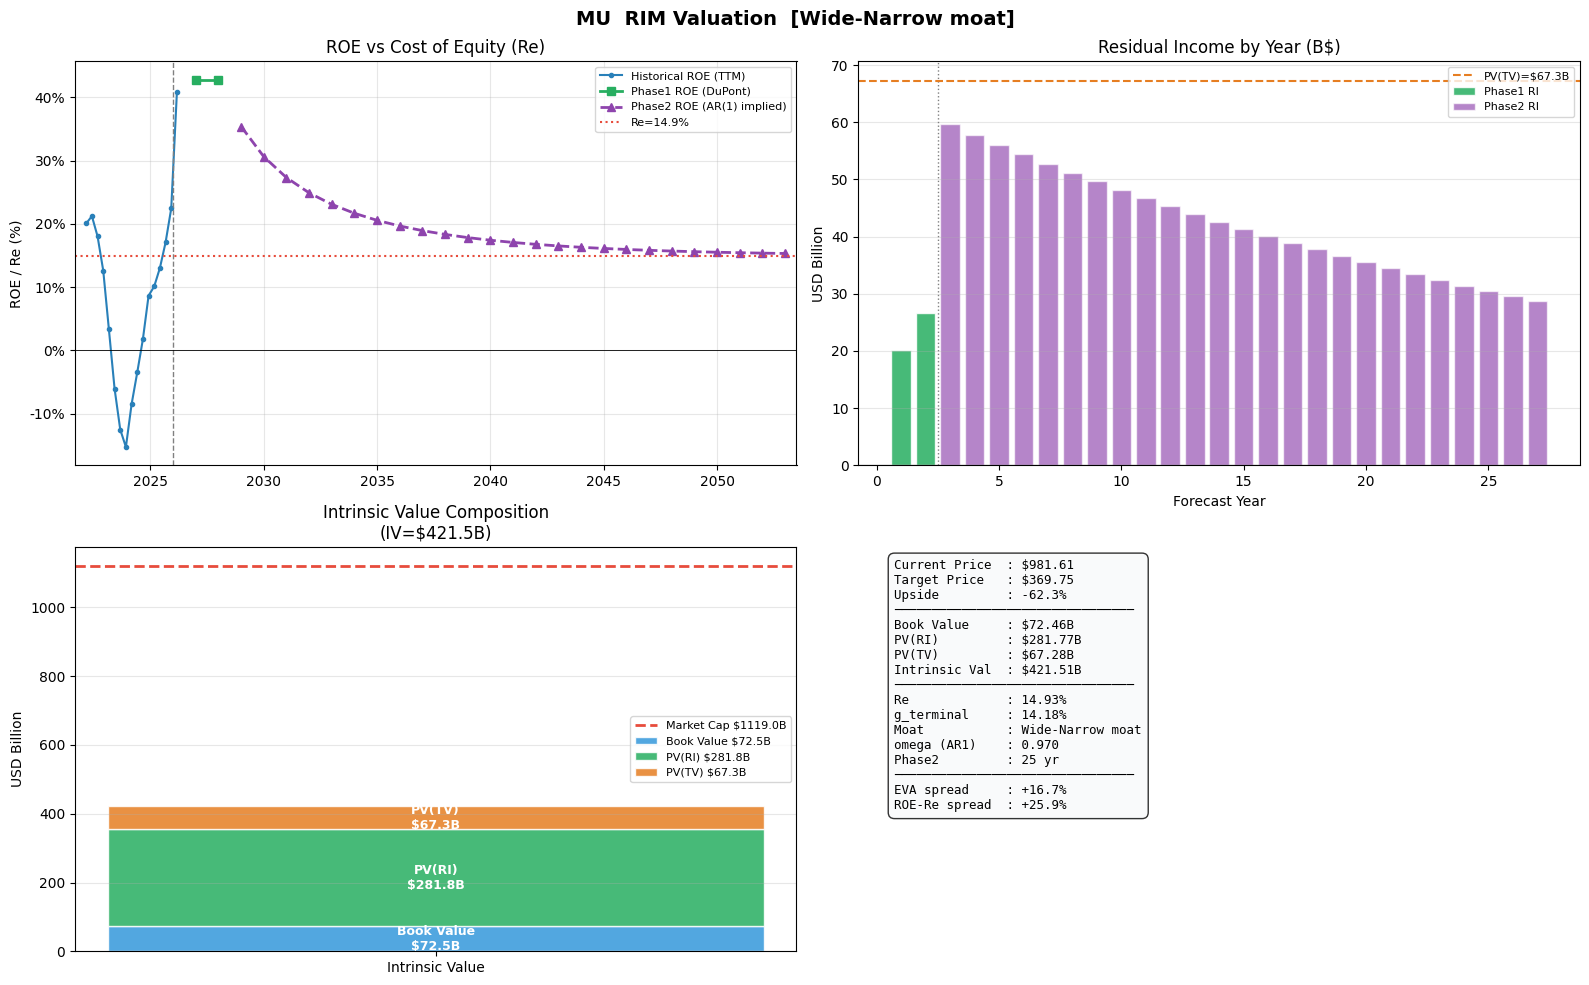

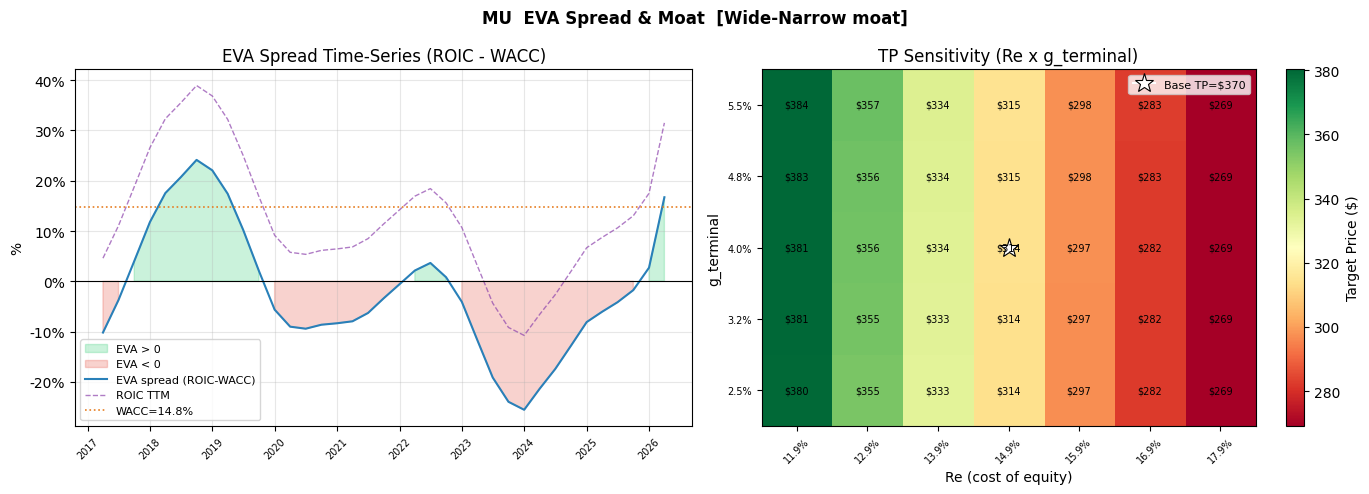

In [6]:
# ═══════════════════════════════════════════════════════════════
#  Cell 4.5 · RIM Diagnostics
# ═══════════════════════════════════════════════════════════════

DIAG_TICKER = "MU"   # <- change ticker

print(f"[Diagnostics] Running RIMModel for {DIAG_TICKER} ...")
_rm = RIMModel(ticker=DIAG_TICKER, engine=engine, verbose=True)
_rm.run()

v  = _rm.valuation
df = _rm.result_df.copy()

re        = v["re"]
bv0       = v["bv0"]
pv_ri     = v["pv_ri"]
pv_tv     = v["pv_tv"]
tv        = v["terminal_value"]
iv        = v["intrinsic_value"]
tp        = v["target_price"]
cp        = v["current_price"]
moat      = v["moat_label"]
omega     = v["omega"]
n_ph2     = v["n_phase2"]
eva_s     = v["eva_spread"]
roe_re    = v["roe_re_spread"]

SEP = "=" * 66
print(f"\n{SEP}")
print(f"  {DIAG_TICKER}  RIM Diagnostics")
print(SEP)

print(f"\n[1] Cost of Equity  [v9 FMP bottom-up CAPM + size/country premium]")
print(f"    Re_final      : {re*100:.4f}%")
print(f"    g_terminal    : {GDP_GROWTH*100:.2f}%")
print(f"    Re - g        : {(re-GDP_GROWTH)*100:.4f}%")
# Re 구성요소 상세 출력
Rf_d=0.045; ERP_d=0.055
try:
    import requests as _req
    _r = _req.get(f"https://financialmodelingprep.com/api/v3/beta/{DIAG_TICKER}",
                  params={"period":"monthly","apikey":FMP_API_KEY}, timeout=8)
    _d = _r.json()
    _beta = float((_d[0].get("beta",1.0) if isinstance(_d,list) and _d else _d.get("beta",1.0)) or 1.0)
    _beta_adj = 0.67*abs(_beta)+0.33
    _re_capm  = Rf_d + _beta_adj*ERP_d
    print(f"    β (raw)       : {_beta:.3f}  β_adj(Blume): {_beta_adj:.3f}")
    print(f"    CAPM          : {Rf_d*100:.1f}% + {_beta_adj:.3f}×{ERP_d*100:.1f}% = {_re_capm*100:.2f}%")
except Exception as _e:
    print(f"    CAPM          : beta 조회 실패 ({_e})")
print(f"    ERP used      : {ERP_d*100:.1f}%  Rf: {Rf_d*100:.1f}%  (Damodaran 2024)")
try:
    _detail = getattr(_rm, "_re_detail", {})
    if _detail:
        print(f"    Size premium : {_detail.get('size_premium', 0)*100:.2f}%")
        print(f"    Country prem.: {_detail.get('country_premium', 0)*100:.2f}%  country={_detail.get('country','')}")
        eyv = _detail.get("earnings_yield", np.nan)
        if pd.notna(eyv):
            print(f"    EY cross-check: {eyv*100:.2f}%")
except Exception:
    pass
print(f"    Range clipped : [7.5%, 18.0%]")

ph1_all = df[df["phase"].str.startswith("ph1")]  # ph1 + ph1e
ph1_fc  = df[df["phase"]=="ph1"]   # 실제 Sales forecast
ph1_ext = df[df["phase"]=="ph1e"]  # GDP 연장
n_fc  = len(ph1_fc);  n_ext = len(ph1_ext)
print(f"\n[2] Phase 1 — DuPont ROE  "
      f"[forecast {n_fc}yr + GDP연장 {n_ext}yr = 총 {n_fc+n_ext}yr]")
ph1 = ph1_all
for _, row in ph1.iterrows():
    ri_b = row["bv_start"]/1e9
    tag  = "" if row["phase"]=="ph1" else " [GDP연장]"
    print(f"    Year {row['year']}{tag}  "
          f"Sales={row['sales_annual']/1e9:.2f}B  "
          f"NPM={row['npm']*100:.1f}%  AT={row['at']:.2f}  FL={row['fl']:.1f}  "
          f"ROE={row['roe']*100:.1f}%  "
          f"BV={ri_b:.2f}B  RI={row['ri']/1e9:.3f}B")

print(f"\n[2.5] Phase 1 기간: {len(df[df['phase']=='ph1'])}yr  "
      f"(moat={moat} → PHASE1_YR_BY_MOAT 적용)")
print(f"\n[3] Phase 2 — AR(1) RI Decay  (omega={omega:.3f}  [{moat}]  {n_ph2}yr)")
ph2 = df[df["phase"]=="ph2"]
for _, row in ph2.iterrows():
    print(f"    Year {row['year']}  "
          f"RI={row['ri']/1e9:.3f}B  "
          f"ROE_impl={row['roe']*100:.1f}%  "
          f"spread={row['ri_spread']*100:+.1f}%  "
          f"BV={row['bv_start']/1e9:.2f}B")

print(f"\n[4] Terminal Value")
tv_str = f"${tv/1e9:.3f}B" if tv > 0 else "0 (RI_last <= 0)"
print(f"    RI_last  : ${_rm._ri_last/1e9:.3f}B")
print(f"    TV = RI_last / (Re - g) = {tv_str}")
print(f"    PV(TV)   : ${pv_tv/1e9:.3f}B")

print(f"\n[5] Value Breakdown")
bv_wt = bv0 / iv * 100 if iv != 0 else float("nan")
ri_wt = pv_ri / iv * 100 if iv != 0 else float("nan")
tv_wt = pv_tv / iv * 100 if iv != 0 else float("nan")
print(f"    Book Value : ${bv0/1e9:.3f}B  ({bv_wt:.1f}%)")
print(f"    PV(RI)     : ${pv_ri/1e9:.3f}B  ({ri_wt:.1f}%)")
print(f"    PV(TV)     : ${pv_tv/1e9:.3f}B  ({tv_wt:.1f}%)")
print(f"    Intrinsic  : ${iv/1e9:.3f}B")

print(f"\n[6] Target Price")
tp_s  = f"${tp:.2f}" if not np.isnan(tp) else "N/A"
up_s  = f"{v['upside_pct']:.1f}%" if not np.isnan(v["upside_pct"]) else "N/A"
print(f"    TP={tp_s}  Current=${cp:.2f}  Upside={up_s}")

print(f"\n[7] EVA / Moat  [v4 6-Tier]")
print(f"    EVA spread   : {eva_s*100:+.2f}%" if not np.isnan(eva_s) else "    EVA spread : N/A")
print(f"    ROE-Re spread: {roe_re*100:+.2f}%" if not np.isnan(roe_re) else "    ROE-Re : N/A")
print(f"    Moat grade   : {moat}")
print(f"    omega (AR1)  : {omega:.3f}")
print(f"    Phase2 period: {n_ph2} yr")
pv_factor_diag = sum(omega**t/(1+re)**t for t in range(1, n_ph2+1))
print(f"    PV factor    : {pv_factor_diag:.3f}x  (RI 씨드 대비 Phase2 PV 배수)")
print(f"\n[v4 등급 기준 참조]")
print(f"  [v6 등급 기준]")
print(f"  Exceptional: ω=0.990 30yr | EVA>25% OR ROE-Re>150%")
print(f"  Wide       : ω=0.980 28yr | EVA>15% OR ROE-Re> 80%")
print(f"  Wide-Narrow: ω=0.970 25yr | EVA>10% OR ROE-Re> 40%")
print(f"  Narrow     : ω=0.950 20yr | EVA> 6% OR ROE-Re> 20%")
print(f"  Some       : ω=0.920 15yr | EVA> 3% OR ROE-Re>  5%")
print(f"  No moat    : ω=0.800 10yr | 나머지")
print(f"  * 음수BV 기업(PM,MCD 등): IC(투하자본) 기반 자동 처리")
print(f"\n{SEP}\n")

# ── Visualisation ─────────────────────────────────────────────
_rm.plot()

# ── EVA time-series chart ─────────────────────────────────────
eva_series = v.get("eva_series", [])
if eva_series:
    wacc_val = _rm._eva.get("wacc", re)
    fig3, axes3 = plt.subplots(1, 2, figsize=(14, 5))
    fig3.suptitle(f"{DIAG_TICKER}  EVA Spread & Moat  [{moat}]", fontsize=12, fontweight="bold")

    ax = axes3[0]
    dates_e = [e["date"] for e in eva_series]
    spreads = [e["eva_spread"]*100 for e in eva_series]
    roics   = [e["roic"]*100 for e in eva_series]
    ax.fill_between(dates_e, spreads, 0, where=[s>0 for s in spreads],
                    color="#2ecc71", alpha=0.25, label="EVA > 0")
    ax.fill_between(dates_e, spreads, 0, where=[s<=0 for s in spreads],
                    color="#e74c3c", alpha=0.25, label="EVA < 0")
    ax.plot(dates_e, spreads, color="#2980b9", lw=1.5, label="EVA spread (ROIC-WACC)")
    ax.plot(dates_e, roics, color="#8e44ad", lw=1.0, ls="--", alpha=0.7, label="ROIC TTM")
    ax.axhline(0, color="black", lw=0.8)
    ax.axhline(wacc_val*100, color="#e67e22", lw=1.2, ls=":", label=f"WACC={wacc_val*100:.1f}%")
    ax.set_title("EVA Spread Time-Series (ROIC - WACC)")
    ax.set_ylabel("%")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{x:.0f}%"))
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    ax = axes3[1]
    # Sensitivity: Re x g → TP heatmap
    re_arr = np.linspace(max(re-0.03, 0.04), re+0.03, 7)
    g_arr  = np.linspace(max(GDP_GROWTH-0.015, 0.01), GDP_GROWTH+0.015, 5)
    tp_mat = np.full((len(g_arr), len(re_arr)), np.nan)
    all_ri = df["ri"].values
    T_tot  = len(all_ri)
    ri_last_val = _rm._ri_last
    shares_val  = v["shares"]

    for ri_i, re_ in enumerate(re_arr):
        for g_i, g_ in enumerate(g_arr):
            if re_ <= g_: continue
            pv_ri_ = sum(all_ri[t] / (1+re_)**(t+1) for t in range(T_tot))
            tv_    = ri_last_val / (re_ - g_) if ri_last_val > 0 else 0
            pv_tv_ = tv_ / (1+re_)**T_tot
            iv_    = bv0 + pv_ri_ + pv_tv_
            tp_mat[g_i, ri_i] = iv_ / shares_val if (not np.isnan(shares_val) and shares_val > 0) else np.nan

    _valid = tp_mat[~np.isnan(tp_mat)]
    if len(_valid) > 0:
        im = ax.imshow(tp_mat, aspect="auto", cmap="RdYlGn",
                       vmin=np.nanpercentile(tp_mat, 10),
                       vmax=np.nanpercentile(tp_mat, 90), origin="lower")
        plt.colorbar(im, ax=ax, label="Target Price ($)")
        for gi in range(len(g_arr)):
            for ri_i in range(len(re_arr)):
                val = tp_mat[gi, ri_i]
                if not np.isnan(val):
                    ax.text(ri_i, gi, f"${val:.0f}", ha="center", va="center", fontsize=7)
        ax.set_xticks(range(len(re_arr)))
        ax.set_xticklabels([f"{r*100:.1f}%" for r in re_arr], rotation=45, fontsize=7)
        ax.set_yticks(range(len(g_arr)))
        ax.set_yticklabels([f"{g_*100:.1f}%" for g_ in g_arr], fontsize=7)
        ci_b = np.argmin(np.abs(re_arr - re))
        gi_b = np.argmin(np.abs(g_arr  - GDP_GROWTH))
        ax.plot(ci_b, gi_b, marker="*", ms=14, color="white",
                markeredgecolor="black", markeredgewidth=0.8,
                label=f"Base TP={f'${tp:.0f}' if not np.isnan(tp) else 'N/A'}")
        ax.legend(fontsize=8)
    else:
        ax.axis("off")
        ax.text(0.5, 0.5, "All TP values invalid", transform=ax.transAxes,
                ha="center", va="center", fontsize=11)
    ax.set_xlabel("Re (cost of equity)")
    ax.set_ylabel("g_terminal")
    ax.set_title("TP Sensitivity (Re x g_terminal)")

    plt.tight_layout()
    plt.show()


## Cell 4.6 (NEW v12) · Validity Patch — 통화 가드 + TV 보수화 + Sanity Guard

**v11 결과(상위 600개) 검증에서 확인된 문제와 수정**

| # | 문제 (v11) | 증상 | 수정 (v12) |
|---|---|---|---|
| 1 | **TV 영구성장 가정 `g = max(Re−0.75%, GDP)`** — 600개 전 종목의 Re−g 스프레드가 정확히 0.75%, RI 영구멀티플 (1+g)/(Re−g) ≈ **147배** 균일 적용. 잔여이익(초과이익)이 영원히 연 9~14% 성장한다는 가정은 Phase 2 의 ω 감쇠 설계와 모순 | LOW 43,869%·BA 21,285% 등 미국 우량기업까지 upside 폭발 (LOW 내재가치/시총 447배) | 기본 **'ohlson' 모드**: TV = RI_T·ω/(1+Re−ω) — Phase 2 의 AR(1) 지속계수 ω 감쇠를 영구 연장 (moat 등급별 차등: ω 0.992 → ~9배, ω 0.62 → ~1.2배). 선택 'gordon' 모드: g ≤ min(GDP, Rf, Re−2%). 공통 TV ≤ 35×RI 상한 |
| 2 | **통화 불일치 (ADR)** — FMP 재무제표는 현지통화, 주가는 USD, 주식수는 현지 상장 기준 | MBT upside 1.9억%, TLK 131만%, EC 59만% 등 해외기업 상위 도배 | `reportedCurrency ≠ USD` → 평가 제외 |
| 3 | **시총 괴리 검증 부재** | 내재가치/시총 수백~수십만 배도 그대로 저장 (상위 600개 중 29개) | 내재가치 vs 실제 시총 ±30배 초과 → 평가 제외 |
| 4 | **upsert 부분 갱신** — 동일 (ticker,date,year_label) 재저장 시 6개 컬럼만 갱신 → re·g_terminal·rho 가 옛 값으로 남는 혼합 행 | 같은 날 재측정 시 데이터 오염 | 전 컬럼 갱신 + `created_at` 재기록 |

**'ohlson' 모드의 g_terminal 저장값**: RI 의 연간 변화율 = **ω − 1** (음수 = 감쇠율)을 저장합니다. 예: ω=0.992 → g_terminal = −0.008 (RI 가 매년 0.8% 감쇠). 조회 노트북의 g_term(%) 칼럼에서 음수로 표시되는 것이 정상입니다.

**잔여 한계**: BV 가 음수(대규모 자사주 매입)인 기업은 `_estimate_ic()` 대체로 인해 여전히 불확실성이 큽니다. 통합 선정 단계의 `UPSIDE_CAP=150%` 와 병행을 권장합니다.

상수 6개(`V12_*`)로 모드/임계값 조정 가능. 원본은 `_compute_valuation_v11`/`_save_to_db_v11`/`_run_v11` 로 보존됩니다.

In [7]:
# ═══════════════════════════════════════════════════════════════════════
#  Cell 4.6 (NEW v12) · Validity Patch
#  ───────────────────────────────────────────────────────────────────────
#  ① 통화 가드      : 재무제표 reportedCurrency ≠ USD → 평가 제외 (ADR 차단)
#  ② TV 보수화      : 기존 g = max(Re−0.75%, GDP) — RI가 영구히 Re−0.75%로
#                     성장한다는 가정으로 RI 영구멀티플 ~147배 양산 → 폐지.
#                     기본 'ohlson' 모드: TV = RI_T × ω / (1 + Re − ω)
#                     (Phase 2의 AR(1) 지속계수 ω 감쇠를 영구 연장 — 모형 정합)
#                     선택 'gordon' 모드: g = min(GDP, Rf, Re−2%)
#                     공통: TV ≤ 35 × RI_T (이중 안전장치)
#  ③ Sanity Guard   : |산출 내재가치 / 실제 시총| > 30배 (또는 < 1/30) → 제외
#  ④ save_to_db     : 동일 (ticker,date,year_label) 재저장 시 전 컬럼 갱신
#
#  ※ Cell 4 실행 후, Cell 5(Batch) 전에 반드시 실행하세요.
#  ※ 원본 보존: _compute_valuation_v11 / _save_to_db_v11 / _run_v11
# ═══════════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import requests

# ── v12 가드 상수 — 여기만 수정하세요 ───────────────────────────────────
V12_CURRENCY_GUARD   = True       # ① 재무제표 통화 ≠ USD → 제외
V12_TV_MODE          = "ohlson"   # ② "ohlson"(ω 감쇠 연장, 기본) | "gordon"
V12_MIN_TV_SPREAD    = 0.02       # ② gordon 모드: Re − g 최소 스프레드
V12_TV_RI_MULT_CAP   = 35.0       # ② TV / RI_T 배수 상한 (이중 안전장치)
V12_SANITY_GUARD     = True       # ③ 내재가치/시총 괴리 검사
V12_SANITY_MC_RATIO  = 30.0       # ③ 허용 배율 (±30배)


# ════════════════════════════════════════════════════════════════════
#  ① 통화 가드 — FMP income-statement 의 reportedCurrency 활용
# ════════════════════════════════════════════════════════════════════
def _check_currency_v12(self):
    """재무제표 통화 확인. USD 가 아니면 ValueError → batch 에서 fail 기록.

    근거: FMP 는 ADR(MBT·TLK·EC·PKX·KT 등)의 재무제표를 현지통화로,
          주가는 USD 로 반환. BV·NI·주식수가 모두 현지 기준이라
          내재가치/주가 비교가 통화 차원에서 성립하지 않음 → 제외가 안전.
    """
    cur = None
    inc = getattr(self, "_inc", None)
    if inc is not None and not inc.empty and "reportedCurrency" in inc.columns:
        s = inc["reportedCurrency"].dropna().astype(str).str.upper()
        if not s.empty:
            cur = s.mode().iloc[0]
    self._reported_currency = cur or "UNKNOWN"

    if cur is None:
        if self.verbose:
            log(self.ticker, "⚠ [v12] reportedCurrency 필드 없음 → 통화 검사 생략(USD 가정)")
        return
    if V12_CURRENCY_GUARD and cur != "USD":
        raise ValueError(
            f"[{self.ticker}] v12 통화 가드: 재무제표 통화={cur}, 주가=USD(ADR) "
            f"→ 내재가치/주가 비교 불가로 평가 제외")
    if self.verbose:
        log(self.ticker, f"[v12] 통화 검사 통과: reportedCurrency={cur}")


# ════════════════════════════════════════════════════════════════════
#  ②+③ compute_valuation v12 — Ohlson 정합 TV + Sanity Guard
#       (변경점은 ★v12 주석 3곳, 나머지는 Cell 4 v11 원본과 동일)
# ════════════════════════════════════════════════════════════════════
def compute_valuation_v12(self) -> "RIMModel":
    """
    Ohlson (1995) RIM:
        P = BV_0 + PV(RI_Phase1) + PV(RI_Phase2) + PV(TV)

        TV (v12, 기본 'ohlson'):
            Phase 2 에서 쓰던 AR(1) 지속계수 ω 의 감쇠를 영구 연장
            TV = Σ_{k≥1} RI_T·ω^k / (1+Re)^k = RI_T · ω / (1 + Re − ω)
        TV (v12, 'gordon'):
            TV = RI_T·(1+g) / (Re − g),  g = min(GDP, Rf, Re − 2%)

    Discount rate: Re (cost of equity) — equity-side model.
    """
    re        = self._re
    df        = self.result_df.copy()

    # ── Book Value at t=0 (음수 BV → IC 대체) ─────────────
    bs = self._bs.copy()
    bs["eq"] = pd.to_numeric(bs.get("totalStockholdersEquity", np.nan), errors="coerce")
    bv0_raw = float(bs.dropna(subset=["eq"])["eq"].iloc[-1])
    bv0 = bv0_raw if bv0_raw > 0 else self._estimate_ic()

    # ── PV of all RI rows ─────────────────────────────────
    pv_ri_total = 0.0
    pv_rows     = []
    for t, (_, row) in enumerate(df.iterrows(), 1):
        pv = row["ri"] / (1 + re) ** t
        pv_ri_total += pv
        pv_rows.append(pv)
    df["pv_ri"] = pv_rows

    T = len(df)

    # ★v12-1: Terminal Value — 'RI 영구성장(g=Re−0.75%)' 가정 폐지
    #   기존: g_tv = max(re − TV_RE_GAP, gdp) → 스프레드 0.75% 고정,
    #         RI 영구멀티플 (1+g)/(re−g) ≈ 147배 (전 종목 동일) → upside 폭발
    #   v12 : Phase 2 와 동일한 ω 감쇠를 영구 연장하거나(기본),
    #         보수적 Gordon(g ≤ min(GDP, Rf, Re−2%)) 중 선택
    ri_last = self._ri_last
    omega   = float(getattr(self, "_omega", 0.62) or 0.62)
    tv      = 0.0
    tv_capped = False
    if str(V12_TV_MODE).lower() == "gordon":
        rf_v12 = float((getattr(self, "_re_detail", {}) or {}).get("rf", 0.045))
        g_tv = min(self.gdp_growth, rf_v12, re - V12_MIN_TV_SPREAD)
        g_tv = max(g_tv, 0.0)
        if ri_last > 0 and re > g_tv:
            tv = ri_last * (1.0 + g_tv) / (re - g_tv)
    else:  # 'ohlson' (기본): RI_{T+k} = RI_T · ω^k
        om = float(np.clip(omega, 0.0, 0.992))
        if ri_last > 0:
            tv = ri_last * om / (1.0 + re - om)
        g_tv = om - 1.0   # 참고치: RI 의 연 성장률 = ω−1 (감쇠율, DB g_terminal 에 저장)

    # ★v12-2: TV/RI 배수 상한 (이중 안전장치)
    if ri_last > 0 and tv > V12_TV_RI_MULT_CAP * ri_last:
        tv = V12_TV_RI_MULT_CAP * ri_last
        tv_capped = True
    tv_ri_mult = tv / ri_last if ri_last > 0 else np.nan
    pv_tv = tv / (1 + re) ** T if tv != 0 else 0.0

    # ── Intrinsic Value ───────────────────────────────────
    intrinsic = bv0 + pv_ri_total + pv_tv

    # ── Shares ────────────────────────────────────────────
    inc = self._inc
    shares = np.nan
    for col in ["weightedAverageShsOutDil", "weightedAverageShsOut"]:
        if col in inc.columns:
            s = pd.to_numeric(inc[col].iloc[-1], errors="coerce")
            if pd.notna(s) and s > 0:
                shares = float(s); break

    target_price = intrinsic / shares if (not np.isnan(shares) and shares > 0) else np.nan

    # ── Current Price ─────────────────────────────────────
    current_price = np.nan
    try:
        r = requests.get(f"{FMP_BASE}/quote/{self.ticker}",
                         params={"apikey": self.api_key}, timeout=10)
        data = r.json()
        if isinstance(data, list) and data:
            current_price = float(data[0].get("price", np.nan) or np.nan)
    except Exception:
        pass

    upside = ((target_price / current_price) - 1) * 100 if (
        not np.isnan(target_price) and not np.isnan(current_price) and current_price > 0
    ) else np.nan

    tv_wt = pv_tv / (bv0 + pv_ri_total + pv_tv) * 100 if (bv0 + pv_ri_total + pv_tv) != 0 else np.nan

    # ★v12-3: Sanity Guard — 산출 내재가치 vs 실제 시총(USD) 괴리 검사
    mkt_cap_actual = np.nan
    try:
        mkt_cap_actual = float((getattr(self, "_re_detail", {}) or {}).get("mkt_cap", np.nan) or np.nan)
    except (TypeError, ValueError):
        mkt_cap_actual = np.nan
    if not np.isfinite(mkt_cap_actual):
        prof = self._fmp_get_profile()
        try:
            mkt_cap_actual = float(prof.get("mkt_cap", np.nan) or np.nan)
        except (TypeError, ValueError):
            mkt_cap_actual = np.nan
    mc_ratio = (intrinsic / mkt_cap_actual
                if np.isfinite(mkt_cap_actual) and mkt_cap_actual > 1e6 else np.nan)
    if V12_SANITY_GUARD and np.isfinite(mc_ratio):
        if mc_ratio > V12_SANITY_MC_RATIO or 0 < mc_ratio < 1.0 / V12_SANITY_MC_RATIO:
            raise ValueError(
                f"[{self.ticker}] v12 sanity guard: 산출 내재가치 "
                f"${intrinsic/1e9:,.1f}B vs 실제 시총 ${mkt_cap_actual/1e9:,.1f}B "
                f"= {mc_ratio:,.1f}배 (허용 ±{V12_SANITY_MC_RATIO:.0f}배) → 평가 제외. "
                f"입력 데이터(통화/주식수/BV/ROE) 점검 필요")

    self.result_df = df
    self.valuation = {
        "ticker":          self.ticker,
        "re":              re,
        "g_terminal":      g_tv,
        "bv0":             bv0,
        "pv_ri":           pv_ri_total,
        "terminal_value":  tv,
        "pv_tv":           pv_tv,
        "tv_weight_pct":   tv_wt,
        "intrinsic_value": intrinsic,
        "shares":          shares,
        "target_price":    target_price,
        "current_price":   current_price,
        "upside_pct":      upside,
        "moat_label":      self._moat_label,
        "omega":           self._omega,
        "n_phase2":        self._n_phase2,
        "eva_spread":      self._eva.get("eva_spread", np.nan),
        "roic":            self._eva.get("roic",       np.nan),
        "roe_re_spread":   self._eva.get("roe_re_spread", np.nan),
        "eva_series":      self._eva.get("eva_series", []),
        # ★v12 진단 키 (DB 미저장 — 화면 확인용)
        "tv_mode":          str(V12_TV_MODE).lower(),
        "tv_ri_multiple":   tv_ri_mult,
        "tv_capped":        tv_capped,
        "mktcap_actual":    mkt_cap_actual,
        "mktcap_ratio":     mc_ratio,
        "reported_currency": getattr(self, "_reported_currency", "UNKNOWN"),
    }

    if self.verbose:
        log(self.ticker,
            f"RIM [v12·{V12_TV_MODE}]  BV={bv0/1e9:.2f}B  PV(RI)={pv_ri_total/1e9:.2f}B  "
            f"PV(TV)={pv_tv/1e9:.2f}B (RI배수 {tv_ri_mult:.1f}x)  IV={intrinsic/1e9:.2f}B  "
            f"TP=${target_price:.2f}  Upside={upside:.1f}%  시총배율={mc_ratio:.1f}x")
    return self


# ════════════════════════════════════════════════════════════════════
#  ④ save_to_db v12 — 동일 (ticker,date,year_label) 재저장 시 전 컬럼 갱신
#     (기존: ri/roe/TP/upside/IV/moat 6개만 갱신 → 같은 날 재측정 시
#      re·g_terminal·rho 등이 옛 값으로 남는 혼합 행 발생)
# ════════════════════════════════════════════════════════════════════
def save_to_db_v12(self, run_date: str = None) -> int:
    if self.result_df is None or self.valuation is None:
        return 0
    run_date = run_date or datetime.now().strftime("%Y-%m-%d")
    v  = self.valuation
    df = self.result_df.copy()

    def _n(val):
        """NaN / Inf → None (pymysql은 float NaN 거부)"""
        if val is None: return None
        try:
            f = float(val)
            return None if (np.isnan(f) or np.isinf(f)) else (
                f if isinstance(val, (int, float, np.floating, np.integer)) else val)
        except (TypeError, ValueError):
            return val

    rows = []
    for _, row in df.iterrows():
        rows.append({
            "date":           run_date,
            "ticker":         self.ticker,
            "year_label":     str(row.get("year", "")),
            "phase":          row.get("phase", ""),
            "sales_forecast": _n(row.get("sales_annual")),
            "npm_forecast":   _n(row.get("npm")),
            "asset_turnover": _n(row.get("at")),
            "fin_leverage":   _n(row.get("fl")),
            "roe_forecast":   _n(row.get("roe")),
            "re":             _n(row.get("re")),
            "ri_spread":      _n(row.get("ri_spread")),
            "bv_start":       _n(row.get("bv_start")),
            "ri":             _n(row.get("ri")),
            "pv_ri":          _n(row.get("pv_ri")),
            "moat_label":     v.get("moat_label"),
            "rho":            _n(v.get("omega")),
            "n_phase2":       _n(v.get("n_phase2")),
            "g_terminal":     _n(v.get("g_terminal")),
            "pv_all_ri":      _n(v.get("pv_ri")),
            "terminal_value": _n(v.get("terminal_value")),
            "intrinsic_value":_n(v.get("intrinsic_value")),
            "current_price":  _n(v.get("current_price")),
            "upside_pct":     _n(v.get("upside_pct")),
            "target_price":   _n(v.get("target_price")),
        })

    sql = f"""
        INSERT INTO `{TABLE_RESULT}`
        (date, ticker, year_label, phase,
         sales_forecast, npm_forecast, asset_turnover, fin_leverage,
         roe_forecast, re, ri_spread, bv_start, ri, pv_ri,
         moat_label, rho, n_phase2, g_terminal,
         pv_all_ri, terminal_value, intrinsic_value,
         current_price, upside_pct, target_price)
        VALUES
        (%(date)s, %(ticker)s, %(year_label)s, %(phase)s,
         %(sales_forecast)s, %(npm_forecast)s, %(asset_turnover)s, %(fin_leverage)s,
         %(roe_forecast)s, %(re)s, %(ri_spread)s, %(bv_start)s, %(ri)s, %(pv_ri)s,
         %(moat_label)s, %(rho)s, %(n_phase2)s, %(g_terminal)s,
         %(pv_all_ri)s, %(terminal_value)s, %(intrinsic_value)s,
         %(current_price)s, %(upside_pct)s, %(target_price)s)
        ON DUPLICATE KEY UPDATE
            phase=VALUES(phase), sales_forecast=VALUES(sales_forecast),
            npm_forecast=VALUES(npm_forecast), asset_turnover=VALUES(asset_turnover),
            fin_leverage=VALUES(fin_leverage), roe_forecast=VALUES(roe_forecast),
            re=VALUES(re), ri_spread=VALUES(ri_spread), bv_start=VALUES(bv_start),
            ri=VALUES(ri), pv_ri=VALUES(pv_ri),
            moat_label=VALUES(moat_label), rho=VALUES(rho),
            n_phase2=VALUES(n_phase2), g_terminal=VALUES(g_terminal),
            pv_all_ri=VALUES(pv_all_ri), terminal_value=VALUES(terminal_value),
            intrinsic_value=VALUES(intrinsic_value),
            current_price=VALUES(current_price), upside_pct=VALUES(upside_pct),
            target_price=VALUES(target_price),
            created_at=CURRENT_TIMESTAMP
    """
    conn = get_conn()
    try:
        with conn.cursor() as cur:
            cur.executemany(sql, rows)
        conn.commit()
    except Exception:
        conn.rollback(); raise
    finally:
        conn.close()
    return len(rows)


# ════════════════════════════════════════════════════════════════════
#  run v12 — 통화 가드를 RI 계산 '이전'에 배치
# ════════════════════════════════════════════════════════════════════
def run_v12(self) -> "RIMModel":
    self.load_sales()
    self.load_financials()
    self._check_currency_v12()      # ★v12 ①
    self.load_re()
    self.compute_ri_path()
    self.compute_valuation()        # ★v12 ②③ 내장
    return self


# ── 패치 적용 (원본 보존) ────────────────────────────────────────────────
if not hasattr(RIMModel, "_compute_valuation_v11"):
    RIMModel._compute_valuation_v11 = RIMModel.compute_valuation
if not hasattr(RIMModel, "_save_to_db_v11"):
    RIMModel._save_to_db_v11 = RIMModel.save_to_db
if not hasattr(RIMModel, "_run_v11"):
    RIMModel._run_v11 = RIMModel.run

RIMModel._check_currency_v12 = _check_currency_v12
RIMModel.compute_valuation   = compute_valuation_v12
RIMModel.save_to_db          = save_to_db_v12
RIMModel.run                 = run_v12

print("=" * 72)
print("[v12] RIM Validity Patch 적용 완료")
print(f"  ① 통화 가드     : {'ON' if V12_CURRENCY_GUARD else 'OFF'} (reportedCurrency ≠ USD → 제외)")
print(f"  ② TV 보수화     : mode='{V12_TV_MODE}'  "
      f"(ohlson: TV=RI·ω/(1+Re−ω) | gordon: g≤min(GDP,Rf,Re−{V12_MIN_TV_SPREAD:.0%}))")
print(f"                    + TV ≤ {V12_TV_RI_MULT_CAP:.0f}×RI 상한  "
      f"(기존 g=Re−0.75% → RI 영구멀티플 147배 폐지)")
print(f"  ③ Sanity Guard  : {'ON' if V12_SANITY_GUARD else 'OFF'} "
      f"(내재가치/시총 ±{V12_SANITY_MC_RATIO:.0f}배 초과 → 제외)")
print( "  ④ save_to_db    : 동일 (ticker,date,year_label) 재저장 시 전 컬럼 갱신 + created_at 갱신")
print( "  ※ 제외 종목은 batch 에서 status='fail' + 사유(msg)로 기록됩니다")
print("=" * 72)


[v12] RIM Validity Patch 적용 완료
  ① 통화 가드     : ON (reportedCurrency ≠ USD → 제외)
  ② TV 보수화     : mode='ohlson'  (ohlson: TV=RI·ω/(1+Re−ω) | gordon: g≤min(GDP,Rf,Re−2%))
                    + TV ≤ 35×RI 상한  (기존 g=Re−0.75% → RI 영구멀티플 147배 폐지)
  ③ Sanity Guard  : ON (내재가치/시총 ±30배 초과 → 제외)
  ④ save_to_db    : 동일 (ticker,date,year_label) 재저장 시 전 컬럼 갱신 + created_at 갱신
  ※ 제외 종목은 batch 에서 status='fail' + 사유(msg)로 기록됩니다


In [9]:
# ═══════════════════════════════════════════════════════════════════
#  Cell 4.7 (★ NEW v12) · RIMModel Excel Export — 노트북 인라인
# ═══════════════════════════════════════════════════════════════════
#  korea_rim_valuation_v5 의 export_rim_excel (8-sheet) 패턴을
#  US RIMModel 구조에 맞게 어댑테이션.
#    · ticker_dg → ticker
#    · _fs_wide  → _inc / _bs (FMP 컬럼명)
#    · beta_blume → _re_detail['beta_adj'],  rf/e_rm → _re_detail
#    · estimate_dupont_coefs()['npm_coef'] → ['npm_slope']
#    · 통화 원 → USD ($)
#
#  주입 메서드 (RIMModel 에 monkey-patch):
#    ① _fetch_rim_extras   — 10Y 월간 종가 (Beta 시트용, best-effort)
#    ② export_rim_excel    — 8-sheet workbook 빌드 & 저장
#
#  옵션 B 패턴: Re, BV₀, PV(RI), PV(TV) 를 model.valuation 직접 입력
#               → Excel TP = Model TP 자동 일치 (Δ = 0 보장)
#
#  사용 예
#    model = RIMModel(ticker="NXST", ...).run()
#    out_path = model.export_rim_excel(out_dir="C:/us valuation results")
# ═══════════════════════════════════════════════════════════════════

from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd

# ── 스타일 상수 ─────────────────────────────────────────────────────
_NAVY, _TEAL, _GOLD       = "0D1B2A", "0E7C7B", "F4A261"
_ZEBRA, _ASSUMP           = "F5F7FA", "FFF9C4"
_GREY, _BLUE              = "D9D9D9", "0000FF"
_PHASE1_BG, _PHASE2_BG, _PHASE3_BG = "E8F4F8", "FFF4D6", "F0E5C8"
_LINK_BG = "E0F0FF"

# ★ USD 포맷 (한국 원화 → 달러)
_FMT_INT, _FMT_PCT, _FMT_PCT3, _FMT_DEC = (
    "#,##0;[Red](#,##0);-", "0.00%", "0.000%", "0.0000"
)
_FMT_USD   = '$#,##0;[Red]($#,##0);-'      # 대형 금액 (IV / BV / PV)
_FMT_PRICE = '$#,##0.00'                   # 주가 (소수 2자리)

_THIN   = Side(style="thin", color=_GREY)
_BORDER = Border(left=_THIN, right=_THIN, top=_THIN, bottom=_THIN)


def _is_nan(x):
    return isinstance(x, float) and np.isnan(x)

def _safe_pct_fraction(x):
    """percent-points(예: 9.83) → fraction(0.0983). 이미 fraction이면 그대로."""
    if x is None or _is_nan(x):
        return np.nan
    x = float(x)
    return x / 100.0 if abs(x) > 1.0 else x


# ── Style helper 함수 ──────────────────────────────────────────────
def _set_label(cell, text, bold=False, italic=False, size=10, color="000000"):
    cell.value = text
    cell.font  = Font(name="Calibri", size=size, bold=bold, italic=italic, color=color)
    cell.alignment = Alignment(horizontal="left")
    cell.border = _BORDER

def _set_input(cell, value, fmt):
    cell.value = value
    cell.number_format = fmt
    cell.fill = PatternFill("solid", start_color=_ASSUMP)
    cell.font = Font(name="Calibri", size=10, color=_BLUE, bold=True)
    cell.alignment = Alignment(horizontal="right")
    cell.border = _BORDER

def _set_computed(cell, value, fmt, highlight=False, final=False):
    cell.value = value
    cell.number_format = fmt
    if final:
        cell.fill = PatternFill("solid", start_color=_NAVY)
        cell.font = Font(name="Calibri", size=12, bold=True, color="FFFFFF")
    elif highlight:
        cell.fill = PatternFill("solid", start_color=_GOLD)
        cell.font = Font(name="Calibri", size=11, bold=True)
    else:
        cell.fill = PatternFill("solid", start_color=_LINK_BG)
        cell.font = Font(name="Calibri", size=10)
    cell.alignment = Alignment(horizontal="right")
    cell.border = _BORDER

def _section_header(ws, row, text, span=6, color=_TEAL):
    ws.merge_cells(start_row=row, start_column=1, end_row=row, end_column=span)
    h = ws.cell(row=row, column=1, value=text)
    h.font = Font(name="Calibri", size=12, bold=True, color="FFFFFF")
    h.fill = PatternFill("solid", start_color=color)
    h.alignment = Alignment(horizontal="center", vertical="center")
    ws.row_dimensions[row].height = 24


# ════════════════════════════════════════════════════════════════════
#  ① _fetch_rim_extras  (10Y monthly close — Beta 시트용, best-effort)
# ════════════════════════════════════════════════════════════════════

def _fetch_rim_extras(self, years: int = 10) -> None:
    """Beta_Regression 시트용 10Y 월간 종가 fetch (S&P500 대비).
    US 월간 종가 스키마가 환경마다 달라 best-effort — 실패 시 빈 DF (모형 beta fallback)."""
    self._monthly_prices  = pd.DataFrame()
    self._monthly_returns = pd.DataFrame()
    try:
        engine = getattr(self, "engine", None)
        if engine is None:
            return
        end_dt   = datetime.today()
        start_dt = end_dt.replace(year=end_dt.year - years)
        # cursor.execute → fetchall → DataFrame (pd.read_sql 미사용)
        conn = engine.raw_connection()
        try:
            with conn.cursor() as cur:
                cur.execute(
                    "SELECT date, close_price FROM us_stock_daily_market_cap "
                    "WHERE ticker = %s AND date >= %s AND close_price > 0 "
                    "ORDER BY date",
                    (self.ticker, start_dt.strftime("%Y-%m-%d")))
                rows = cur.fetchall()
                cols = [d[0] for d in cur.description]
        finally:
            conn.close()
        if not rows:
            return
        df = pd.DataFrame(rows, columns=cols)
        df["date"] = pd.to_datetime(df["date"])
        tkr_m = (df.set_index("date").sort_index()["close_price"]
                   .resample("ME").last().dropna().tail(years * 12))
        spx = getattr(self, "spx", None)  # 선택적 시장지수 (없으면 skip)
        if spx is None or len(spx) == 0:
            return
        spx_ser = pd.Series(np.asarray(spx.values), index=pd.to_datetime(spx.index))
        spx_m = spx_ser.resample("ME").last().dropna().tail(years * 12)
        merged = pd.DataFrame({self.ticker: tkr_m, "SP500": spx_m}).dropna()
        if not merged.empty:
            self._monthly_prices  = merged
            self._monthly_returns = merged.pct_change().dropna()
    except Exception as e:
        if getattr(self, "verbose", False):
            print(f"[{self.ticker}] _fetch_rim_extras best-effort fail: {e}")


# ════════════════════════════════════════════════════════════════════
#  Sheet 1: {ticker}_RIM (Summary)
# ════════════════════════════════════════════════════════════════════

def _build_summary_rim(model, wb, ticker):
    ws = wb.active
    ws.title = f"{ticker}_RIM"
    ws.merge_cells("A1:F1")
    t = ws["A1"]
    t.value = f"{ticker} — US RIM Valuation v12 (단위: USD)"
    t.font  = Font(name="Calibri", size=14, bold=True, color="FFFFFF")
    t.fill  = PatternFill("solid", start_color=_NAVY)
    t.alignment = Alignment(horizontal="center", vertical="center")
    ws.row_dimensions[1].height = 30

    v   = model.valuation
    det = getattr(model, "_re_detail", {}) or {}
    bv_src = "IC_fallback" if getattr(model, "_using_ic", False) else "Equity"
    rev_q  = len(getattr(model, "_inc", [])) if getattr(model, "_inc", None) is not None else 0

    # Section A — 종목 정보
    _section_header(ws, 3, "종목 정보 (Stock Info)", 6, _TEAL)
    info_rows = [
        ("Ticker",            v.get("ticker", ticker)),
        ("분석일자",           datetime.now().strftime("%Y-%m-%d")),
        ("재무 분기 데이터",   f"{rev_q}개"),
        ("매출 예측 모델",     v.get("forecast_model", "Ensemble")),
        ("예측 생성일",        str(v.get("forecast_date", "N/A"))),
        ("BV 출처",           bv_src),
    ]
    for i, (k, val_) in enumerate(info_rows, start=5):
        _set_label(ws.cell(row=i, column=1), k)
        c = ws.cell(row=i, column=2, value=val_)
        c.alignment = Alignment(horizontal="right"); c.border = _BORDER

    # Section B — 핵심 결과
    _section_header(ws, 13, "핵심 결과 (Key Results) ★ Excel = Model 일치", 6, _GOLD)
    tp = v.get("target_price", np.nan)
    cp = v.get("current_price", np.nan)
    up = _safe_pct_fraction(v.get("upside_pct", np.nan))
    iv = v.get("intrinsic_value", np.nan)
    res_rows = [
        (15, "적정주가 ★",          tp,  _FMT_PRICE, "final"),
        (16, "현재 주가",            cp,  _FMT_PRICE, "comp"),
        (17, "Upside / (Downside)", up,  _FMT_PCT,   "highlight"),
        (19, "Intrinsic Value",     iv,  _FMT_USD,   "comp"),
        (20, "발행주식수",           v.get("shares", np.nan), _FMT_INT, "comp"),
    ]
    for r, label, val_, fmt, kind in res_rows:
        _set_label(ws.cell(row=r, column=1), label, bold=(kind in ("final", "highlight")))
        c = ws.cell(row=r, column=2)
        vv = "N/A" if _is_nan(val_) else val_
        _set_computed(c, vv, fmt, highlight=(kind == "highlight"), final=(kind == "final"))

    # Section C — 모형 가정
    _section_header(ws, 23, "모형 가정 (Model Assumptions)", 6, _TEAL)
    a_rows = [
        (25, "Re (CAPM+)",               v.get("re", np.nan),               _FMT_PCT),
        (26, "  β_adj",                  det.get("beta_adj", np.nan),       _FMT_DEC),
        (27, "  β_raw",                  det.get("beta_raw", np.nan),       _FMT_DEC),
        (29, "Moat 등급",                v.get("moat_label", "N/A"),        None),
        (30, "  ω (persistence)",        v.get("omega", np.nan),            _FMT_DEC),
        (31, "  Phase 1 기간",           getattr(model, "_n_phase1", 0),    "0"),
        (32, "  Phase 2 기간",           v.get("n_phase2", 0),              "0"),
        (34, "g_term (terminal growth)", v.get("g_terminal", np.nan),       _FMT_PCT),
        (35, "EVA Spread (ROIC-WACC)",   v.get("eva_spread", np.nan),       _FMT_PCT),
        (36, "ROE-Re Spread",            v.get("roe_re_spread", np.nan),    _FMT_PCT),
    ]
    for r, label, val_, fmt in a_rows:
        _set_label(ws.cell(row=r, column=1), label)
        c = ws.cell(row=r, column=2)
        if fmt is None or isinstance(val_, str):
            c.value = val_ if not _is_nan(val_) else "N/A"
            c.alignment = Alignment(horizontal="right"); c.border = _BORDER
        else:
            _set_computed(c, "N/A" if _is_nan(val_) else val_, fmt)

    # Section D — Valuation 분해
    _section_header(ws, 39, "Valuation 분해 (단위: USD)", 6, _TEAL)
    d_rows = [
        (41, "BV₀ (Book Value 시점)",  v.get("bv0", np.nan),  _FMT_USD),
        (42, "Σ PV(RI)",               v.get("pv_ri", np.nan), _FMT_USD),
        (43, "PV(Terminal Value)",     v.get("pv_tv", np.nan), _FMT_USD),
        (44, "  TV weight (%)",        _safe_pct_fraction(v.get("tv_weight_pct", np.nan)), _FMT_PCT),
        (46, "Intrinsic Value (합계)", v.get("intrinsic_value", np.nan), _FMT_USD),
    ]
    for r, label, val_, fmt in d_rows:
        _set_label(ws.cell(row=r, column=1), label, bold=(r == 46))
        c = ws.cell(row=r, column=2)
        _set_computed(c, "N/A" if _is_nan(val_) else val_, fmt, highlight=(r == 46))

    ws.column_dimensions["A"].width = 32
    ws.column_dimensions["B"].width = 24
    for col in "CDEF": ws.column_dimensions[col].width = 14


# ════════════════════════════════════════════════════════════════════
#  Sheet 2: DuPont_Decomposition  (분기별 NPM × AT × FL → ROE)
# ════════════════════════════════════════════════════════════════════

def _build_dupont_rim(wb, model, ticker):
    ws = wb.create_sheet("DuPont_Decomposition")
    ws.merge_cells("A1:H1")
    t = ws["A1"]
    t.value = f"{ticker} — DuPont ROE 분해 (분기별)"
    t.font  = Font(name="Calibri", size=14, bold=True, color="FFFFFF")
    t.fill  = PatternFill("solid", start_color=_NAVY)
    t.alignment = Alignment(horizontal="center")
    ws.row_dimensions[1].height = 30

    # _inc / _bs (FMP 컬럼) merge on date → 분기별 NPM/AT/FL
    inc = getattr(model, "_inc", None)
    bs  = getattr(model, "_bs", None)
    rows_data = []
    if inc is not None and bs is not None and len(inc) and len(bs):
        i2 = inc[["date", "revenue", "netIncome"]].copy()
        b2 = bs[["date", "totalAssets", "totalStockholdersEquity"]].copy()
        for c in ["revenue", "netIncome"]:
            i2[c] = pd.to_numeric(i2[c], errors="coerce")
        for c in ["totalAssets", "totalStockholdersEquity"]:
            b2[c] = pd.to_numeric(b2[c], errors="coerce")
        m = pd.merge(i2, b2, on="date", how="inner")
        m["date"] = pd.to_datetime(m["date"])
        m = m.sort_values("date")
        for _, rr in m.iterrows():
            ni, rev = rr["netIncome"], rr["revenue"]
            ta, eq  = rr["totalAssets"], rr["totalStockholdersEquity"]
            if pd.notna(ni) and pd.notna(rev) and pd.notna(ta) and pd.notna(eq) \
               and rev > 0 and ta > 0 and eq > 0:
                npm = ni / rev; at = rev / ta; fl = ta / eq
                rows_data.append({
                    "quarter": f"{rr['date'].year}Q{rr['date'].quarter}",
                    "NI": ni, "Sales": rev,
                    "NPM": npm, "AT": at, "FL": fl, "ROE": npm * at * fl,
                })

    headers = ["분기", "NI ($)", "Sales ($)", "NPM", "AT (분기)", "FL", "ROE (분기)"]
    for c, h in enumerate(headers, 1):
        cell = ws.cell(row=2, column=c, value=h)
        cell.font  = Font(name="Calibri", size=11, bold=True, color="FFFFFF")
        cell.fill  = PatternFill("solid", start_color=_TEAL)
        cell.alignment = Alignment(horizontal="center"); cell.border = _BORDER
    ws.row_dimensions[2].height = 24

    if not rows_data:
        ws.cell(row=4, column=1, value="(DuPont 데이터 부족)").font = Font(italic=True, color="595959")
        n_shown = 0
    else:
        shown = rows_data[-40:]
        n_shown = len(shown)
        for i, rd in enumerate(shown):
            r = i + 3
            ws.cell(row=r, column=1, value=rd["quarter"]).alignment = Alignment(horizontal="center")
            ws.cell(row=r, column=2, value=float(rd["NI"])).number_format    = _FMT_USD
            ws.cell(row=r, column=3, value=float(rd["Sales"])).number_format = _FMT_USD
            ws.cell(row=r, column=4, value=float(rd["NPM"])).number_format   = _FMT_PCT3
            ws.cell(row=r, column=5, value=float(rd["AT"])).number_format    = "0.0000"
            ws.cell(row=r, column=6, value=float(rd["FL"])).number_format    = "0.0000"
            ws.cell(row=r, column=7, value=float(rd["ROE"])).number_format   = _FMT_PCT3
            fill = PatternFill("solid", start_color=_ZEBRA) if i % 2 == 0 else None
            for col in range(1, 8):
                cc = ws.cell(row=r, column=col)
                cc.border = _BORDER; cc.font = Font(name="Calibri", size=10)
                if fill: cc.fill = fill

    # estimate_dupont_coefs (Phase 1 forecast 계수) — US 키: npm_slope/at_median/fl_median
    try:
        coefs = model.estimate_dupont_coefs()
    except Exception:
        coefs = {}
    coef_start = 3 + n_shown + 3
    _section_header(ws, coef_start, "Phase 1 ROE Forecast 에 적용된 계수 (estimate_dupont_coefs)", 7, _GOLD)
    for i, (k, label) in enumerate([
        ("npm_slope", "NPM (OLS slope or median)"),
        ("at_median", "AT median (Sales / Assets)"),
        ("fl_median", "FL median (Assets / Equity)"),
    ]):
        r = coef_start + 1 + i
        _set_label(ws.cell(row=r, column=1), label)
        if k in coefs and coefs[k] is not None and not _is_nan(float(coefs[k])):
            _set_computed(ws.cell(row=r, column=2), float(coefs[k]),
                          _FMT_PCT3 if k == "npm_slope" else "0.0000", highlight=(i == 0))
    mr = ws.cell(row=coef_start + 1 + 3, column=1,
                 value=f"  method: {coefs.get('method', 'N/A')}")
    mr.font = Font(italic=True, size=9, color="595959")

    ws.column_dimensions["A"].width = 14
    for col in "BCDEFG": ws.column_dimensions[col].width = 16


# ════════════════════════════════════════════════════════════════════
#  Sheet 3: RI_Schedule  (연도별 ROE/RI/BV/PV — Phase 1 + Phase 2)
# ════════════════════════════════════════════════════════════════════

def _build_ri_schedule(wb, model, ticker):
    ws = wb.create_sheet("RI_Schedule")
    ws.merge_cells("A1:L1")
    t = ws["A1"]
    t.value = f"{ticker} — RI Schedule (Phase 1 + Phase 2 연도별, 단위: USD)"
    t.font  = Font(name="Calibri", size=14, bold=True, color="FFFFFF")
    t.fill  = PatternFill("solid", start_color=_NAVY)
    t.alignment = Alignment(horizontal="center")
    ws.row_dimensions[1].height = 30

    headers = ["Year", "Phase", "Sales ($)", "NPM", "AT", "FL",
               "ROE", "Re", "RI Spread", "BV Start", "RI", "PV(RI)"]
    for c, h in enumerate(headers, 1):
        cell = ws.cell(row=2, column=c, value=h)
        cell.font  = Font(name="Calibri", size=11, bold=True, color="FFFFFF")
        cell.fill  = PatternFill("solid", start_color=_TEAL)
        cell.alignment = Alignment(horizontal="center"); cell.border = _BORDER
    ws.row_dimensions[2].height = 24

    df = model.result_df
    re_v = float(model.valuation.get("re", 0.10))
    PHASE_BG  = {"ph1": _PHASE1_BG, "ph1e": _PHASE1_BG, "ph2": _PHASE2_BG, "ph3": _PHASE3_BG}
    PHASE_LBL = {"ph1": "Phase 1 (forecast)", "ph1e": "Phase 1 (plateau)",
                 "ph2": "Phase 2 (decay)", "ph3": "Phase 3"}

    n = 0
    if df is not None and len(df):
        for i, (_, row) in enumerate(df.iterrows()):
            r = i + 3; n += 1
            ph = row.get("phase", "ph1")
            bg = PHASE_BG.get(ph, _ZEBRA)
            ws.cell(row=r, column=1, value=int(row["year"])).alignment = Alignment(horizontal="center")
            ws.cell(row=r, column=2, value=PHASE_LBL.get(ph, ph)).alignment = Alignment(horizontal="center")
            for cidx, key, fmt in [
                (3, "sales_annual", _FMT_USD), (4, "npm", _FMT_PCT3), (5, "at", "0.0000"),
                (6, "fl", "0.0000"), (7, "roe", _FMT_PCT3), (8, "re", _FMT_PCT3),
                (9, "ri_spread", _FMT_PCT3), (10, "bv_start", _FMT_USD), (11, "ri", _FMT_USD),
            ]:
                v_ = row.get(key, np.nan)
                if pd.isna(v_):
                    ws.cell(row=r, column=cidx, value="–").alignment = Alignment(horizontal="center")
                else:
                    ws.cell(row=r, column=cidx, value=float(v_)).number_format = fmt
            ri_v = row.get("ri", np.nan)
            if pd.notna(ri_v):
                pv = float(ri_v) / (1 + re_v) ** (i + 1)
                ws.cell(row=r, column=12, value=pv).number_format = _FMT_USD
            else:
                ws.cell(row=r, column=12, value="–").alignment = Alignment(horizontal="center")
            for col in range(1, 13):
                cc = ws.cell(row=r, column=col)
                cc.border = _BORDER; cc.font = Font(name="Calibri", size=10)
                cc.fill = PatternFill("solid", start_color=bg)

    sum_row = 3 + n + 1
    ws.merge_cells(f"A{sum_row}:K{sum_row}")
    _set_label(ws.cell(row=sum_row, column=1), "  Σ PV(RI) (Year 1-N) — 모든 phase 합산", bold=True)
    sumc = ws.cell(row=sum_row, column=12, value=f"=SUM(L3:L{sum_row-1})")
    sumc.number_format = _FMT_USD
    sumc.fill = PatternFill("solid", start_color=_LINK_BG)
    sumc.font = Font(size=11, bold=True)
    sumc.alignment = Alignment(horizontal="right"); sumc.border = _BORDER

    pv_ref_row = sum_row + 2
    _set_label(ws.cell(row=pv_ref_row, column=1), "  Reference: model.valuation['pv_ri']", italic=True)
    pvr = ws.cell(row=pv_ref_row, column=12, value=float(model.valuation.get("pv_ri", 0)))
    pvr.number_format = _FMT_USD
    pvr.fill = PatternFill("solid", start_color=_PHASE1_BG)
    pvr.font = Font(italic=True, color="595959"); pvr.border = _BORDER

    delta_row = pv_ref_row + 1
    _set_label(ws.cell(row=delta_row, column=1), "  Δ (Excel SUM − model)", italic=True)
    dlt = ws.cell(row=delta_row, column=12, value=f"=L{sum_row}-L{pv_ref_row}")
    dlt.number_format = _FMT_USD
    dlt.font = Font(italic=True, color="595959"); dlt.border = _BORDER

    ws.column_dimensions["A"].width = 8
    ws.column_dimensions["B"].width = 22
    for col in "CDEFGHIJKL": ws.column_dimensions[col].width = 16
    ws.freeze_panes = "C3"


# ════════════════════════════════════════════════════════════════════
#  Sheet 4: Moat_Comparison  (6-Tier 표 + 현재 등급 강조)
# ════════════════════════════════════════════════════════════════════

def _build_moat_rim(wb, model, ticker):
    ws = wb.create_sheet("Moat_Comparison")
    ws.merge_cells("A1:H1")
    t = ws["A1"]
    t.value = f"{ticker} — Moat 분류 & ω 비교 (RIM 6-Tier)"
    t.font  = Font(name="Calibri", size=14, bold=True, color="FFFFFF")
    t.fill  = PatternFill("solid", start_color=_NAVY)
    t.alignment = Alignment(horizontal="center")
    ws.row_dimensions[1].height = 30

    v = model.valuation
    _section_header(ws, 3, "현재 종목의 EVA Spread", 8, _TEAL)
    rows = [
        ("ROIC (TTM)",               v.get("roic", np.nan),          _FMT_PCT),
        ("Re (CAPM+)",               v.get("re", np.nan),            _FMT_PCT),
        ("EVA Spread = ROIC − WACC", v.get("eva_spread", np.nan),    _FMT_PCT),
        ("ROE − Re Spread",          v.get("roe_re_spread", np.nan), _FMT_PCT),
        ("현재 Moat 등급",           v.get("moat_label", "N/A"),     None),
        ("ω (AR(1) persistence)",    v.get("omega", np.nan),         _FMT_DEC),
        ("Phase 1 기간 (yr)",        getattr(model, "_n_phase1", 0), "0"),
        ("Phase 2 기간 (yr)",        v.get("n_phase2", 0),           "0"),
    ]
    for i, (label, val_, fmt) in enumerate(rows):
        r = 5 + i
        _set_label(ws.cell(row=r, column=1), label)
        c = ws.cell(row=r, column=2)
        if fmt is None or isinstance(val_, str):
            c.value = val_ if not _is_nan(val_) else "N/A"
            c.alignment = Alignment(horizontal="right"); c.border = _BORDER
        else:
            _set_computed(c, "N/A" if _is_nan(val_) else val_, fmt)

    _section_header(ws, 15, "Moat 6-Tier 분류표 (Mauboussin CAP + Ohlson LIM)", 8, _GOLD)
    headers = ["Moat", "EVA Spread > X", "ROE-Re Spread > X", "n_pos Min",
               "ω (decay)", "Phase 1 Yr", "Phase 2 Yr", "Phase 1 + 2 (yr)"]
    for c, h in enumerate(headers, 1):
        cell = ws.cell(row=17, column=c, value=h)
        cell.font  = Font(bold=True, color="FFFFFF")
        cell.fill  = PatternFill("solid", start_color=_NAVY)
        cell.alignment = Alignment(horizontal="center"); cell.border = _BORDER

    tiers = [
        ("Exceptional moat", "25%", "150%", 18, 0.990, 5, 30),
        ("Wide moat",        "15%",  "80%", 16, 0.980, 4, 28),
        ("Wide-Narrow moat", "10%",  "40%", 13, 0.970, 4, 25),
        ("Narrow moat",       "6%",  "20%", 10, 0.950, 3, 20),
        ("Some moat",         "3%",   "5%",  7, 0.940, 3, 15),
        ("No moat",           "≤3%",  "≤5%", 0, 0.880, 2, 10),
    ]
    cur_moat = v.get("moat_label", "N/A")
    for i, (lbl, eva_th, roe_th, npos_min, om, ph1y, ph2y) in enumerate(tiers):
        r = 18 + i
        is_cur = (lbl == cur_moat)
        bg = _GOLD if is_cur else _ZEBRA
        vals = [lbl, eva_th, roe_th, npos_min, om, ph1y, ph2y, ph1y + ph2y]
        for col, val_ in enumerate(vals, 1):
            cc = ws.cell(row=r, column=col, value=val_)
            cc.font = Font(bold=is_cur)
            cc.fill = PatternFill("solid", start_color=bg)
            cc.alignment = Alignment(horizontal="center"); cc.border = _BORDER
            if isinstance(val_, float): cc.number_format = _FMT_DEC

    ws.merge_cells("A25:H25")
    ws.cell(row=25, column=1,
            value="  ★ 굵은 행이 현재 종목의 등급. EVA OR ROE-Re 둘 중 하나라도 충족하면 그 등급으로 분류.").font = Font(italic=True, size=9, color="595959")
    ws.merge_cells("A26:H26")
    ws.cell(row=26, column=1,
            value="  ※ FCFF 모형의 4-Tier 와 다름: RIM 은 Mauboussin CAP 강조 → 더 세분화 + 더 긴 horizon").font = Font(italic=True, size=9, color="595959")

    ws.column_dimensions["A"].width = 32
    for col in "BCDEFGH": ws.column_dimensions[col].width = 16


# ════════════════════════════════════════════════════════════════════
#  Sheet 5: Beta_Regression  (10Y 월간 vs S&P500 + Blume)
# ════════════════════════════════════════════════════════════════════

def _build_beta_rim(wb, model, ticker):
    ws = wb.create_sheet("Beta_Regression")
    ws.merge_cells("A1:F1")
    t = ws["A1"]
    t.value = f"{ticker} — Beta Regression (10Y 월간 vs S&P500)"
    t.font  = Font(name="Calibri", size=14, bold=True, color="FFFFFF")
    t.fill  = PatternFill("solid", start_color=_NAVY)
    t.alignment = Alignment(horizontal="center")
    ws.row_dimensions[1].height = 30

    det = getattr(model, "_re_detail", {}) or {}
    returns = getattr(model, "_monthly_returns", pd.DataFrame())

    def _beta_ref_block(start):
        _section_header(ws, start, "Reference: model._re_detail 의 Beta", 6, _GOLD)
        _set_label(ws.cell(row=start + 2, column=1), "β_raw  (model)")
        br = det.get("beta_raw", np.nan)
        _set_computed(ws.cell(row=start + 2, column=2),
                      "N/A" if _is_nan(br) else float(br), _FMT_DEC, highlight=True)
        _set_label(ws.cell(row=start + 3, column=1), "β_adj  (model, 사용값)")
        ba = det.get("beta_adj", np.nan)
        _set_computed(ws.cell(row=start + 3, column=2),
                      "N/A" if _is_nan(ba) else float(ba), _FMT_DEC, highlight=True)

    if returns is None or returns.empty:
        ws.cell(row=3, column=1, value="(월별 수익률 데이터 없음 — Beta 회귀 불가)").font = Font(italic=True, color="595959")
        ws.cell(row=4, column=1, value="model._re_detail['beta_adj'] 값을 사용 (회귀 fallback)").font = Font(italic=True, size=9, color="595959")
        _beta_ref_block(6)
        ws.column_dimensions["A"].width = 30
        ws.column_dimensions["B"].width = 18
        return

    headers = ["Month", f"{ticker} 월수익률", "S&P500 월수익률"]
    for c, h in enumerate(headers, 1):
        cell = ws.cell(row=2, column=c, value=h)
        cell.font  = Font(bold=True, color="FFFFFF")
        cell.fill  = PatternFill("solid", start_color=_TEAL)
        cell.alignment = Alignment(horizontal="center"); cell.border = _BORDER

    n = len(returns)
    tk_col = ticker if ticker in returns.columns else returns.columns[0]
    for i, (dt, row) in enumerate(returns.iterrows()):
        r = i + 3
        ws.cell(row=r, column=1, value=dt.strftime("%Y-%m")).alignment = Alignment(horizontal="center")
        ws.cell(row=r, column=2, value=float(row[tk_col])).number_format = _FMT_PCT3
        ws.cell(row=r, column=3, value=float(row["SP500"])).number_format = _FMT_PCT3
        for col in range(1, 4):
            cc = ws.cell(row=r, column=col); cc.border = _BORDER; cc.font = Font(name="Calibri", size=10)

    last = 2 + n
    res_start = last + 3
    _section_header(ws, res_start, "Beta 회귀 결과", 6, _GOLD)
    rng_y, rng_x = f"B3:B{last}", f"C3:C{last}"
    rows_calc = [
        (res_start + 2, "Slope (β_raw)", f"=SLOPE({rng_y}, {rng_x})",     _FMT_DEC),
        (res_start + 3, "Intercept (α)", f"=INTERCEPT({rng_y}, {rng_x})", _FMT_PCT3),
        (res_start + 4, "R² (RSQ)",      f"=RSQ({rng_y}, {rng_x})",       _FMT_PCT3),
        (res_start + 5, "관측치 수 (n)",  n,                               "0"),
        (res_start + 7, "  Blume β = 0.67×|β_raw| + 0.33",
                        f"=0.67*ABS(B{res_start+2})+0.33",                _FMT_DEC),
    ]
    for r, label, val_, fmt in rows_calc:
        _set_label(ws.cell(row=r, column=1), label, bold=("Blume" in label))
        c = ws.cell(row=r, column=2)
        if isinstance(val_, str) and val_.startswith("="):
            c.value = val_; c.number_format = fmt
            c.fill = PatternFill("solid", start_color=_LINK_BG)
            c.font = Font(bold=("Blume" in label))
            c.alignment = Alignment(horizontal="right"); c.border = _BORDER
        else:
            _set_computed(c, val_, fmt)

    _beta_ref_block(res_start + 10)
    ws.column_dimensions["A"].width = 30
    ws.column_dimensions["B"].width = 18
    ws.column_dimensions["C"].width = 18


# ════════════════════════════════════════════════════════════════════
#  Sheet 6: Cost_of_Equity  (CAPM+ Re chain — ★ Re 직접 입력)
# ════════════════════════════════════════════════════════════════════

def _build_coe_rim(wb, model, ticker):
    ws = wb.create_sheet("Cost_of_Equity")
    ws.merge_cells("A1:F1")
    t = ws["A1"]
    t.value = f"{ticker} — Cost of Equity (CAPM+ Re)"
    t.font  = Font(name="Calibri", size=14, bold=True, color="FFFFFF")
    t.fill  = PatternFill("solid", start_color=_NAVY)
    t.alignment = Alignment(horizontal="center")
    ws.row_dimensions[1].height = 30

    v   = model.valuation
    det = getattr(model, "_re_detail", {}) or {}
    rf   = float(det.get("rf", 0.04));   erp = float(det.get("erp", 0.05))
    b_raw = float(det.get("beta_raw", 1.0)) if not _is_nan(det.get("beta_raw", np.nan)) else 1.0
    b_adj = float(det.get("beta_adj", 1.0)) if not _is_nan(det.get("beta_adj", np.nan)) else 1.0
    size_p = float(det.get("size_premium", 0.0)); ctry_p = float(det.get("country_premium", 0.0))

    _section_header(ws, 3, "Section A — CAPM 입력값", 6, _TEAL)
    _set_label(ws.cell(row=5, column=1), "Rf  (US 10Y T-Bond)");      _set_input(ws.cell(row=5, column=2), rf,  _FMT_PCT3)
    _set_label(ws.cell(row=6, column=1), "ERP (Damodaran implied)");  _set_input(ws.cell(row=6, column=2), erp, _FMT_PCT3)
    _set_label(ws.cell(row=7, column=1), "E(Rm) = Rf + ERP")
    c = ws.cell(row=7, column=2, value="=B5+B6"); c.number_format = _FMT_PCT3
    c.fill = PatternFill("solid", start_color=_LINK_BG); c.alignment = Alignment(horizontal="right"); c.border = _BORDER

    _section_header(ws, 10, "Section B — Beta & Premium", 6, _TEAL)
    _set_label(ws.cell(row=12, column=1), "β_raw");                        _set_input(ws.cell(row=12, column=2), b_raw,  _FMT_DEC)
    _set_label(ws.cell(row=13, column=1), "β_adj (Blume/Bloomberg, 사용값)"); _set_input(ws.cell(row=13, column=2), b_adj,  _FMT_DEC)
    _set_label(ws.cell(row=14, column=1), "Size premium");                 _set_input(ws.cell(row=14, column=2), size_p, _FMT_PCT3)
    _set_label(ws.cell(row=15, column=1), "Country premium");              _set_input(ws.cell(row=15, column=2), ctry_p, _FMT_PCT3)

    _section_header(ws, 18, "Section C — Re (CAPM+)", 6, _TEAL)
    ws.merge_cells("A19:F19")
    ws.cell(row=19, column=1,
            value="  Re ≈ Rf + β_adj × ERP + Size + Country   (구조적 항; 모형은 earnings-yield 블렌딩 포함)").font = Font(italic=True, size=10, color="595959")
    _set_label(ws.cell(row=21, column=1), "  Excel 구조적 Re = B5 + B13×B6 + B14 + B15 (참고용)")
    fc = ws.cell(row=21, column=2, value="=B5+B13*B6+B14+B15"); fc.number_format = _FMT_PCT3
    fc.fill = PatternFill("solid", start_color=_LINK_BG); fc.alignment = Alignment(horizontal="right"); fc.border = _BORDER

    re_val = float(v.get("re", rf + 0.05))
    _set_label(ws.cell(row=23, column=1), "Re ★ (model.valuation['re'] 값으로 고정)", bold=True)
    ws.cell(row=23, column=1).fill = PatternFill("solid", start_color=_GOLD)
    _set_computed(ws.cell(row=23, column=2), re_val, _FMT_PCT, final=True)
    ws.merge_cells("C23:F23")
    ws.cell(row=23, column=3, value="  ※ 구조적 수식(B21) 이 아닌 model 최종 Re 로 고정 — 옵션 B").font = Font(italic=True, size=9, color="595959")

    _section_header(ws, 26, "Section D — 참고: 구조적 Re vs model Re", 6, _GOLD)
    _set_label(ws.cell(row=28, column=1), "Δ (B21 − B23) — earnings-yield 블렌딩/clip 으로 0 이 아닐 수 있음", italic=True)
    dl = ws.cell(row=28, column=2, value="=B21-B23"); dl.number_format = _FMT_PCT3
    dl.font = Font(italic=True, color="595959"); dl.border = _BORDER

    ws.column_dimensions["A"].width = 42
    ws.column_dimensions["B"].width = 20
    for col in "CDEF": ws.column_dimensions[col].width = 14


# ════════════════════════════════════════════════════════════════════
#  Sheet 7: RIM_Valuation  (BV0 + ΣPV(RI) + PV(TV) → TP — ★ 옵션 B)
# ════════════════════════════════════════════════════════════════════

def _build_rim_valuation(wb, model, ticker):
    ws = wb.create_sheet("RIM_Valuation")
    ws.merge_cells("A1:F1")
    t = ws["A1"]
    t.value = f"{ticker} — RIM Valuation: BV₀ + Σ PV(RI) + PV(TV) → 적정주가"
    t.font  = Font(name="Calibri", size=14, bold=True, color="FFFFFF")
    t.fill  = PatternFill("solid", start_color=_NAVY)
    t.alignment = Alignment(horizontal="center")
    ws.row_dimensions[1].height = 30

    v = model.valuation
    bv0_v  = float(v.get("bv0", 0));  pv_ri_v = float(v.get("pv_ri", 0))
    pv_tv_v = float(v.get("pv_tv", 0))
    sh_v   = v.get("shares", np.nan); cp_v = v.get("current_price", np.nan)
    tp_v   = v.get("target_price", np.nan)
    g_term = float(v.get("g_terminal", 0.025))
    n_ph1  = int(getattr(model, "_n_phase1", 2)); n_ph2 = int(v.get("n_phase2", 10))

    _section_header(ws, 3, "Inputs (Cost_of_Equity 시트 링크 + model 값 직접)", 6, _TEAL)
    rows = [
        (5,  "Re (Cost_of_Equity!B23)",  "=Cost_of_Equity!B23", _FMT_PCT,   "comp"),
        (6,  "g_term (terminal growth)", g_term,                _FMT_PCT,   "input"),
        (7,  "Phase 1 기간 (yr)",        n_ph1,                 "0",        "input"),
        (8,  "Phase 2 기간 (yr)",        n_ph2,                 "0",        "input"),
        (9,  "발행주식수 (shares)",      0 if _is_nan(sh_v) else float(sh_v), _FMT_INT,   "input"),
        (10, "현재 주가",                0 if _is_nan(cp_v) else float(cp_v), _FMT_PRICE, "input"),
    ]
    for r, label, val_, fmt, kind in rows:
        _set_label(ws.cell(row=r, column=1), label)
        c = ws.cell(row=r, column=2)
        if kind == "input":
            _set_input(c, val_, fmt)
        else:
            c.value = val_; c.number_format = fmt
            c.fill = PatternFill("solid", start_color=_LINK_BG)
            c.alignment = Alignment(horizontal="right"); c.border = _BORDER

    _section_header(ws, 13, "Valuation 분해 ★ model.valuation 직접 입력 (옵션 B)", 6, _GOLD)
    rows_v = [
        (15, "BV₀ (Book Value 시점)",   bv0_v,   _FMT_USD, "highlight"),
        (16, "Σ PV(RI)  (Phase 1 + 2)", pv_ri_v, _FMT_USD, "highlight"),
        (17, "PV(Terminal Value)",      pv_tv_v, _FMT_USD, "highlight"),
        (18, "  TV weight (% of IV)",   _safe_pct_fraction(v.get("tv_weight_pct", np.nan)), _FMT_PCT, "comp"),
    ]
    for r, label, val_, fmt, kind in rows_v:
        _set_label(ws.cell(row=r, column=1), label, bold=(kind == "highlight"))
        c = ws.cell(row=r, column=2)
        if kind == "highlight":
            _set_computed(c, val_, fmt, highlight=True)
            ws.merge_cells(f"C{r}:F{r}")
            ws.cell(row=r, column=3, value="  ※ model.valuation 직접 입력").font = Font(italic=True, size=9, color="595959")
        else:
            vv = 0 if _is_nan(val_) else val_
            c.value = vv; c.number_format = fmt
            c.fill = PatternFill("solid", start_color=_LINK_BG)
            c.alignment = Alignment(horizontal="right"); c.border = _BORDER

    _section_header(ws, 21, "Equity Value → 적정주가", 6, _GOLD)
    _set_label(ws.cell(row=23, column=1), "Intrinsic Value = BV₀ + Σ PV(RI) + PV(TV)", bold=True)
    iv_c = ws.cell(row=23, column=2, value="=B15+B16+B17"); iv_c.number_format = _FMT_USD
    iv_c.fill = PatternFill("solid", start_color=_GOLD); iv_c.font = Font(size=11, bold=True)
    iv_c.alignment = Alignment(horizontal="right"); iv_c.border = _BORDER

    _set_label(ws.cell(row=25, column=1), "적정주가 ★★★", bold=True)
    ws.cell(row=25, column=1).fill = PatternFill("solid", start_color=_GOLD)
    tp_c = ws.cell(row=25, column=2)
    _set_computed(tp_c, "=IFERROR(B23/B9, 0)", _FMT_PRICE, final=True)

    _set_label(ws.cell(row=26, column=1), "  현재 주가")
    cpc = ws.cell(row=26, column=2, value="=B10"); cpc.number_format = _FMT_PRICE
    cpc.fill = PatternFill("solid", start_color=_LINK_BG); cpc.border = _BORDER

    _set_label(ws.cell(row=27, column=1), "  Upside / (Downside)")
    upc = ws.cell(row=27, column=2, value="=IFERROR((B25-B26)/B26, 0)"); upc.number_format = _FMT_PCT
    upc.fill = PatternFill("solid", start_color=_GOLD); upc.font = Font(bold=True); upc.border = _BORDER

    _set_label(ws.cell(row=29, column=1), "(Implied Market Cap)")
    mc_c = ws.cell(row=29, column=2, value="=B25*B9"); mc_c.number_format = _FMT_USD
    mc_c.fill = PatternFill("solid", start_color=_LINK_BG); mc_c.border = _BORDER

    _section_header(ws, 32, "Reference: model.valuation['target_price']", 6, _GOLD)
    _set_label(ws.cell(row=34, column=1), "TP (model)")
    if not _is_nan(tp_v):
        rc = ws.cell(row=34, column=2, value=float(tp_v)); rc.number_format = _FMT_PRICE
        rc.fill = PatternFill("solid", start_color=_PHASE1_BG); rc.font = Font(bold=True)
        rc.alignment = Alignment(horizontal="right"); rc.border = _BORDER
    else:
        ws.cell(row=34, column=2, value="N/A").alignment = Alignment(horizontal="right")
    _set_label(ws.cell(row=35, column=1), "  Δ (Excel TP − model TP)")
    dlt = ws.cell(row=35, column=2, value="=B25-B34"); dlt.number_format = _FMT_PRICE
    dlt.font = Font(italic=True, color="595959"); dlt.border = _BORDER

    ws.merge_cells("A37:F37")
    ws.cell(row=37, column=1,
            value="※ 옵션 B (v12): Re/BV₀/PV(RI)/PV(TV) 모두 model 결과로 직접 입력 → Δ(B35) = 0 보장.").font = Font(italic=True, size=9, color="595959")
    ws.merge_cells("A38:F38")
    ws.cell(row=38, column=1,
            value="   What-if 분석: Phase2 horizon(B7:B8), g_term(B6) 노란셀만 변경 가능.").font = Font(italic=True, size=9, color="595959")

    ws.column_dimensions["A"].width = 38
    ws.column_dimensions["B"].width = 24
    for col in "CDEF": ws.column_dimensions[col].width = 14


# ════════════════════════════════════════════════════════════════════
#  Sheet 8: Notes
# ════════════════════════════════════════════════════════════════════

def _build_notes_rim(wb, model, ticker):
    ws = wb.create_sheet("Notes")
    v = model.valuation
    notes = [
        (f"{ticker} — US RIM Valuation v12 / Excel Export v1", True, 14, _NAVY, "FFFFFF"),
        ("", False, 11, None, None),
        ("【모형 본질】", True, 12, _TEAL, "FFFFFF"),
        ("  Residual Income Model (Ohlson 1995) — 잔여이익 할인", False, 11, None, None),
        ("    Intrinsic Value = BV₀ + Σ PV(RI_t)  where RI_t = (ROE_t − Re) × BV_{t-1}", False, 11, None, None),
        ("  AR(1) decay (Feltham-Ohlson 1995): RI(t) = ω × RI(t-1)", False, 11, None, None),
        ("  Mauboussin & Johnson (1997) FAJ: Competitive Advantage Period (CAP)", False, 11, None, None),
        ("", False, 11, None, None),
        ("【처리 흐름】", True, 12, _TEAL, "FFFFFF"),
        ("  ① 재무 분기 데이터 (US_IS_from_FMP / US_BS_from_FMP)", False, 11, None, None),
        ("  ② 매출 예측 (us_revenue_forecast_data)", False, 11, None, None),
        ("  ③ DuPont 분해: ROE = NPM × AT × FL  (Sales-driven)", False, 11, None, None),
        ("  ④ Re = Rf + β_adj × ERP + Size + Country (CAPM+)", False, 11, None, None),
        ("  ⑤ Phase 1 (forecast + plateau) + Phase 2 AR(1) decay", False, 11, None, None),
        ("  ⑥ Phase 3 Terminal: TV = RI_last × (1+g) / (Re-g)", False, 11, None, None),
        ("", False, 11, None, None),
        ("【★ Excel Export — 옵션 B (model 결과 강제 일치)】", True, 12, _GOLD, "000000"),
        ("  · Cost_of_Equity!B23 (Re)       = model.valuation['re']  직접 입력", False, 11, None, None),
        ("  · RIM_Valuation!B15  (BV₀)      = model.valuation['bv0'] 직접 입력", False, 11, None, None),
        ("  · RIM_Valuation!B16  (Σ PV(RI)) = model.valuation['pv_ri'] 직접 입력", False, 11, None, None),
        ("  · RIM_Valuation!B17  (PV TV)    = model.valuation['pv_tv'] 직접 입력", False, 11, None, None),
        ("  · 결과: RIM_Valuation Δ(B35) = 0 보장", False, 11, None, None),
        ("", False, 11, None, None),
        ("【모형 가정 (현재 종목)】", True, 12, _TEAL, "FFFFFF"),
        (f"  · 분석 일자       : {datetime.now().strftime('%Y-%m-%d')}", False, 11, None, None),
        (f"  · Moat 등급       : {v.get('moat_label', 'N/A')}", False, 11, None, None),
        (f"  · ω (persistence) : {v.get('omega', float('nan')):.3f}", False, 11, None, None),
        (f"  · Phase 1 기간    : {getattr(model, '_n_phase1', 0)} 년", False, 11, None, None),
        (f"  · Phase 2 기간    : {v.get('n_phase2', 0)} 년", False, 11, None, None),
        (f"  · g_terminal      : {v.get('g_terminal', float('nan')):.2%}", False, 11, None, None),
        (f"  · BV 출처         : {'IC_fallback' if getattr(model, '_using_ic', False) else 'Equity'}", False, 11, None, None),
        ("", False, 11, None, None),
        ("【학술 근거】", True, 12, _TEAL, "FFFFFF"),
        ("  · Ohlson (1995) JAR — Residual Income / Linear Information Model", False, 11, None, None),
        ("  · Feltham & Ohlson (1995) JAR — ω persistence coefficient", False, 11, None, None),
        ("  · Penman & Sougiannis (1998) — RIM 실증", False, 11, None, None),
        ("  · Gebhardt-Lee-Swaminathan (2001) — implied cost of capital", False, 11, None, None),
        ("  · Mauboussin & Johnson (1997) FAJ — Competitive Advantage Period", False, 11, None, None),
        ("", False, 11, None, None),
        ("【주의사항】", True, 12, _TEAL, "FFFFFF"),
        ("  · 음수 BV 기업: total_equity 가 음수면 IC 로 대체 (BV source = IC_fallback)", False, 11, None, None),
        ("  · ADR 통화 가드 (v12): 로컬통화 재무 vs USD 주가 불일치 차단", False, 11, None, None),
        ("  · TV growth 안정성: max(re - gap, GDP_GROWTH) 적용", False, 11, None, None),
    ]
    for i, (txt, bold, size, fc, font_c) in enumerate(notes, 1):
        c = ws.cell(row=i, column=1, value=txt)
        c.font = Font(name="Calibri", size=size, bold=bold, color=font_c if font_c else "000000")
        if fc:
            ws.merge_cells(f"A{i}:F{i}")
            c.fill = PatternFill("solid", start_color=fc)
            c.alignment = Alignment(horizontal="center" if size >= 12 else "left")
    ws.column_dimensions["A"].width = 84
    for col in "BCDEF": ws.column_dimensions[col].width = 12


# ════════════════════════════════════════════════════════════════════
#  Main entry: export_rim_excel  (RIMModel 에 monkey-patch)
# ════════════════════════════════════════════════════════════════════

def export_rim_excel(self, out_dir, fetch_extras: bool = True):
    """RIMModel.export_rim_excel — 8-sheet workbook 생성.
    사전조건: model.run() 완료 (self.valuation / self.result_df 설정됨)."""
    if self.valuation is None or self.result_df is None:
        raise RuntimeError(f"[{self.ticker}] model.run() 미완료 — export 불가")

    out_dir = Path(out_dir); out_dir.mkdir(parents=True, exist_ok=True)
    if fetch_extras:
        try:
            self._fetch_rim_extras(years=10)
        except Exception:
            self._monthly_prices = pd.DataFrame(); self._monthly_returns = pd.DataFrame()

    wb = Workbook()
    _build_summary_rim(self, wb, self.ticker)
    _build_dupont_rim(wb, self, self.ticker)
    _build_ri_schedule(wb, self, self.ticker)
    _build_moat_rim(wb, self, self.ticker)
    _build_beta_rim(wb, self, self.ticker)
    _build_coe_rim(wb, self, self.ticker)
    _build_rim_valuation(wb, self, self.ticker)
    _build_notes_rim(wb, self, self.ticker)

    today = datetime.now().strftime("%Y-%m-%d")
    fpath = out_dir / f"{self.ticker}_RIM_US_v12_{today}.xlsx"
    wb.save(fpath)
    if getattr(self, "verbose", False):
        print(f"[{self.ticker}] Excel saved: {fpath}")
    return fpath


# ── 주입 (RIMModel monkey-patch) ──────────────────────────────────
RIMModel._fetch_rim_extras = _fetch_rim_extras
RIMModel.export_rim_excel  = export_rim_excel

print("=" * 64)
print("  ★ RIMModel.export_rim_excel  사용 가능 (8-sheet, 옵션 B)")
print("=" * 64)
print("  ① _fetch_rim_extras (best-effort 월간 종가 → Beta 시트)")
print("  ② export_rim_excel  (Summary/DuPont/RI/Moat/Beta/CoE/RIM/Notes)")
print()
print("  사용 예:")
print("    model = RIMModel(ticker='NXST', ...).run()")
print("    out = model.export_rim_excel(out_dir='C:/us valuation results')")
print("  → 파일명: {ticker}_RIM_US_v12_{YYYY-MM-DD}.xlsx  (출력 날짜 포함)")
print("    옵션 B 로 Excel 적정주가 = model TP 자동 일치 (Δ=0 보장).")


  ★ RIMModel.export_rim_excel  사용 가능 (8-sheet, 옵션 B)
  ① _fetch_rim_extras (best-effort 월간 종가 → Beta 시트)
  ② export_rim_excel  (Summary/DuPont/RI/Moat/Beta/CoE/RIM/Notes)

  사용 예:
    model = RIMModel(ticker='NXST', ...).run()
    out = model.export_rim_excel(out_dir='C:/us valuation results')
  → 파일명: {ticker}_RIM_US_v12_{YYYY-MM-DD}.xlsx  (출력 날짜 포함)
    옵션 B 로 Excel 적정주가 = model TP 자동 일치 (Δ=0 보장).


In [10]:
# 원하는 종목으로 바꾸세요
model = RIMModel(ticker="TMUS", engine=engine, verbose=True).run()
out = model.export_rim_excel(out_dir="C:/us valuation results")
print("저장 완료:", out)

[20:22:48][TMUS] Sales loaded  actual=45Q  forecast=8Q
[20:22:51][TMUS] IS=39Q / BS=39Q / CF=39Q
[20:22:51][TMUS] [v12] 통화 검사 통과: reportedCurrency=USD
[20:22:53][TMUS] Re_final=0.0904  [0.8*fmp(0.0890) + 0.2*db(0.0958)]
[20:22:53][TMUS] Re_detail  Rf=0.045  ERP=0.055  beta_raw=0.301  beta_adj=0.800  size=0.000  country=0.000  ey=0.060
[20:22:53][TMUS] DuPont coefs  NPM=0.1086(ols)  AT=0.390(TTM/Assets median)  FL=3.15(median)
[20:22:53][TMUS] EVA: ROIC=8.56%  WACC=5.96%  spread=+2.60%  n_pos=11/20  ROE-Re=+8.78%
[20:22:53][TMUS] Retention=-0.231  payout=1.231  [CF(div+buyback)]
[20:22:53][TMUS] Retention=-0.231  payout=1.231  [CF(div+buyback)]
[20:22:53][TMUS] RI path: Ph1=3yr Ph2=15yr  RI_last=1208.4M  [Some moat ω=0.94 PVfactor=5.58]
[20:22:54][TMUS] RIM [v12·ohlson]  BV=55.88B  PV(RI)=21.18B  PV(TV)=1.59B (RI배수 6.3x)  IV=78.65B  TP=$71.37  Upside=-62.3%  시총배율=0.4x
[TMUS] _fetch_rim_extras best-effort fail: (1054, "Unknown column 'close_price' in 'field list'")
[20:22:54][TMUS] DuPon

## Cell 5 · Batch Run

> Adjust `TICKER_START / TICKER_END`, set `SKIP_DONE=True` to resume.


In [7]:
# ★v12: Validity Patch 적용 확인 (Cell 4.6) — 미적용 배치 실행 방지
assert hasattr(RIMModel, "_check_currency_v12") and \
       getattr(RIMModel.compute_valuation, "__name__", "") == "compute_valuation_v12", \
    "v12 패치 미적용 — Cell 4.6 (Validity Patch) 을 먼저 실행하세요."

RUN_TICKERS = US_TICKER_LIST[TICKER_START:TICKER_END]
total    = len(RUN_TICKERS)
run_date = RUN_DATE   # ★v12: Cell 2 의 측정일 (RUN_DATE_OVERRIDE 로 고정 가능)

done_set = set()
if SKIP_DONE and os.path.exists(DONE_PATH):
    with open(DONE_PATH) as f:
        done_set = {l.strip() for l in f if l.strip()}

ok_cnt = skip_cnt = fail_cnt = 0
results = []
t0 = time.time()

log("BATCH", f"Start: {total:,} tickers  run_date={run_date}  SKIP_DONE={SKIP_DONE}")
print("=" * 70)

for idx, ticker in enumerate(RUN_TICKERS, 1):
    pct    = idx / total * 100
    prefix = f"[{idx:>5}/{total}] ({pct:5.1f}%) {ticker:<8}"

    if SKIP_DONE and ticker in done_set:
        print(f"{prefix} SKIP", flush=True); skip_cnt += 1; continue

    res = process_one_ticker_rim(ticker, engine, verbose=False,
                                 run_date=run_date, save_db=True)
    results.append(res)

    if res["status"] == "ok":
        tp  = res["target_price"]
        up  = res["upside_pct"]
        tp_s = f"TP=${tp:.2f}" if not np.isnan(tp) else "TP=N/A"
        up_s = f"Upside={up:.1f}%" if not np.isnan(up) else ""
        print(f"{prefix} OK  {tp_s} {up_s}  Re={res['re']:.3f}  "
              f"Moat={res['moat_label']}  omega={res['omega']:.2f}", flush=True)
        with open(DONE_PATH, "a") as f: f.write(ticker + "\n")
        ok_cnt += 1
    else:
        print(f"{prefix} FAIL  {res.get('msg','')}", flush=True)
        with open(FAIL_PATH, "a") as f: f.write(ticker + "\n")
        fail_cnt += 1

elapsed = time.time() - t0
print("=" * 70)
log("BATCH", f"Done  OK={ok_cnt}  SKIP={skip_cnt}  FAIL={fail_cnt}  "
             f"elapsed={elapsed:.0f}s  avg={elapsed/max(ok_cnt+fail_cnt,1):.1f}s/ticker")

if results:
    summary = pd.DataFrame(results)
    ok_df   = summary[summary["status"]=="ok"].sort_values("upside_pct", ascending=False)
    print("\n[Top 20 Upside]")
    display(ok_df[["ticker","target_price","upside_pct","re","moat_label","omega","n_phase2"]].head(20))
    print("\n[Moat Distribution]")
    display(ok_df["moat_label"].value_counts())


[17:12:46][BATCH] Start: 2,000 tickers  run_date=2026-06-12  SKIP_DONE=True
[    1/2000] (  0.1%) NVDA     OK  TP=$359.37 Upside=75.4%  Re=0.144  Moat=Exceptional moat  omega=0.99
[    2/2000] (  0.1%) GOOG     OK  TP=$140.55 Upside=-60.6%  Re=0.115  Moat=Narrow moat  omega=0.96
[    3/2000] (  0.1%) AAPL     OK  TP=$117.39 Upside=-60.3%  Re=0.111  Moat=Exceptional moat  omega=0.99
[    4/2000] (  0.2%) MSFT     OK  TP=$450.47 Upside=15.4%  Re=0.110  Moat=Wide moat  omega=0.98
[    5/2000] (  0.2%) AMZN     OK  TP=$121.52 Upside=-49.7%  Re=0.124  Moat=Some moat  omega=0.94
[    6/2000] (  0.3%) TSM      FAIL  [TSM] v12 통화 가드: 재무제표 통화=TWD, 주가=USD(ADR) → 내재가치/주가 비교 불가로 평가 제외
[    7/2000] (  0.4%) META     OK  TP=$289.40 Upside=-49.1%  Re=0.108  Moat=Wide-Narrow moat  omega=0.97
[    8/2000] (  0.4%) AVGO     OK  TP=$53.34 Upside=-86.2%  Re=0.116  Moat=Narrow moat  omega=0.96
[    9/2000] (  0.4%) TSLA     OK  TP=$20.17 Upside=-94.9%  Re=0.129  Moat=No moat  omega=0.62
[   10/2000] (  0.5

,ticker,target_price,upside_pct,re,moat_label,omega,n_phase2
1920,PLM,186.456397,8778.876040,0.115154,No moat,0.620,5
1981,SNMP,64.300656,4734.635786,0.114000,Wide-Narrow moat,0.970,25
1258,YY,1557.335377,3648.099584,0.119000,No moat,0.620,5
1777,LE,355.036657,2747.126361,0.168917,Wide-Narrow moat,0.970,25
1299,HOUS,457.605170,2494.133618,0.157317,Wide moat,0.980,28
1649,MLCO,139.031407,2400.564873,0.123186,Some moat,0.940,15
1263,PRKS,993.972910,2040.337877,0.127080,Narrow moat,0.960,20
1445,TRS,749.698058,1727.640318,0.128180,Wide-Narrow moat,0.970,25
1474,RLGY,217.508434,1700.566507,0.167247,Wide moat,0.980,28
1670,ICPT,303.656258,1498.190830,0.133046,Wide moat,0.980,28



[Moat Distribution]


moat_label
No moat             1060
Some moat            207
Narrow moat          141
Wide-Narrow moat     108
Wide moat             97
Exceptional moat      56
Name: count, dtype: int64

## Cell 6 · Results & Visualisation

> `VIZ_TICKERS` to individual plot.


[DB Summary] us_rim_valuation


,run_date,tickers,total_rows,avg_tp,avg_upside
0,2026-05-30,488,9302,2459.271033,6595.058946
1,2026-04-24,1,37,1304.802629,-27.870012
2,2026-04-11,495,9279,1996.293565,6817.081625



[Latest run: 2026-05-30]  487 tickers

Top 20 Upside


,ticker,target_price,current_price,upside_pct,re,moat_label,omega
0,TLK,215675.729775,16.42,1.313394e+06,0.124007,Wide-Narrow moat,0.975
1,EC,87153.999312,14.61,5.964366e+05,0.124848,Narrow moat,0.960
2,PKX,98734.456166,70.90,1.391588e+05,0.149211,No moat,0.620
3,LYV,95523.807773,168.41,5.662098e+04,0.116433,Wide moat,0.980
4,LOW,94242.997589,214.34,4.386893e+04,0.103503,Exceptional moat,0.992
5,HMC,8159.182286,26.99,3.013039e+04,0.112209,No moat,0.620
6,BA,49432.261858,231.15,2.128536e+04,0.115734,Wide moat,0.980
7,TM,37134.857022,189.95,1.944981e+04,0.121779,No moat,0.620
8,CAJ,2718.473915,21.63,1.246807e+04,0.128625,Some moat,0.940
9,TAK,1961.624572,15.96,1.219088e+04,0.117875,No moat,0.620



Bottom 20 Upside


,ticker,target_price,current_price,upside_pct,re,moat_label,omega
467,VRSN,19.062431,285.38000,-93.320334,0.099863,Wide moat,0.980
468,SHOP,7.766803,118.71000,-93.457331,0.162000,No moat,0.620
469,WBD,1.536939,27.01000,-94.309742,0.129481,No moat,0.620
470,EXPE,12.358605,225.79000,-94.526505,0.125125,Wide moat,0.980
471,FTNT,7.253729,137.97000,-94.742532,0.100015,Wide moat,0.980
472,CYBR,21.356643,408.85001,-94.776411,0.126509,No moat,0.620
473,PSTG,4.342041,86.22000,-94.963998,0.120140,No moat,0.620
474,TSLA,20.178275,435.79000,-95.369725,0.129222,No moat,0.620
475,MTSI,16.865090,364.64000,-95.374866,0.136355,No moat,0.620
476,CIEN,17.701089,580.23000,-96.949298,0.112028,No moat,0.620


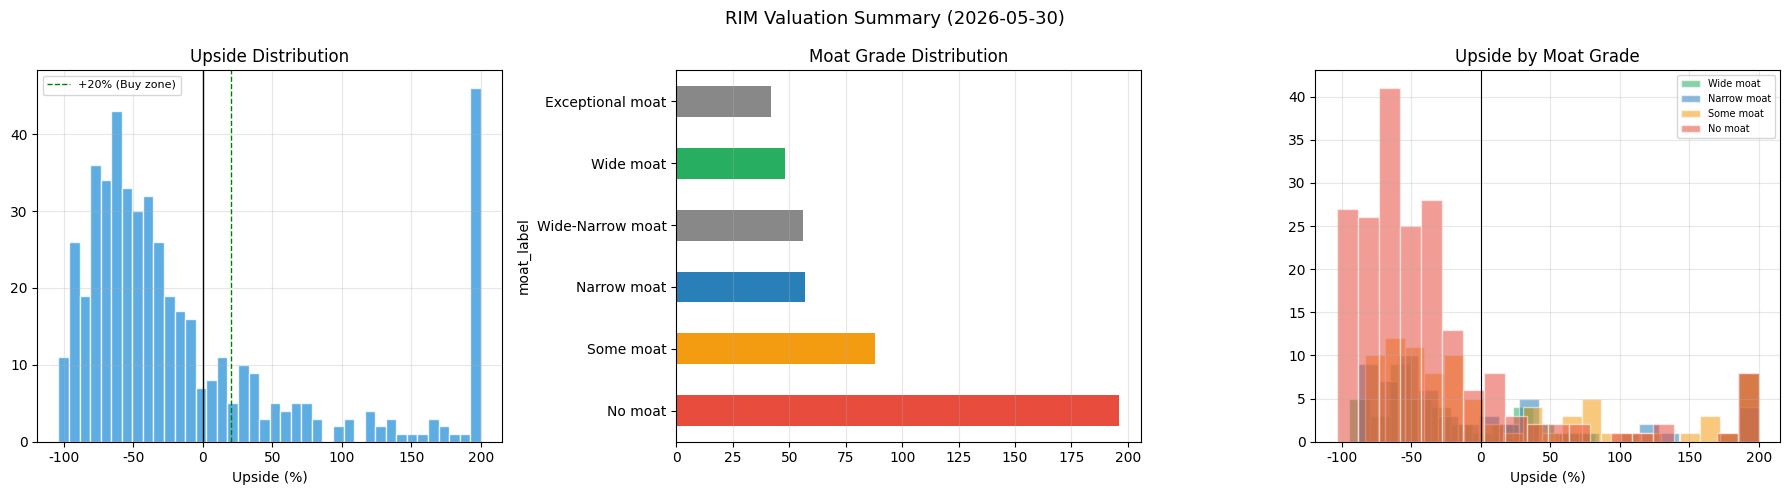


[Individual Plot] ['AAPL', 'MSFT', 'NVDA']


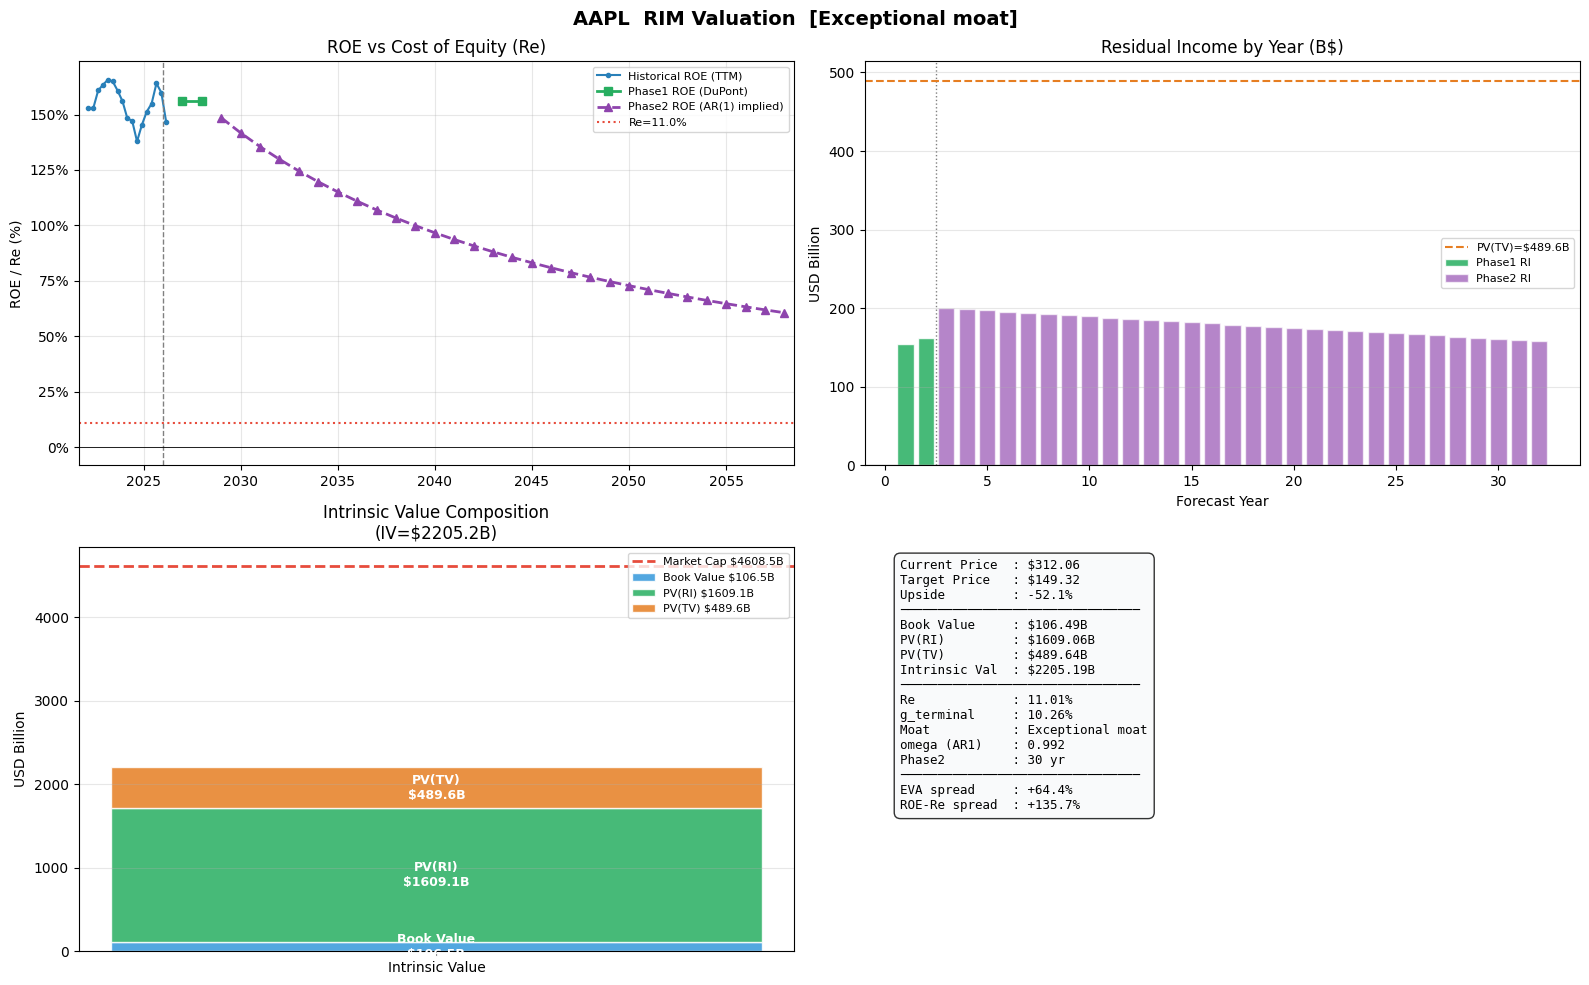

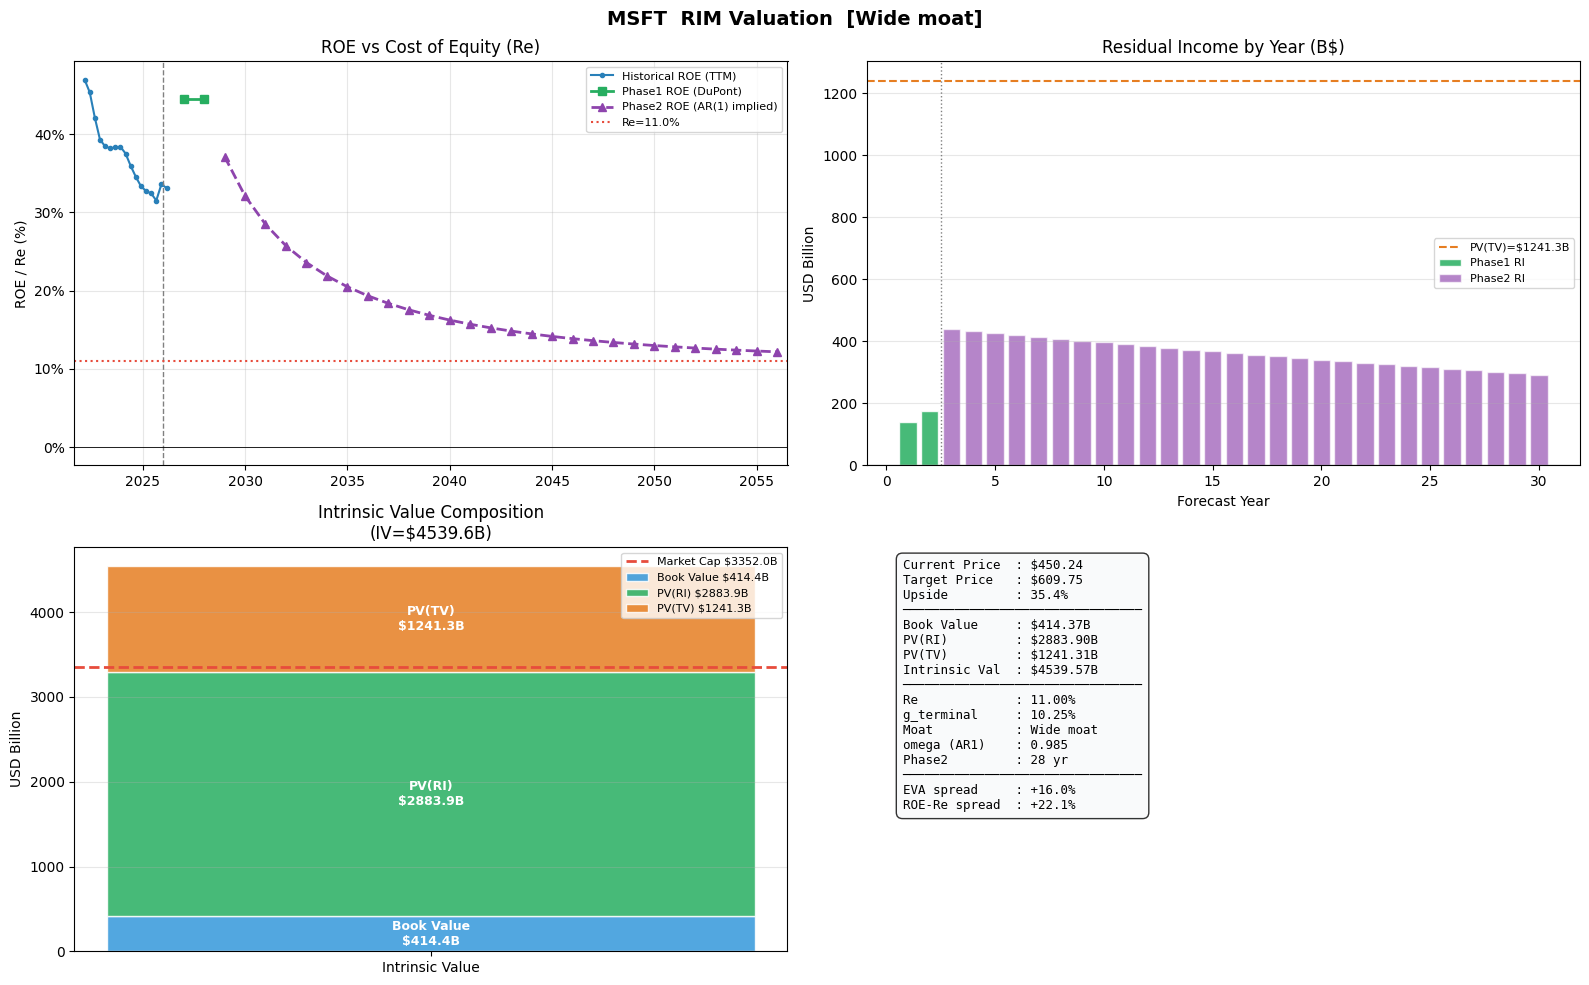

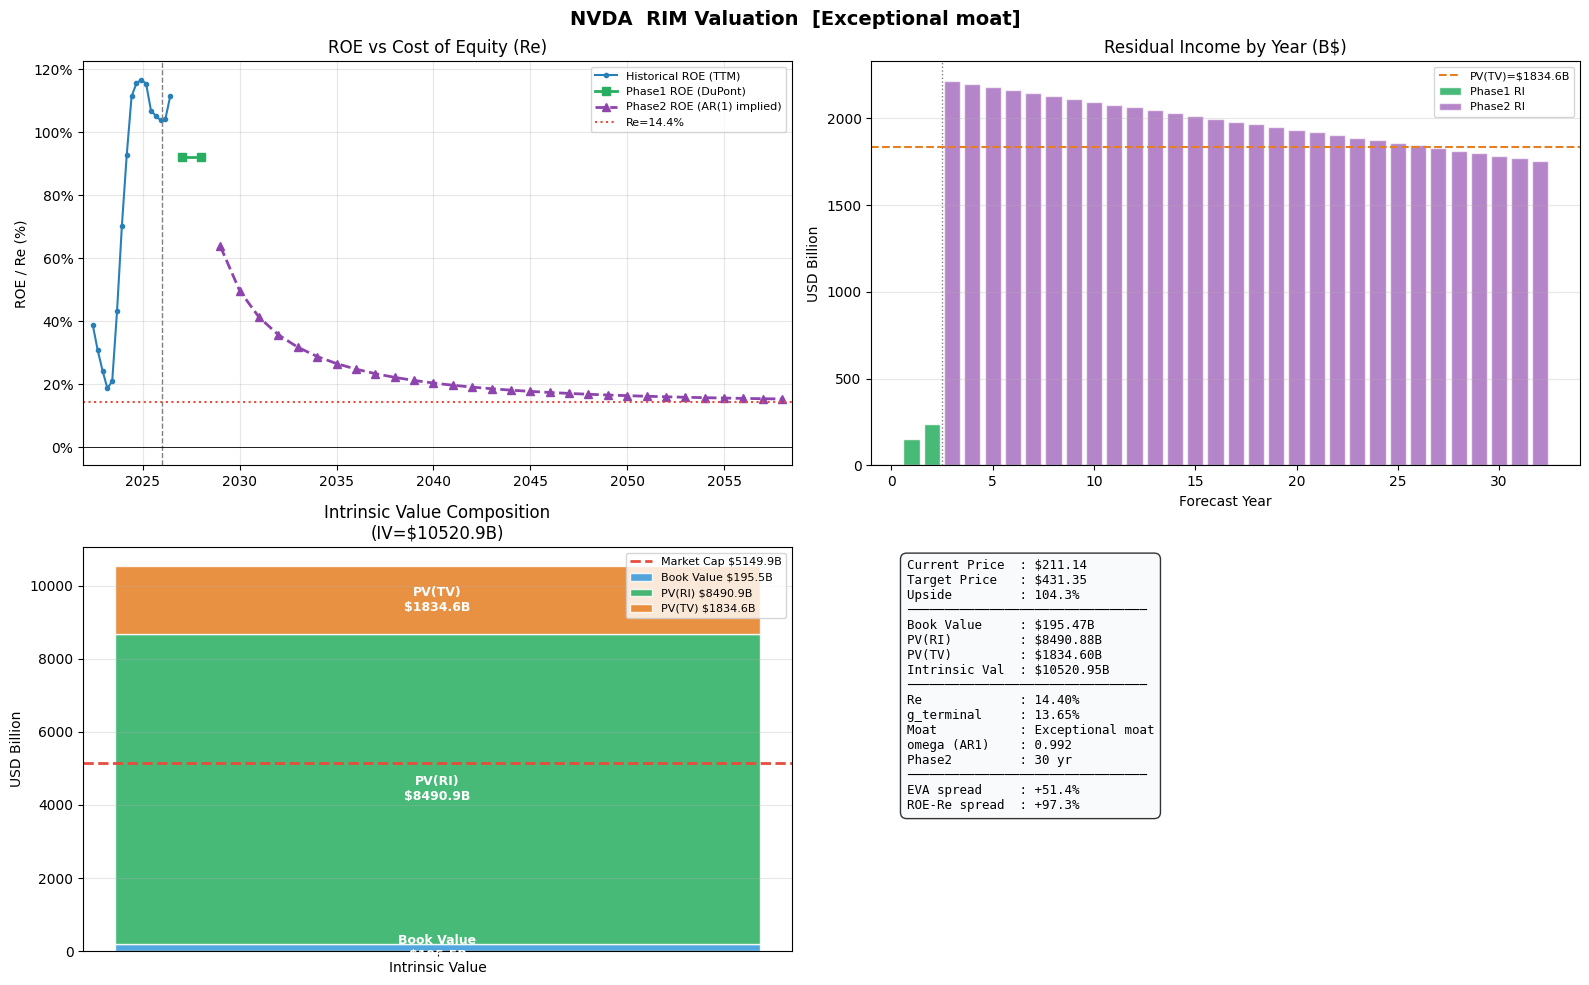

In [7]:
# ── DB summary ────────────────────────────────────────────────────────────────
conn = get_conn()
try:
    with conn.cursor() as cur:
        cur.execute(f"""
            SELECT DATE(date) AS run_date,
                   COUNT(DISTINCT ticker) AS tickers,
                   COUNT(*) AS total_rows,
                   AVG(target_price) AS avg_tp,
                   AVG(upside_pct) AS avg_upside
            FROM {TABLE_RESULT}
            GROUP BY DATE(date)
            ORDER BY run_date DESC
            LIMIT 10
        """)
        _summary = pd.DataFrame(cur.fetchall())
finally:
    conn.close()

print("=" * 60)
print(f"[DB Summary] {TABLE_RESULT}")
print("=" * 60)
display(_summary)

# ── Latest run upside distribution ────────────────────────────────────────────
conn = get_conn()
try:
    with conn.cursor() as cur:
        cur.execute(f"SELECT MAX(date) AS max_date FROM {TABLE_RESULT}")
        max_date = cur.fetchone()["max_date"]
        if max_date:
            cur.execute(f"""
                SELECT ticker,
                       MAX(target_price)  AS target_price,
                       MAX(current_price) AS current_price,
                       MAX(upside_pct)    AS upside_pct,
                       MAX(re)            AS re,
                       MAX(moat_label)    AS moat_label,
                       MAX(rho)           AS omega
                FROM {TABLE_RESULT}
                WHERE date=%s AND target_price IS NOT NULL
                GROUP BY ticker
                ORDER BY upside_pct DESC
            """, (max_date,))
            results_df = pd.DataFrame(cur.fetchall())
finally:
    conn.close()

if max_date and not results_df.empty:
    print(f"\n[Latest run: {max_date}]  {len(results_df)} tickers")
    print("\nTop 20 Upside")
    display(results_df.head(20)[["ticker","target_price","current_price","upside_pct","re","moat_label","omega"]])
    print("\nBottom 20 Upside")
    display(results_df.tail(20)[["ticker","target_price","current_price","upside_pct","re","moat_label","omega"]])

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"RIM Valuation Summary ({max_date})", fontsize=13)

    ax = axes[0]
    upside_clean = results_df["upside_pct"].dropna().clip(-200, 200)
    ax.hist(upside_clean, bins=40, color="#3498db", edgecolor="white", alpha=0.8)
    ax.axvline(0,  color="black", lw=1)
    ax.axvline(20, color="green", lw=1, ls="--", label="+20% (Buy zone)")
    ax.set_title("Upside Distribution"); ax.set_xlabel("Upside (%)"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

    ax = axes[1]
    moat_counts = results_df["moat_label"].value_counts()
    moat_colors = {"Wide moat":"#27ae60","Narrow moat":"#2980b9",
                   "Some moat":"#f39c12","No moat":"#e74c3c","Unknown (fallback)":"#95a5a6"}
    colors_bar2 = [moat_colors.get(m, "#888") for m in moat_counts.index]
    moat_counts.plot(kind="barh", ax=ax, color=colors_bar2)
    ax.set_title("Moat Grade Distribution"); ax.grid(axis="x", alpha=0.3)

    ax = axes[2]
    for label, color in moat_colors.items():
        sub = results_df[results_df["moat_label"]==label]["upside_pct"].dropna().clip(-200,200)
        if not sub.empty:
            ax.hist(sub, bins=20, alpha=0.55, color=color, label=label, edgecolor="white")
    ax.axvline(0, color="black", lw=0.8)
    ax.set_title("Upside by Moat Grade"); ax.set_xlabel("Upside (%)"); ax.legend(fontsize=7); ax.grid(alpha=0.3)

    plt.tight_layout(); plt.show()

# ── Individual plots ──────────────────────────────────────────────────────────
VIZ_TICKERS = ["AAPL", "MSFT", "NVDA"]   # <- change

print(f"\n[Individual Plot] {VIZ_TICKERS}")
for tk in VIZ_TICKERS:
    try:
        m = RIMModel(ticker=tk, engine=engine, verbose=False).run()
        m.plot()
    except Exception as e:
        print(f"  [{tk}] failed: {e}")
